# Explorative Datenanalyse · SWW Corporate Identity

Eigenständige Designfassung von Patricks [eda.ipynb](eda.ipynb). Die sechs Analyseabschnitte,
Berechnungen und Befundtexte bleiben als inhaltliche Grundlage erhalten. Die Diagramme
verwenden ausschließlich die zentrale SWW-Farbpalette, IBM Plex Sans und die Bausteine aus
`energy_analytics.visualization` — ohne Import von `viz.py`.

**Datenbasis:** `data/raw/verbrauch_bereinigt.csv`, 700 Zähler über 2024–2025.
Es werden die vorhandenen Projektdaten analysiert, keine Demo- oder Zufallsdaten erzeugt.

| Abschnitt | Inhalt |
| --- | --- |
| 1. Überblick | Spalten, Rollen, Füllgrad und Plausibilität |
| 2. Univariate Analyse | Verteilung jeder Variable |
| 3. Zähler | Unterschiede zwischen und innerhalb der Zähler |
| 4. Kundentyp | Niveau, Normierung und Saison |
| 5. Bivariate Analyse | Zusammenhänge und mögliche Treiber |
| 6. Fehlwerte | Zeitliche Muster und Modellierungsfolgen |
| Fazit | Aus dem Original übernommene Modellierungsempfehlungen |


## Ausführung und Gestaltungsregeln

1. Im Projektstamm einmal `python -m uv sync --frozen --all-extras` ausführen.
2. Den Kernel **Python (SWW .venv)** oder die Projektumgebung `.venv` auswählen und **Alle ausführen** starten.
3. Die gespeicherten Ausgaben zeigen den zuletzt geprüften Stand. Bei Änderungen an den
   Design-Tokens erst `python scripts/build_tokens.py` ausführen, dann den Kernel neu starten.

Gewerbe bleibt Teal, Industrie Navy und Kommunal Grün. Messwerte ohne Kundengruppierung
verwenden Navy; Cyan bleibt Prognosen vorbehalten. Schwellen sind Amber und gepunktet.
Zahlen verwenden Dezimalkomma und Tausenderpunkt, jedes Diagramm nennt den Bezugszeitraum.
Die [Brand-Galerie](../brand/design-system/templates/eda-charts/index.html) ist die Referenz.
Die interaktiven Diagramme nutzen den Plotly-Renderer von JupyterLab oder VS Code.
Schriften werden lokal eingebettet; die Analyse lädt keine Ressourcen von einem CDN.
Die geprüfte Fassung enthält zusätzlich PNG-Vorschauen für Betrachter ohne Plotly-Unterstützung.
Nach erneuter Ausführung können diese mit den Prüfschritten in [README.md](README.md)
aktualisiert werden. Eine eigenständige Offline-HTML-Vorschau entsteht dabei ebenfalls.

**Inhaltliche Abgrenzung:** Dies ist eine Designübertragung, keine neue fachliche Freigabe.
Sentinel-Rekonstruktion, Filterung und Befunde stammen aus Patricks Notebook. Insbesondere die
Interpretation der Vertragsleistung als harte physikalische Obergrenze muss fachlich geprüft
werden. Die Rekonstruktion aus einer Folgezeile ist rückblickende EDA und darf nicht ungeprüft
in eine Prognose-Pipeline übernommen werden. Keine Quelldatei wird überschrieben.


In [2]:
from pathlib import Path
from datetime import datetime, timezone
from importlib.util import find_spec
import sys

# Prüfen, bevor der erste Drittanbieter-Import einen unklaren Fehler auslöst.
benoetigte_pakete = ("numpy", "pandas", "plotly", "IPython", "energy_analytics", "scipy", "jinja2")
fehlende_pakete = [name for name in benoetigte_pakete if find_spec(name) is None]
if fehlende_pakete:
    raise RuntimeError(
        f"Im aktuellen Notebook-Kernel fehlen: {', '.join(fehlende_pakete)}. "
        f"Aktiver Interpreter: {sys.executable}. "
        "Bitte oben rechts den Kernel 'Python (SWW .venv)' oder die Projekt-.venv "
        "auswählen, den Kernel neu starten und alle Zellen ausführen. "
        "Falls die Projektumgebung noch fehlt: im Projektstamm "
        "`python -m uv sync --frozen --all-extras` ausführen."
    )

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

try:
    from energy_analytics.visualization import eda, theme
    from energy_analytics.visualization import notebook as ci
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "Bitte im Projektstamm `python -m uv sync --frozen --all-extras` ausführen "
        "und anschließend die Projektumgebung .venv als Notebook-Kernel auswählen."
    ) from exc

BASE_DIR = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "pyproject.toml").is_file() and (folder / "brand/design-system").is_dir()),
    None,
)
if BASE_DIR is None:
    raise FileNotFoundError("Bitte das Notebook innerhalb des Projektordners starten.")

ci.aktiviere()
# Ausschließlich die vorhandene Datei lesen; keine Bereinigung auf Datenträger schreiben.
DATA_DIR = BASE_DIR / "data" / "raw"
RANDOM_STATE = 42

df = pd.read_csv(DATA_DIR / "verbrauch_bereinigt.csv", parse_dates=["monat"])
df["monat"] = df["monat"].dt.to_period("M")
df = df.rename(columns={"heiztage": "heizgradtage"})   # Name aus dem Cleaning-Befund
df["wartung_aktiv"] = df["wartung_aktiv"].astype(bool)

TYPEN = ["Gewerbe", "Industrie", "Kommunal"]
assert set(df["kundentyp"]) == set(TYPEN), "unerwartete Auspraegung in kundentyp"
df["kundentyp"] = pd.Categorical(df["kundentyp"], categories=TYPEN)

# --- Sentinels rekonstruieren ----------------------------
# Die 3 Platzhalter (0 / -50 / -1000) stehen im Export als NaN. Der echte Messwert
# steckt in vormonat_verbrauch_kwh der FOLGEZEILE desselben Zaehlers (Nachweis in
# cleaning.ipynb). Gehoert langfristig in das Cleaning selbst.
df = df.sort_values(["zaehler_id", "monat"]).reset_index(drop=True)
je_zaehler = df.groupby("zaehler_id")
sentinel = df["verbrauch_kwh"].isna()
df["vormonat_der_folgezeile"] = je_zaehler["vormonat_verbrauch_kwh"].shift(-1)
sentinel_tabelle = df.loc[sentinel, ["zaehler_id", "monat", "vormonat_verbrauch_kwh",
                                     "vormonat_der_folgezeile"]].copy()
df.loc[sentinel, "verbrauch_kwh"] = df.loc[sentinel, "vormonat_der_folgezeile"]
df = df.drop(columns="vormonat_der_folgezeile")
assert df["verbrauch_kwh"].notna().all(), "Zielwert nicht rekonstruierbar"

# --- Abgeleitete Pruefgroessen (NUR EDA, enthalten den Zielwert -> kein Feature) ---
df["jahr"] = df["monat"].dt.year
df["stunden_im_monat"] = df["monat"].dt.days_in_month * 24
df["auslastung_prozent"] = (df["verbrauch_kwh"]
                            / (df["vertragsleistung_kw"] * df["stunden_im_monat"]) * 100)
df["abweichung_vormonat_prozent"] = (df["verbrauch_kwh"] / df["vormonat_verbrauch_kwh"] - 1) * 100

# Bezugszeitraum - das Design-System verlangt ihn in jeder Abbildung (steht im Titel)
ci.ZEITRAUM = f"{df['monat'].min().strftime('%m/%Y')}–{df['monat'].max().strftime('%m/%Y')}"

# --- Farbe folgt dem Kundentyp - in JEDER Abbildung dieselbe ---
FARBE_TYP = ci.KUNDENTYP
TYP_STIL = dict(color_discrete_map=FARBE_TYP, category_orders={"kundentyp": TYPEN})
NEUTRAL = ci.HELL["gedaempft"]
HIST_GAP = ci.HIST_GAP   # Histogramme: Klassenabstand laut Design-System, der Template-Abstand gilt fuer Balken


def log_ticks(fig, achse="x", werte=(1e3, 3e3, 1e4, 3e4, 1e5, 3e5), **kw):
    """Plotly binnt nicht auf Log-Achsen - gebinnt wird auf log10, beschriftet in Originaleinheit."""
    text = [f"{w:,.0f}".replace(",", ".") for w in werte]
    getattr(fig, f"update_{achse}axes")(tickmode="array", tickvals=np.log10(werte),
                                          ticktext=text, **kw)
    return fig


def iqr_whisker(fig):
    """Whisker bei 1,5 IQR statt Min/Max - Ausreisser werden berechnet, aber nicht gezeichnet."""
    fig.update_traces(boxpoints="outliers", marker=dict(opacity=0, size=1),
                      hoveron="boxes", selector=dict(type="box"))
    return fig


def de(zahl, stellen=1):
    """Zahl im deutschen Format fuer Untertitel."""
    return f"{zahl:,.{stellen}f}".replace(",", "X").replace(".", ",").replace("X", ".")


print(f"Zeilen:  {len(df):,} | Sentinels rekonstruiert: {sentinel.sum()}".replace(",", "."))
print(f"Zaehler: {df['zaehler_id'].nunique()} | Monate: {df['monat'].nunique()} "
      f"({df['monat'].min()} bis {df['monat'].max()})")

ci.titelkarte(
    "Explorative Datenanalyse",
    "SWW-Designfassung von Patricks Analyse · Datenbasis: data/raw/verbrauch_bereinigt.csv",
    f"{len(df):,} Monatswerte · {df['zaehler_id'].nunique()} Zähler · {ci.ZEITRAUM} · "
    f"Ausgeführt: {datetime.now(timezone.utc):%d.%m.%Y %H:%M} UTC".replace(",", "."),
    logo=BASE_DIR / "brand/design-system/assets/logo-sww-wordmark.png",
)


RuntimeError: Im aktuellen Notebook-Kernel fehlen: plotly, energy_analytics, scipy, jinja2. Aktiver Interpreter: c:\Users\Kiko\AppData\Local\Programs\Python\Python312\python.exe. Bitte oben rechts den Kernel 'Python (SWW .venv)' oder die Projekt-.venv auswählen, den Kernel neu starten und alle Zellen ausführen. Falls die Projektumgebung noch fehlt: im Projektstamm `python -m uv sync --frozen --all-extras` ausführen.

## 1. Überblick: Welche Spalten gibt es — und in welcher Rolle?

Die bereinigte Datei enthält die 16 Rohspalten. Für die Prüfung kommen im Setup vier
**abgeleitete** Größen dazu. Die Rollen bestimmen, was später ins Modell darf: Die
Zielgröße und alles, was aus ihr im selben Monat berechnet wird, ist **kein** Feature
(Data Leakage).

In [2]:
ROLLE = {
    "zaehler_id": "Schlüssel", "kunde_id": "Schlüssel", "monat": "Zeit",
    "jahr": "EDA-abgeleitet", "monat_idx": "Zeit",
    "kundentyp": "Stammdaten", "vertragsleistung_kw": "Stammdaten",
    "arbeitstage": "Kalender", "feiertage_im_monat": "Kalender",
    "stunden_im_monat": "EDA-abgeleitet",
    "mittlere_temperatur_c": "Wetter", "heizgradtage": "Wetter",
    "produktionsplan_index": "Betrieb", "wartung_aktiv": "Betrieb",
    "vormonat_verbrauch_kwh": "Lag", "letzte_3_monate_durchschnitt_kwh": "Lag",
    "vorjahr_monat_verbrauch_kwh": "Lag",
    "verbrauch_kwh": "ZIELGRÖSSE",
    "abweichung_vormonat_prozent": "EDA-abgeleitet (Leakage)",
    "auslastung_prozent": "EDA-abgeleitet (Leakage)",
}

steckbrief = pd.DataFrame({
    "Rolle": pd.Series(ROLLE),
    "dtype": df.dtypes.astype(str),
    "eindeutig": df.nunique(),
    "fehlend": df.isna().sum(),
    "fehlend %": (df.isna().mean() * 100).round(1),
    "Beispiel": df.iloc[1].astype(str),
}).loc[list(ROLLE)]
steckbrief

,Rolle,dtype,eindeutig,fehlend,fehlend %,Beispiel
zaehler_id,Schlüssel,object,700,0,0.0,ZL-00000
kunde_id,Schlüssel,object,700,0,0.0,KD-221958
monat,Zeit,period[M],24,0,0.0,2024-02
jahr,EDA-abgeleitet,int64,2,0,0.0,2024
monat_idx,Zeit,int64,12,0,0.0,2
kundentyp,Stammdaten,category,3,0,0.0,Gewerbe
vertragsleistung_kw,Stammdaten,int64,271,0,0.0,74
arbeitstage,Kalender,int64,4,0,0.0,21
feiertage_im_monat,Kalender,int64,3,0,0.0,0
stunden_im_monat,EDA-abgeleitet,int64,4,0,0.0,696


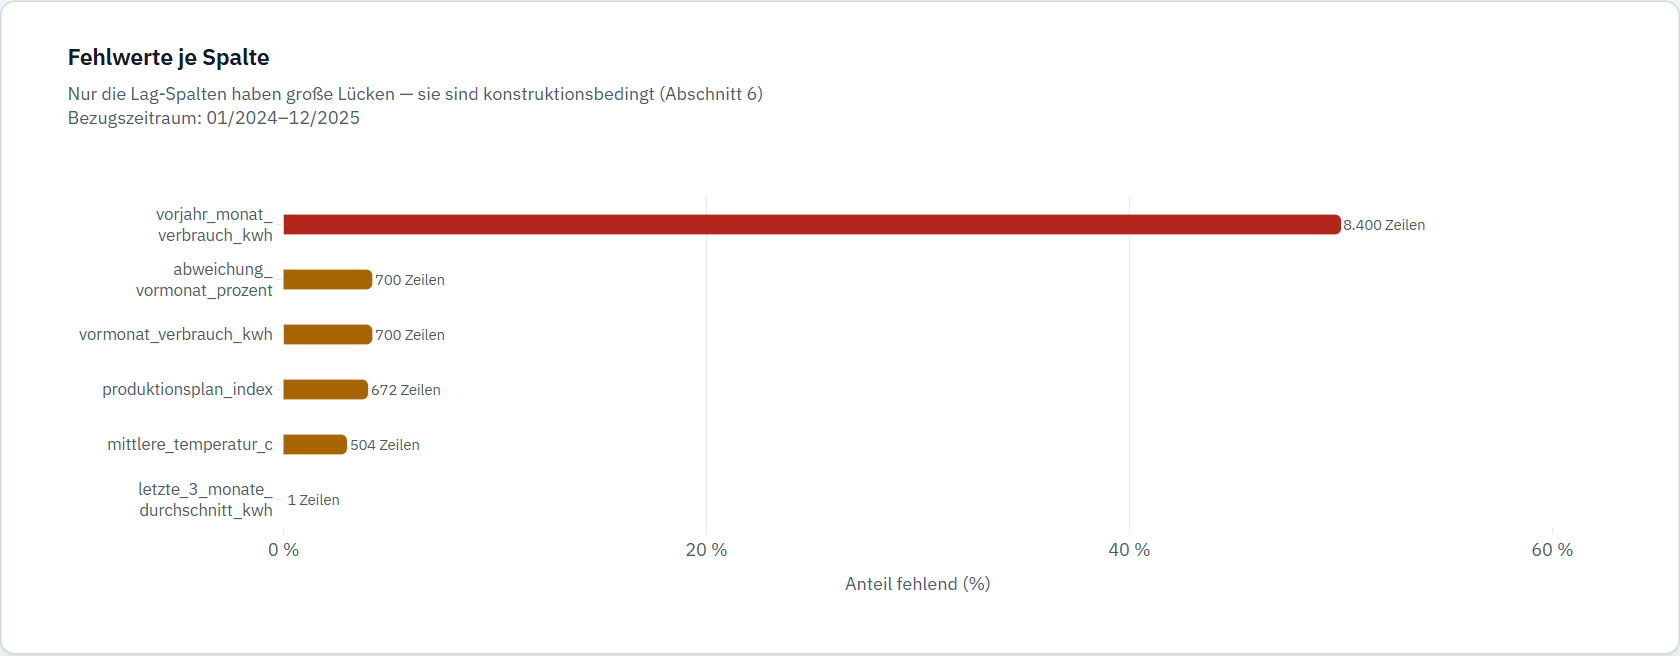

In [3]:
fehl = (steckbrief.query("fehlend > 0").sort_values("fehlend")
        .reset_index(names="spalte"))
# Lange Spaltennamen werden einmal im SWW-Baustein umgebrochen.

fig = eda.missing_values(fehl["spalte"].tolist()[::-1], fehl["fehlend %"].tolist()[::-1])
fig.update_traces(text=fehl["fehlend"].tolist())
ci.stil(fig, "Fehlwerte je Spalte",
         "Nur die Lag-Spalten haben große Lücken — sie sind konstruktionsbedingt (Abschnitt 6)",
         x_titel="Anteil fehlend (%)", y_titel="")
ci.gitter_x(fig)
ci.hover_pro_marke(fig)
ci.balken_kappen(fig, len(fehl), flaeche_px=400)
# Design-System: >= 5 % rot, >= 1 % amber, sonst grau
fig.update_traces(marker_color=ci.farben_datenqualitaet(fehl["fehlend %"]))
fig.update_traces(texttemplate="%{text:,} Zeilen", textposition="outside",
                  textfont=ci.LABEL_SCHRIFT, cliponaxis=False)
fig.update_layout(height=380)
ci.prozent_achse(fig, "x", range=[0, 60])
ci.zeigen(fig)

### 1.1 Sentinels: Rekonstruktion aus der Folgezeile

In der Datei fehlen 3 Zielwerte. Das sind die Platzhalter 0 / −50 / −1000 aus den
Rohdaten. Ihr echter Messwert steht in `vormonat_verbrauch_kwh` des **Folgemonats**
und wird im Setup eingesetzt.

In [4]:
sentinel_tabelle.rename(columns={
    "vormonat_verbrauch_kwh": "Verbrauch Vormonat",
    "vormonat_der_folgezeile": "rekonstruierter Wert",
}).round({"Verbrauch Vormonat": 0, "rekonstruierter Wert": 0})

,zaehler_id,monat,Verbrauch Vormonat,rekonstruierter Wert
5250,ZL-00218,2025-07,4138.0,3620.0
6683,ZL-00278,2024-12,30876.0,10043.0
6906,ZL-00287,2025-07,96068.0,106659.0


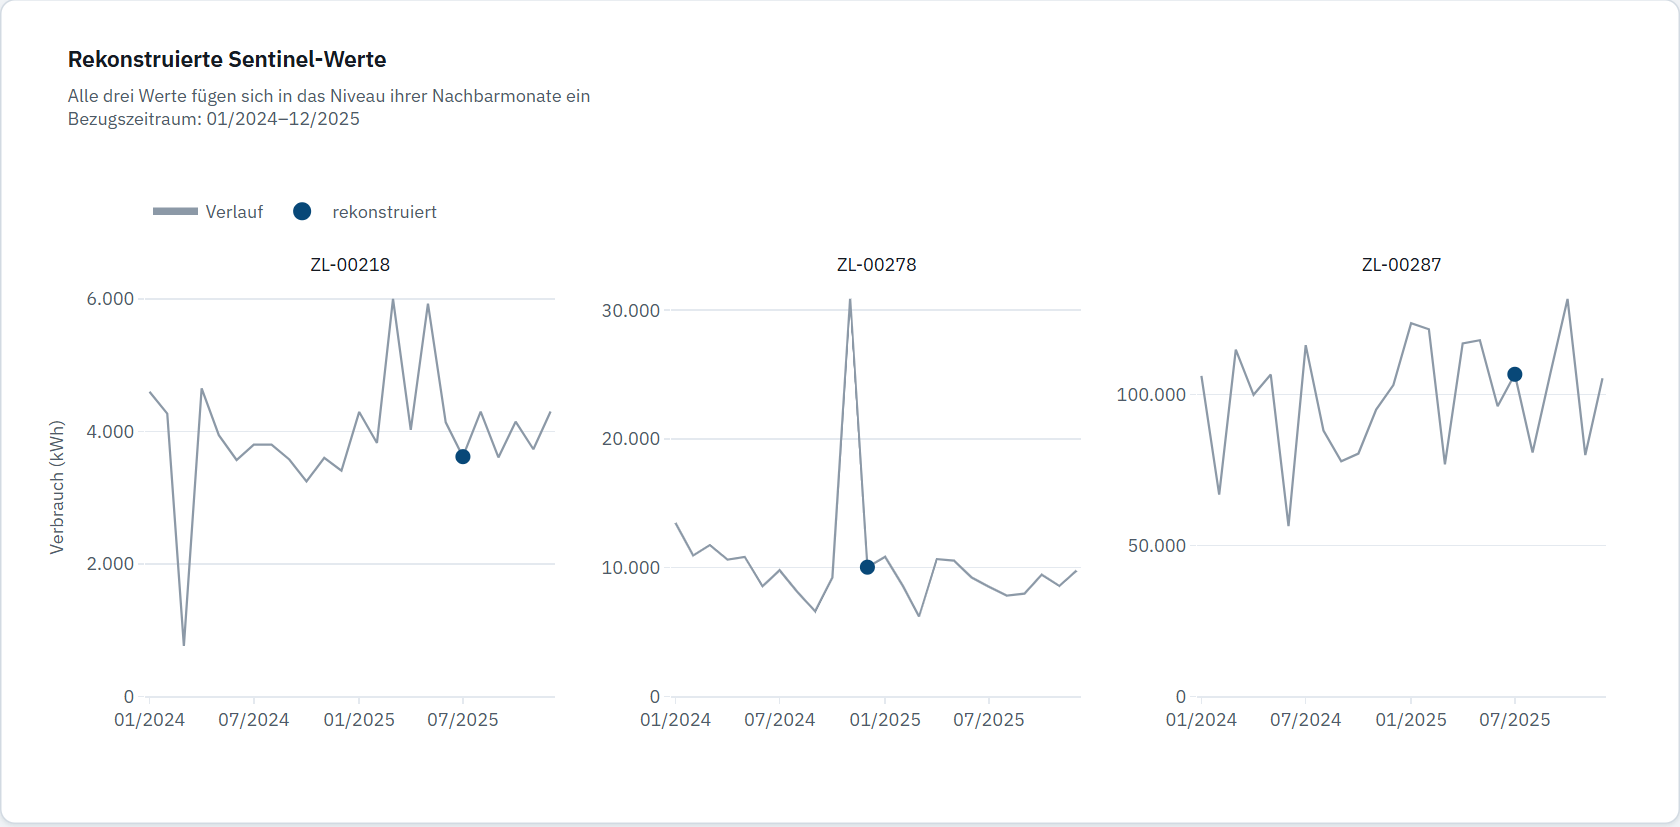

In [5]:
fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.08,
                    subplot_titles=sentinel_tabelle["zaehler_id"].tolist())
for nr, (_, zeile) in enumerate(sentinel_tabelle.iterrows(), start=1):
    serie = df[df["zaehler_id"] == zeile["zaehler_id"]]
    fig.add_scatter(x=serie["monat"].dt.to_timestamp(), y=serie["verbrauch_kwh"],
                    mode="lines", row=1, col=nr, name="Verlauf", showlegend=nr == 1,
                    line=dict(color=NEUTRAL, width=1.5), hoverinfo="skip")
    fig.add_scatter(x=[zeile["monat"].to_timestamp()], y=[zeile["vormonat_der_folgezeile"]],
                    mode="markers", row=1, col=nr, name="rekonstruiert",
                    showlegend=nr == 1, marker=dict(size=10, color=ci.SERIE[0]),
                    hovertemplate="%{x|%m/%Y}: %{y:,.0f} kWh<extra></extra>")
ci.stil(fig, "Rekonstruierte Sentinel-Werte",
         "Alle drei Werte fügen sich in das Niveau ihrer Nachbarmonate ein")
fig.update_yaxes(title_text="Verbrauch (kWh)", row=1, col=1)
fig.update_yaxes(rangemode="tozero")
fig.update_xaxes(dtick="M6", tickformat=ci.MONATSFORMAT)
fig.update_layout(hovermode="closest")
ci.zeigen(fig)

### 1.2 Plausibilität der Zielgröße: Auslastung über 100 %?

`auslastung_prozent` setzt den Monatsverbrauch ins Verhältnis zum physikalischen Maximum
(Vertragsleistung × Stunden des Monats). Werte über 100 % sind **unmöglich**.

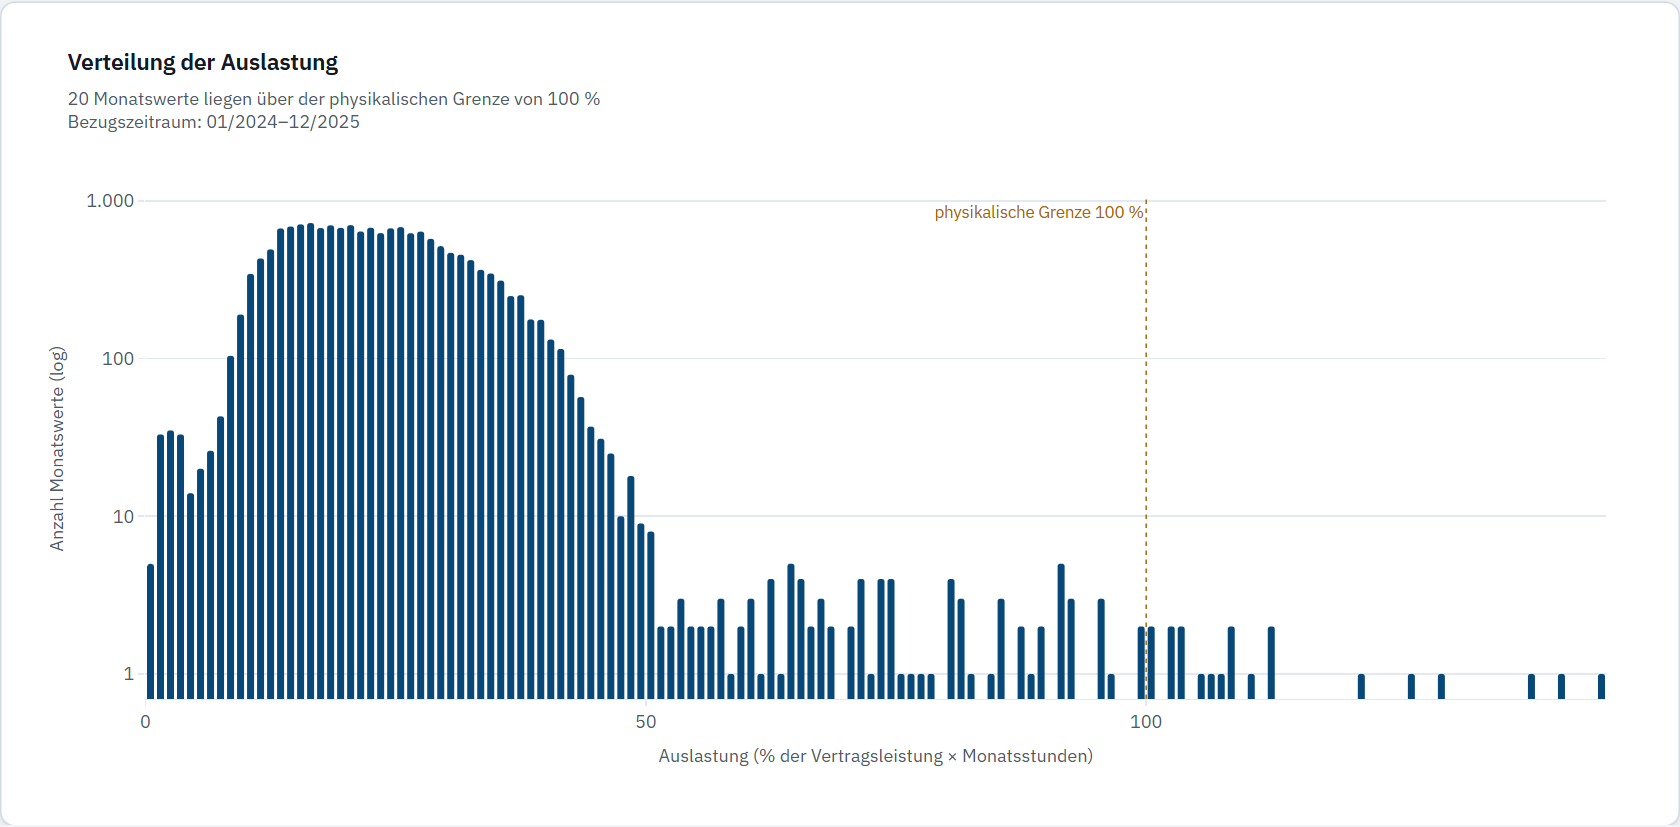

,zaehler_id,monat,kundentyp,vertragsleistung_kw,verbrauch_kwh,auslastung_prozent
7383,ZL-00307,2025-04,Gewerbe,59,61629.313469,145.078422
14845,ZL-00618,2025-02,Gewerbe,105,99823.952707,141.473856
12196,ZL-00508,2024-05,Industrie,184,190085.763368,138.854140
15385,ZL-00641,2024-02,Gewerbe,100,90101.483384,129.456154
5649,ZL-00235,2024-10,Industrie,225,211642.226455,126.429048
5939,ZL-00247,2024-12,Industrie,71,64318.581332,121.760149
2033,ZL-00084,2025-06,Kommunal,35,28447.366167,112.886374
819,ZL-00034,2024-04,Kommunal,65,52756.000000,112.726496


In [6]:
fig = eda.histogram({"Monatswerte": df["auslastung_prozent"]}, nbins=150)
ueber = df["auslastung_prozent"] > 100
ci.stil(fig, "Verteilung der Auslastung",
         f"{ueber.sum()} Monatswerte liegen über der physikalischen Grenze von 100 %",
         x_titel="Auslastung (% der Vertragsleistung × Monatsstunden)",
         y_titel="Anzahl Monatswerte")
ci.schwellwert(fig, 100, "physikalische Grenze 100 %", achse="x")
ci.log_achse(fig, dtick=1, title_text="Anzahl Monatswerte (log)")
fig.update_layout(bargap=HIST_GAP)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

df.loc[ueber, ["zaehler_id", "monat", "kundentyp", "vertragsleistung_kw",
               "verbrauch_kwh", "auslastung_prozent"]].sort_values("auslastung_prozent",
                                                                   ascending=False).head(8)

In [7]:
# Die unmoeglichen Werte fliegen fuer die EDA raus (Zielgroesse -> NaN).
# Das haette schon im Cleaning passieren sollen - dort nachziehen.
df = df[~ueber].copy()

# --- Hilfsgroessen NUR fuer die EDA ----------------------
# rel_verbrauch normiert jeden Wert auf das Mittel seines Zaehlers. Das macht die
# Treiber sichtbar, darf aber NICHT als Feature dienen: der Mittelwert enthaelt
# Information aus dem Testzeitraum (Data Leakage).
df["rel_verbrauch"] = df["verbrauch_kwh"] / df.groupby("zaehler_id")["verbrauch_kwh"].transform("mean")
df["vollaststunden"] = df["verbrauch_kwh"] / df["vertragsleistung_kw"]
df["log_verbrauch"] = np.log10(df["verbrauch_kwh"])

# Eine Zeile je Zaehler - fuer alles, was Zaehler (nicht Monatswerte) vergleicht
zaehler = (df.groupby("zaehler_id")
             .agg(kundentyp=("kundentyp", "first"),
                  vertragsleistung_kw=("vertragsleistung_kw", "first"),
                  mittel_kwh=("verbrauch_kwh", "mean"),
                  median_kwh=("verbrauch_kwh", "median"),
                  p10_kwh=("verbrauch_kwh", lambda s: s.quantile(0.10)),
                  p90_kwh=("verbrauch_kwh", lambda s: s.quantile(0.90)),
                  std_kwh=("verbrauch_kwh", "std"),
                  median_vls=("vollaststunden", "median"),
                  p10_vls=("vollaststunden", lambda s: s.quantile(0.10)),
                  p90_vls=("vollaststunden", lambda s: s.quantile(0.90)))
             .reset_index())
zaehler["kundentyp"] = pd.Categorical(zaehler["kundentyp"], categories=TYPEN)
zaehler["variationskoeffizient"] = zaehler["std_kwh"] / zaehler["mittel_kwh"]

# Stichprobe fuer dichte Streudiagramme - haelt das Notebook leicht und interaktiv
stichprobe = df.sample(4000, random_state=RANDOM_STATE)

print(f"Analysezeilen: {len(df):,} | Zaehler: {len(zaehler)}".replace(",", "."))

Analysezeilen: 16.780 | Zaehler: 700


**Befund:** Die Datei hat 16 Spalten, `kundentyp` ist sauber auf 3 Kategorien vereinheitlicht.
Zwei Punkte aus dem Cleaning sind in der exportierten Datei noch **offen**:

1. Die **3 Sentinels** stehen als NaN in der Datei. Oben sind sie aus der Folgezeile
   rekonstruiert (3.620 / 10.043 / 106.659 kWh) und passen zu ihren Nachbarmonaten.
   Der Vormonatswert der *eigenen* Zeile (4.138 / 30.876 / 96.068 kWh) wäre nur eine
   Schätzung. Bei ZL-00278 läge sie dreimal zu hoch.
2. Die **20 Monatswerte über 100 % Auslastung** sind noch enthalten. Sie liegen bis zu
   45 % über dem physikalisch Möglichen und fallen isoliert auf (2,8- bis 4,5-fach des
   Zählermittels). Das sind Messfehler, für die EDA werden sie verworfen.

**Konsequenz:** Analysiert werden 16.780 Monatswerte. Beide Korrekturen gehören zurück
in dem Datenbereinigungs-Notebook, sonst trainiert die Modellierung auf den Fehlern.
Die abgeleiteten Spalten `abweichung_vormonat_prozent` und `auslastung_prozent`
enthalten den Zielwert des Monats und sind als Features **tabu**.

## 2. Univariate Analyse

Jede Variable für sich: Lage, Streuung, Form, Ausreißer.

### 2.1 Zielgröße `verbrauch_kwh`

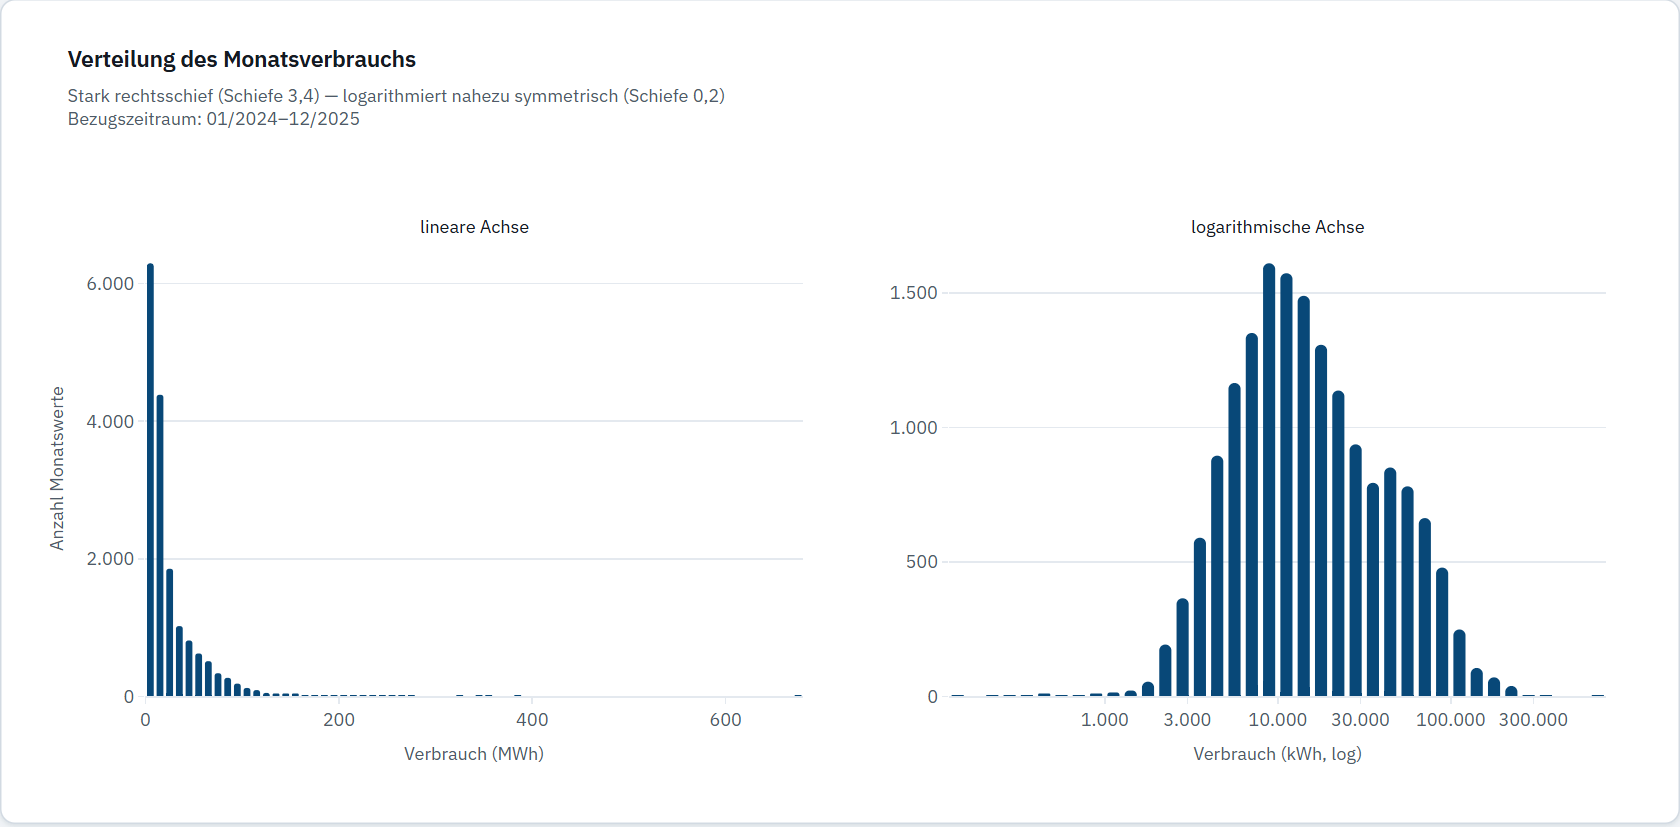

,count,mean,std,min,5%,25%,50%,75%,95%,max
verbrauch_kwh,16780.0,24914.0,29730.0,148.0,3416.0,7372.0,13618.0,30402.0,82748.0,675231.0


In [8]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.1,
                    subplot_titles=("lineare Achse", "logarithmische Achse"))
fig.add_histogram(x=df["verbrauch_kwh"] / 1000, nbinsx=120, row=1, col=1,
                  marker_color=ci.SERIE[0], name="kWh")
fig.add_histogram(x=df["log_verbrauch"], nbinsx=60, row=1, col=2,
                  marker_color=ci.SERIE[0], name="log10 kWh")

schiefe_roh, schiefe_log = df["verbrauch_kwh"].skew(), df["log_verbrauch"].skew()
ci.stil(fig, "Verteilung des Monatsverbrauchs",
         f"Stark rechtsschief (Schiefe {de(schiefe_roh)}) — logarithmiert nahezu symmetrisch "
         f"(Schiefe {de(schiefe_log)})")
fig.update_xaxes(title_text="Verbrauch (MWh)", row=1, col=1)
log_ticks(fig, "x", row=1, col=2, title_text="Verbrauch (kWh, log)")
fig.update_yaxes(title_text="Anzahl Monatswerte", row=1, col=1)
fig.update_layout(showlegend=False, bargap=HIST_GAP)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

(df["verbrauch_kwh"].describe(percentiles=[.05, .25, .5, .75, .95])
   .to_frame("verbrauch_kwh").T.round(0))

**Befund:** Der Monatsverbrauch reicht von rund 150 kWh bis 675 MWh, der Median liegt bei
13,6 MWh, der Mittelwert bei 24,9 MWh. Die lineare Verteilung ist extrem rechtsschief:
Wenige große Zähler ziehen den Mittelwert nach oben. Auf der Log-Skala ist die Verteilung
nahezu symmetrisch, mit einer Schulter bei ~50 MWh (den Industriekunden, siehe 2.2).

**Konsequenz:** Fehlermaße wie RMSE würden von den wenigen Großzählern dominiert.
Die Zielgröße wird normiert oder logarithmiert modelliert (Abschnitt 3).
Für den Vergleich eignen sich MAE und MAPE bzw. ein gewichteter Fehler.

### 2.2 Stammdaten: `kundentyp` und `vertragsleistung_kw`

Beide sind je Zähler konstant — gezählt wird deshalb **je Zähler**, nicht je Monatswert.

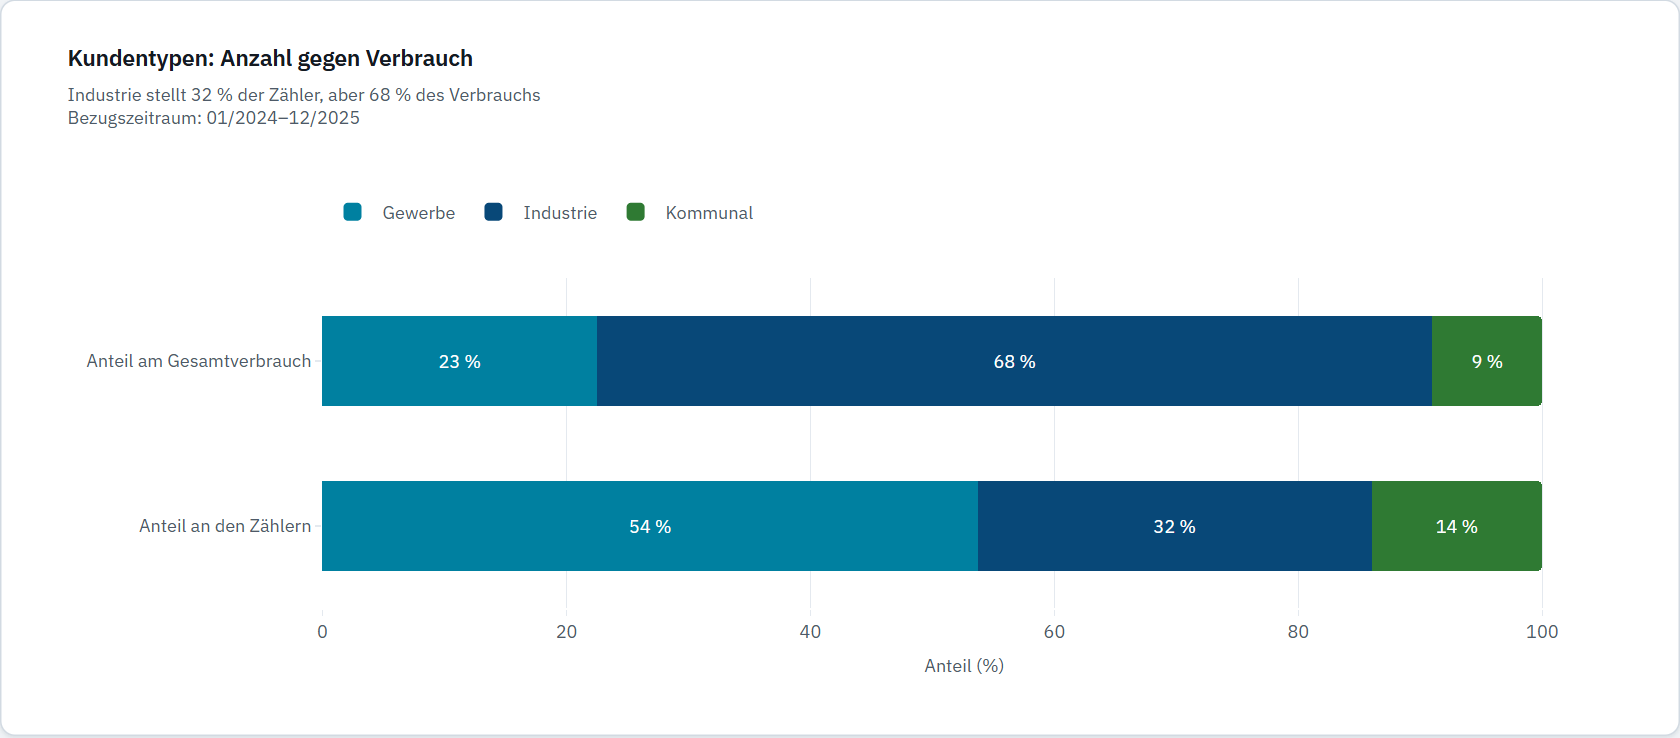

kundentyp,Gewerbe,Industrie,Kommunal
Anzahl Zähler,376,226,98


In [9]:
anteile = (zaehler.groupby("kundentyp", observed=True)
                  .agg(zaehler=("zaehler_id", "size"), verbrauch=("mittel_kwh", "sum")))
anteile = (anteile / anteile.sum() * 100).reset_index()
lang = anteile.melt(id_vars="kundentyp", var_name="groesse", value_name="anteil")
lang["groesse"] = lang["groesse"].map({"zaehler": "Anteil an den Zählern",
                                       "verbrauch": "Anteil am Gesamtverbrauch"})

fig = px.bar(lang, x="anteil", y="groesse", color="kundentyp", orientation="h",
             text="anteil", **TYP_STIL)
ind = anteile.set_index("kundentyp")
ci.stil(fig, "Kundentypen: Anzahl gegen Verbrauch",
         f"Industrie stellt {de(ind.loc['Industrie', 'zaehler'], 0)} % der Zähler, "
         f"aber {de(ind.loc['Industrie', 'verbrauch'], 0)} % des Verbrauchs",
         x_titel="Anteil (%)", y_titel="")
fig.update_traces(texttemplate="%{text:.0f} %", textposition="inside",
                  insidetextanchor="middle", textfont=dict(size=12, color=theme.TOKENS["text-inverse"]))
fig.update_layout(barmode="stack", height=300, bargap=0.45)
ci.gitter_x(fig)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

zaehler["kundentyp"].value_counts().reindex(TYPEN).rename("Anzahl Zähler").to_frame().T

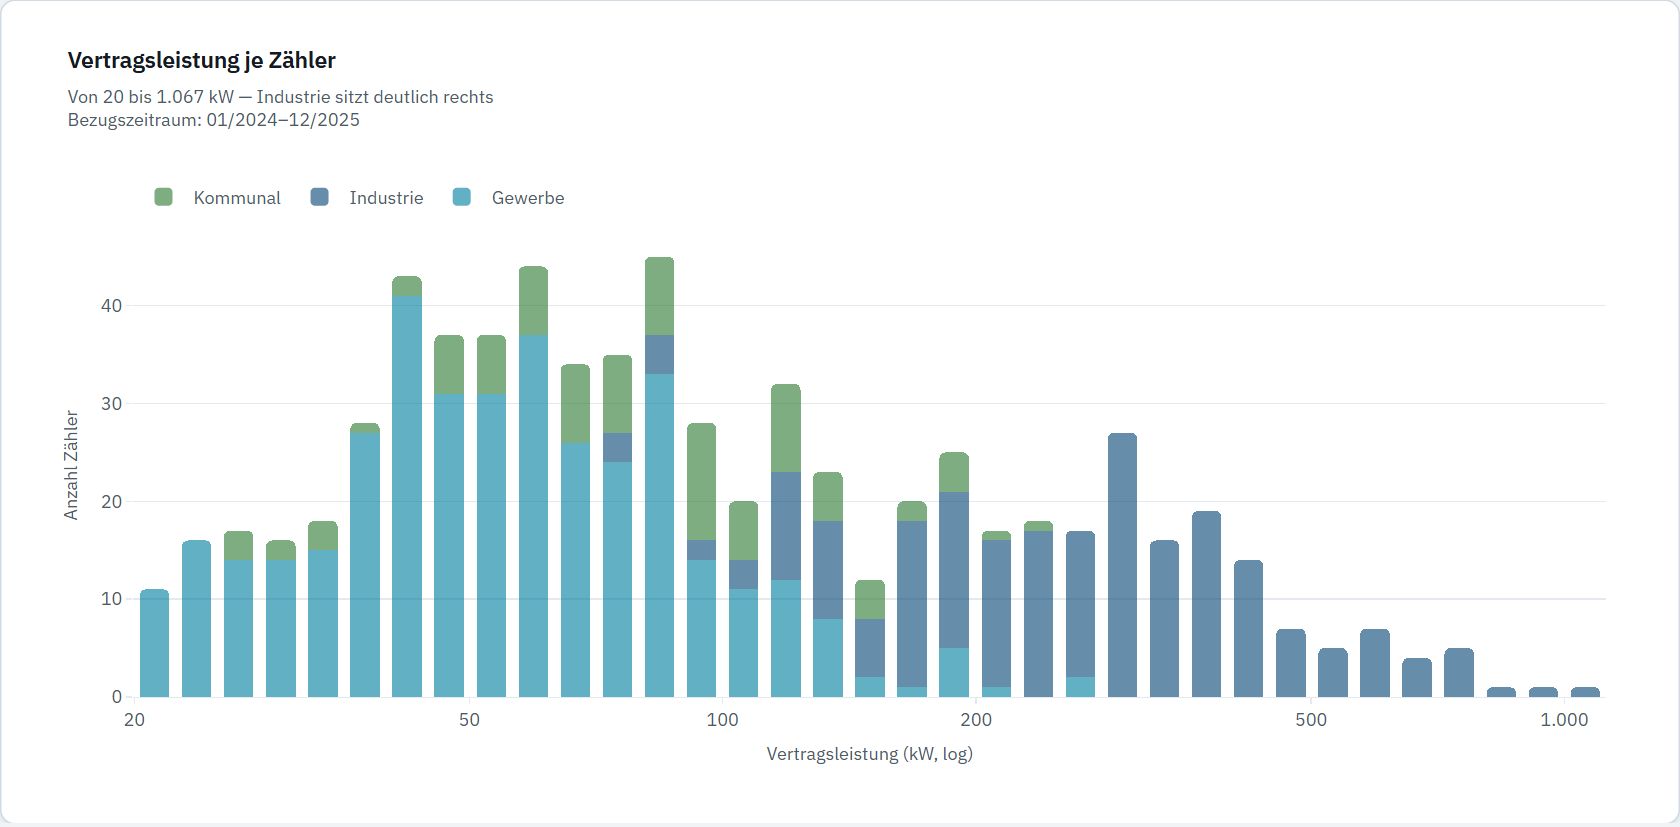

,count,mean,std,min,25%,50%,75%,max
kundentyp,,,,,,,,
Gewerbe,376.0,62.0,35.0,20.0,39.0,54.0,78.0,262.0
Industrie,226.0,299.0,168.0,71.0,178.0,272.0,376.0,1067.0
Kommunal,98.0,90.0,44.0,28.0,58.0,83.0,113.0,246.0


In [10]:
fig = eda.histogram(eda.by_kundentyp(zaehler, "vertragsleistung_kw"), nbins=40, log_x=True)
fig.update_layout(barmode="stack")
ci.stil(fig, "Vertragsleistung je Zähler",
         f"Von {zaehler['vertragsleistung_kw'].min()} bis "
         f"{de(zaehler['vertragsleistung_kw'].max(), 0)} kW — Industrie sitzt deutlich rechts",
         x_titel="Vertragsleistung (kW, log)", y_titel="Anzahl Zähler")
log_ticks(fig, "x", werte=(20, 50, 100, 200, 500, 1000))
fig.update_layout(bargap=HIST_GAP)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

zaehler.groupby("kundentyp", observed=True)["vertragsleistung_kw"].describe().round(0)

**Befund:** Mehr als die Hälfte der Zähler gehört zu **Gewerbe** (376), gefolgt von
**Industrie** (226) und **Kommunal** (98). Beim Verbrauch kehrt sich das Bild um:
Industrie verursacht gut zwei Drittel des Gesamtverbrauchs. Das liegt an der Größe.
Industriezähler haben im Median 272 kW Vertragsleistung, Gewerbe 54 kW und
Kommunal 83 kW. Die Vertragsleistung selbst ist log-normal verteilt (20 bis 1.067 kW).

**Konsequenz:** Kundentyp und Vertragsleistung beschreiben die *Größe* eines Zählers.
Beide sind je Zähler konstant und kommen als Stammdaten ins Modell.

### 2.3 Kalender: `arbeitstage`, `feiertage_im_monat`, `monat_idx`

Kalendergrößen sind für alle Zähler gleich — sie variieren nur über die 24 Monate.

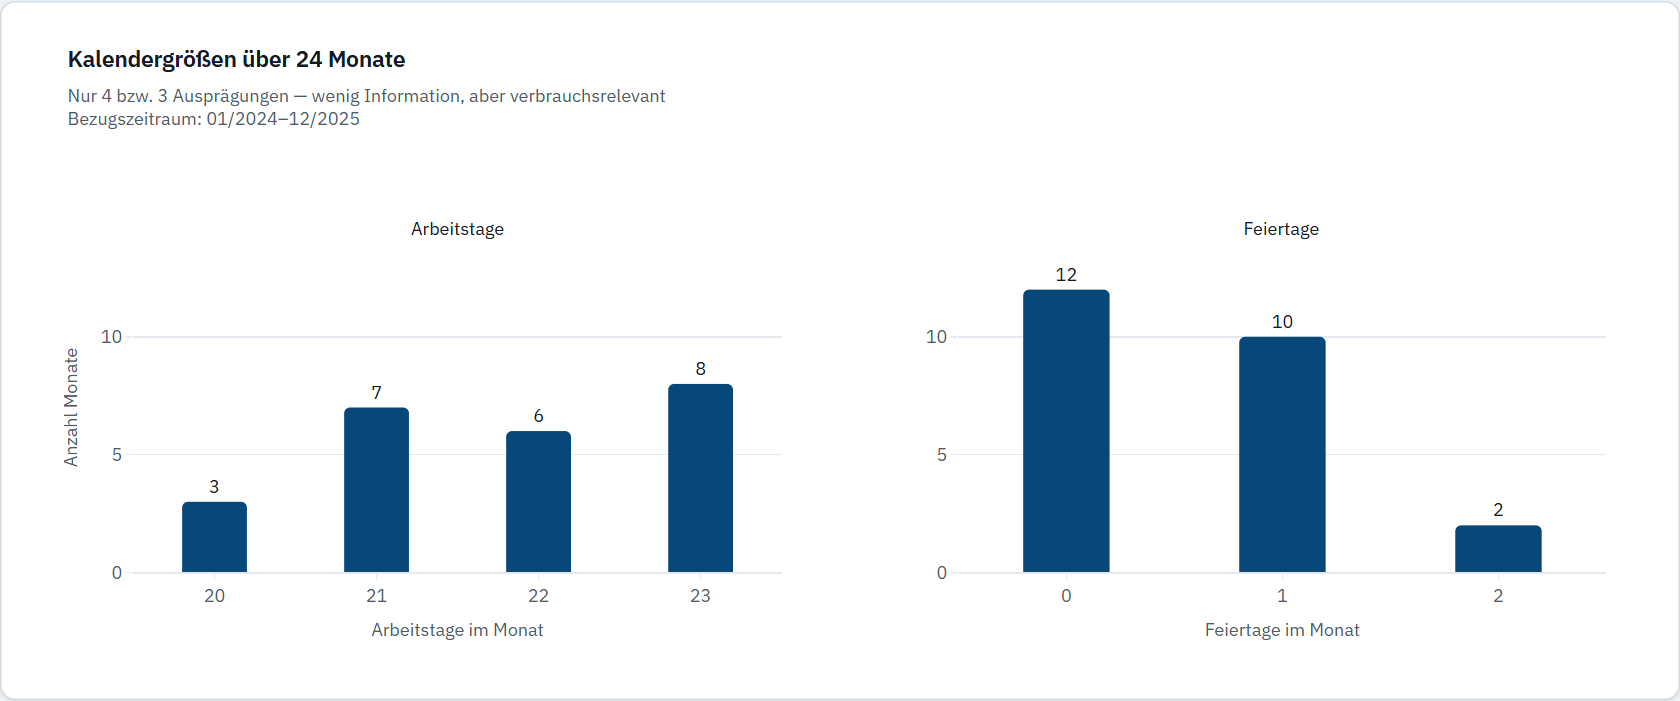

monat,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
arbeitstage,23,21,21,22,23,20,23,22,21,23,...,21,22,22,21,23,21,22,23,20,23
feiertage_im_monat,1,0,0,1,1,0,0,0,0,1,...,0,1,1,0,0,0,0,1,1,2
stunden_im_monat,744,696,744,720,744,720,744,744,720,744,...,744,720,744,720,744,744,720,744,720,744


In [11]:
kalender = df.drop_duplicates("monat").sort_values("monat")

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12,
                    subplot_titles=("Arbeitstage", "Feiertage"))
for spalte, spalte_nr in [("arbeitstage", 1), ("feiertage_im_monat", 2)]:
    zaehlung = kalender[spalte].value_counts().sort_index()
    fig.add_bar(x=zaehlung.index.astype(str), y=zaehlung.values, row=1, col=spalte_nr,
                marker_color=ci.SERIE[0], text=zaehlung.values, textposition="outside",
                width=0.4)
ci.stil(fig, "Kalendergrößen über 24 Monate",
         "Nur 4 bzw. 3 Ausprägungen — wenig Information, aber verbrauchsrelevant")
fig.update_yaxes(title_text="Anzahl Monate", row=1, col=1, range=[0, 14])
fig.update_yaxes(range=[0, 14], row=1, col=2)
fig.update_xaxes(title_text="Arbeitstage im Monat", row=1, col=1)
fig.update_xaxes(title_text="Feiertage im Monat", row=1, col=2)
fig.update_layout(showlegend=False, height=380)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

kalender.set_index("monat")[["arbeitstage", "feiertage_im_monat", "stunden_im_monat"]].T

### 2.4 Wetter: `mittlere_temperatur_c` und `heizgradtage`

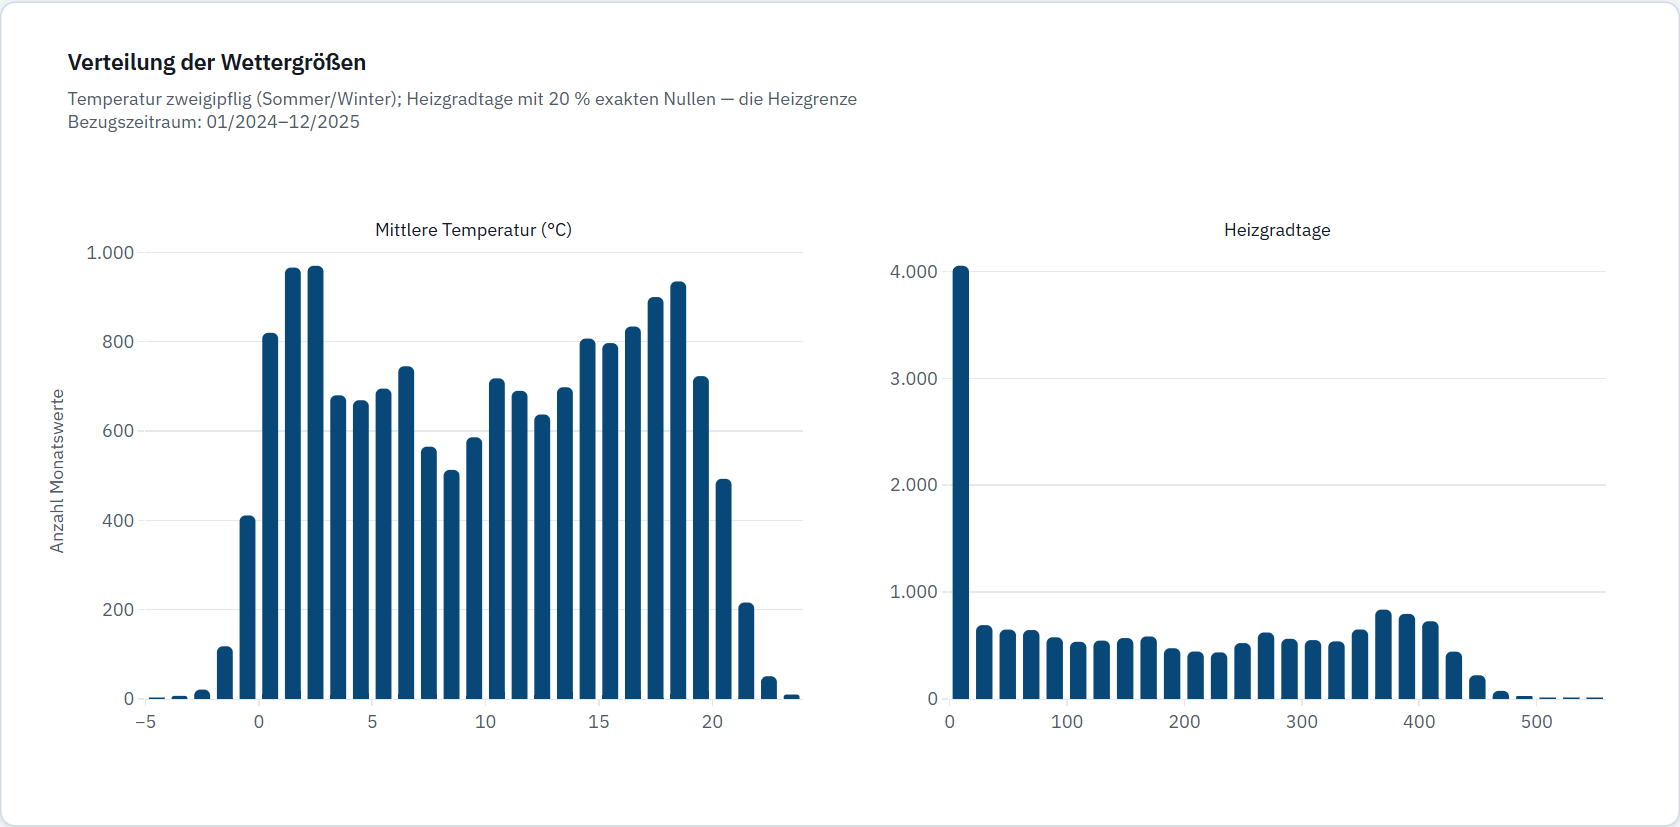

,count,mean,std,min,25%,50%,75%,max
mittlere_temperatur_c,16277.0,10.1,6.6,-4.6,4.0,10.4,16.0,23.8
heizgradtage,16780.0,180.8,151.2,0.0,22.0,162.0,322.0,540.0


In [12]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.1,
                    subplot_titles=("Mittlere Temperatur (°C)", "Heizgradtage"))
fig.add_histogram(x=df["mittlere_temperatur_c"], nbinsx=40, row=1, col=1,
                  marker_color=ci.SERIE[0])
fig.add_histogram(x=df["heizgradtage"], nbinsx=40, row=1, col=2,
                  marker_color=ci.SERIE[0])
anteil_null = (df["heizgradtage"] == 0).mean() * 100
ci.stil(fig, "Verteilung der Wettergrößen",
         f"Temperatur zweigipflig (Sommer/Winter); Heizgradtage mit {de(anteil_null, 0)} % "
         "exakten Nullen — die Heizgrenze")
fig.update_yaxes(title_text="Anzahl Monatswerte", row=1, col=1)
fig.update_layout(showlegend=False, bargap=HIST_GAP)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

df[["mittlere_temperatur_c", "heizgradtage"]].describe().T.round(1)

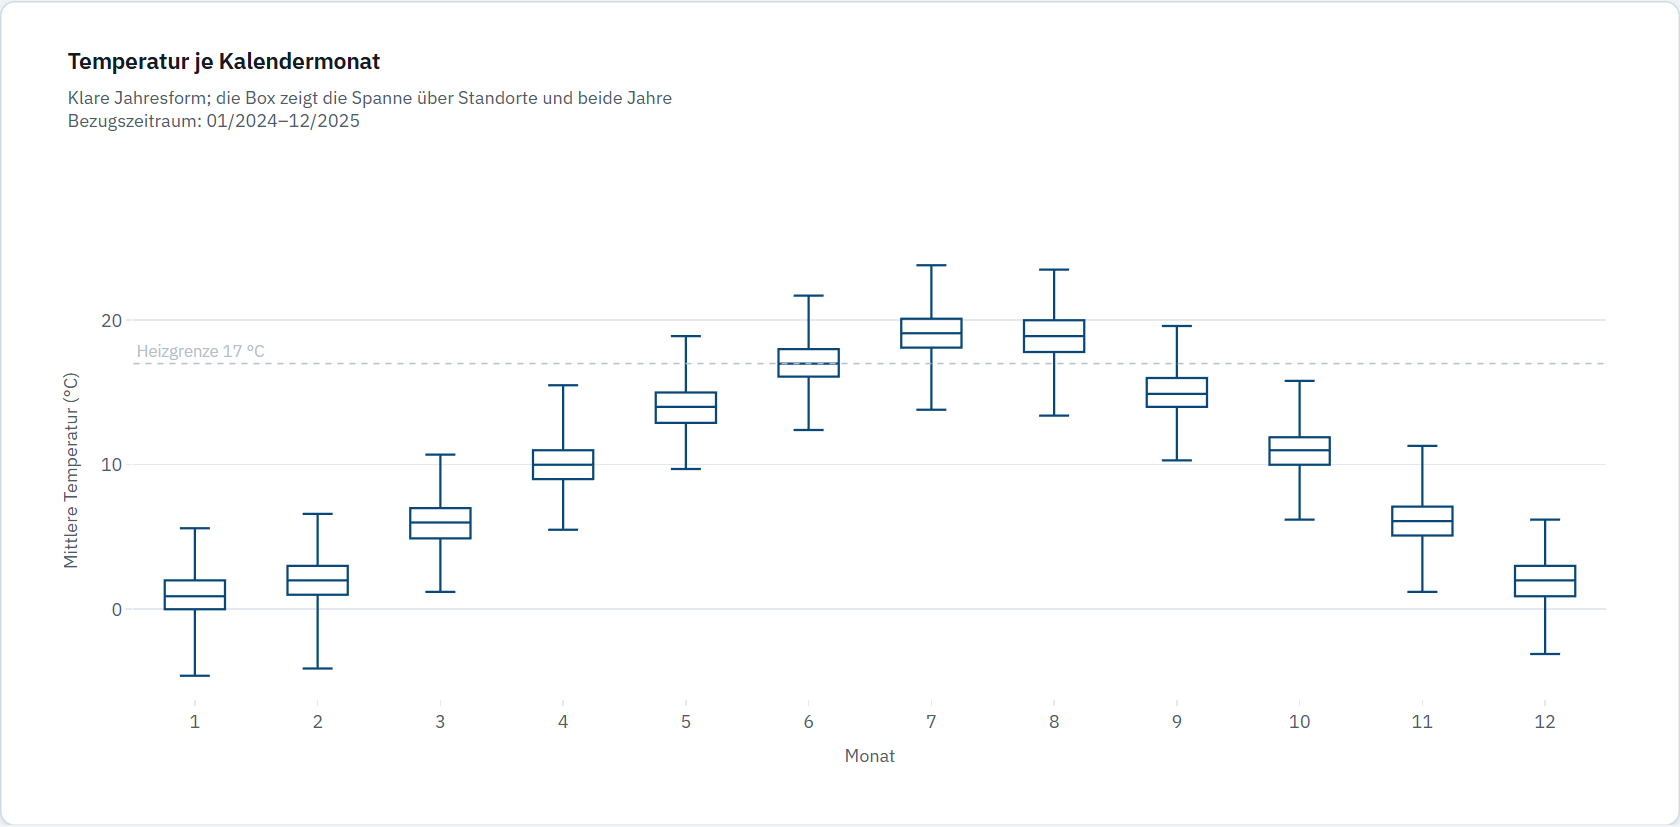

In [13]:
# Wetter je Kalendermonat: Streuung zwischen den Zaehlern (verschiedene Standorte)
fig = px.box(df, x="monat_idx", y="mittlere_temperatur_c", points=False,
             color_discrete_sequence=[ci.SERIE[0]])
ci.stil(fig, "Temperatur je Kalendermonat",
         "Klare Jahresform; die Box zeigt die Spanne über Standorte und beide Jahre",
         x_titel="Monat", y_titel="Mittlere Temperatur (°C)")
ci.referenzlinie(fig, 17, "Heizgrenze 17 °C")
fig.update_xaxes(tickmode="array", tickvals=list(range(1, 13)))
ci.hover_pro_marke(fig)
ci.zeigen(fig)

**Befund:** Die Temperatur folgt einem klaren Jahresgang (Jan ~1 °C, Jul ~19 °C) und ist
über das Jahr zweigipflig verteilt. Die Heizgradtage sind zu **20 % exakt null**. Das sind
die Monate über der Heizgrenze von 17 °C (Juni bis August). Darunter verteilen sie sich
gleichmäßig bis ~500. Innerhalb eines Kalendermonats streut die Temperatur um mehrere
Grad. Die Zähler stehen also an unterschiedlichen Standorten.

**Konsequenz:** Der Zusammenhang der beiden Größen wird in 5.2 geklärt.

### 2.5 Betrieb: `produktionsplan_index` und `wartung_aktiv`

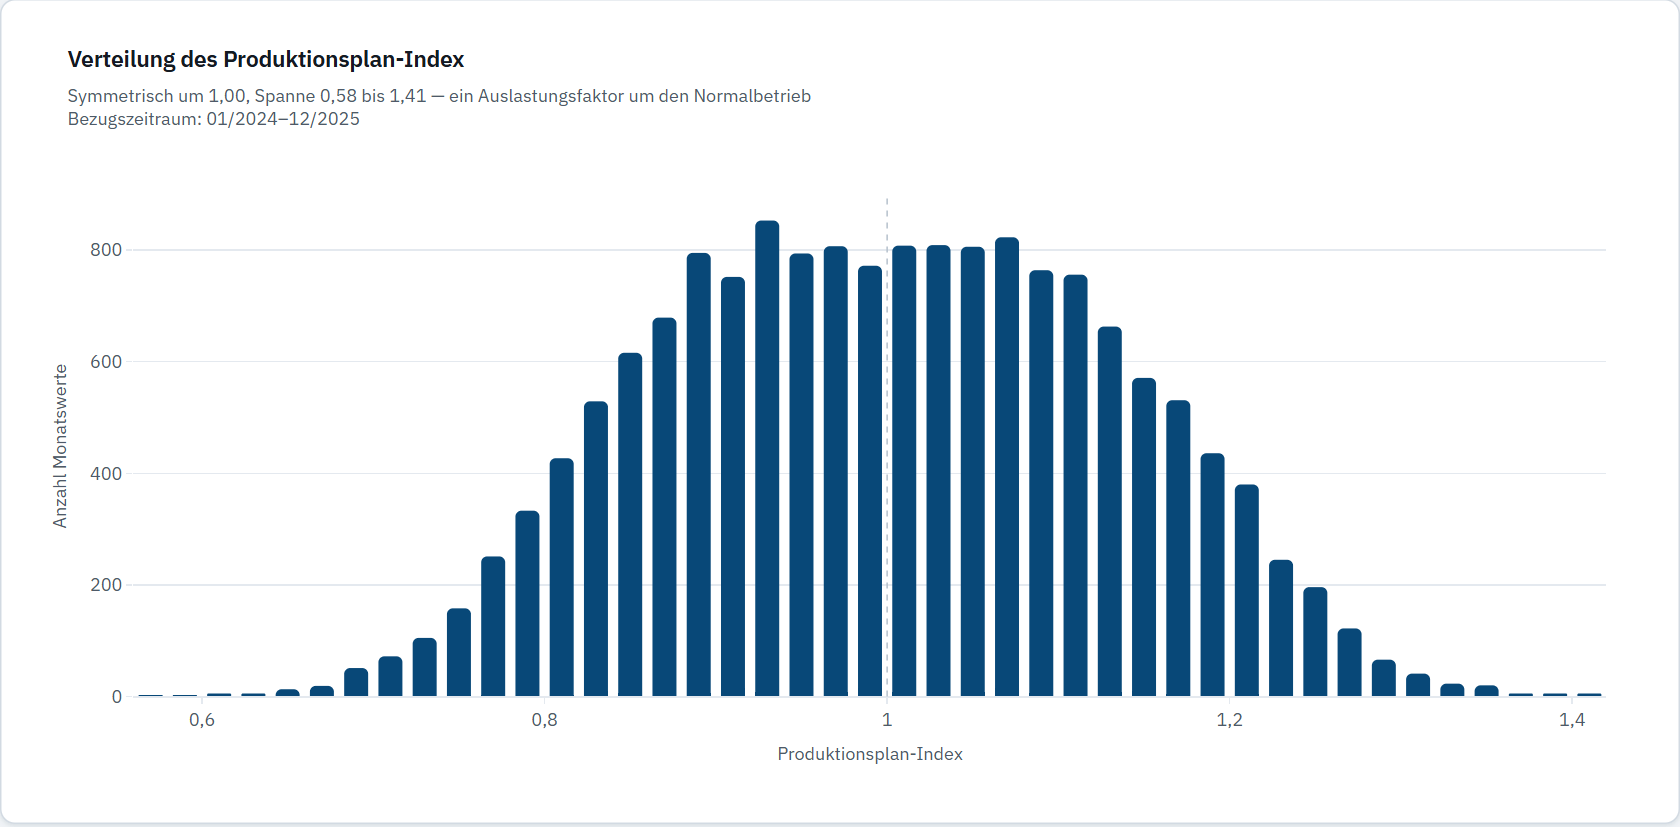

,count,mean,std,min,25%,50%,75%,max
produktionsplan_index,16108.0,1.0,0.133,0.579,0.899,1.0,1.1,1.406


In [14]:
fig = eda.histogram({"Monatswerte": df["produktionsplan_index"]}, nbins=50)
pp = df["produktionsplan_index"]
ci.stil(fig, "Verteilung des Produktionsplan-Index",
         f"Symmetrisch um {de(pp.median(), 2)}, Spanne {de(pp.min(), 2)} bis {de(pp.max(), 2)} "
         "— ein Auslastungsfaktor um den Normalbetrieb",
         x_titel="Produktionsplan-Index", y_titel="Anzahl Monatswerte")
ci.referenzlinie(fig, 1, achse="x")
fig.update_layout(bargap=HIST_GAP)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

pp.describe().to_frame().T.round(3)

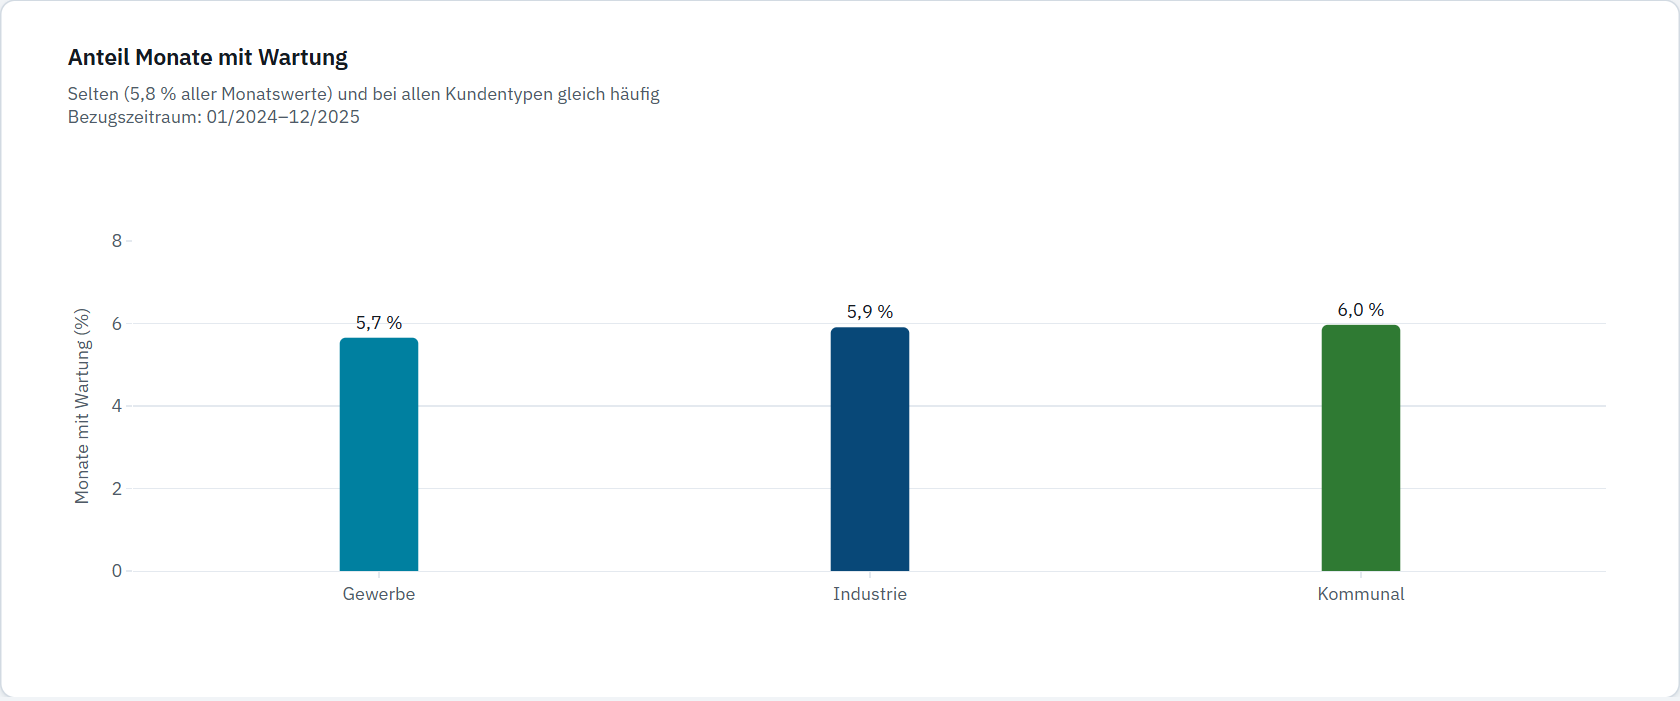

In [15]:
wartung = (df.groupby("kundentyp", observed=True)["wartung_aktiv"].mean().mul(100)
             .reindex(TYPEN).reset_index(name="anteil"))

fig = px.bar(wartung, x="kundentyp", y="anteil", color="kundentyp", text="anteil", **TYP_STIL)
ci.stil(fig, "Anteil Monate mit Wartung",
         f"Selten ({de(df['wartung_aktiv'].mean() * 100)} % aller Monatswerte) "
         "und bei allen Kundentypen gleich häufig",
         x_titel="", y_titel="Monate mit Wartung (%)")
fig.update_traces(texttemplate="%{text:.1f} %", textposition="outside")
fig.update_yaxes(range=[0, 8])
fig.update_layout(height=380, showlegend=False)
ci.balken_kappen(fig, 3, max_px=48)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

**Befund:** Der `produktionsplan_index` ist ein symmetrischer Faktor um 1,0
(Standardabweichung 0,13, Spanne 0,58 bis 1,41) mit 4 % Lücken.
`wartung_aktiv` ist ein seltenes Ereignis: 5,8 % der Monatswerte. Die Wartung ist
gleichmäßig über Kundentypen und Kalendermonate verteilt.

**Konsequenz:** Beide sind Kandidaten für Treiber, geprüft in 5.3 und 5.4.

### 2.6 Lag- und Abweichungsspalten

`vormonat_verbrauch_kwh`, `letzte_3_monate_durchschnitt_kwh` und `vorjahr_monat_verbrauch_kwh`
haben dieselbe Verteilung wie die Zielgröße (sie **sind** verschobene Zielwerte).
Interessanter ist die Monat-zu-Monat-Veränderung.

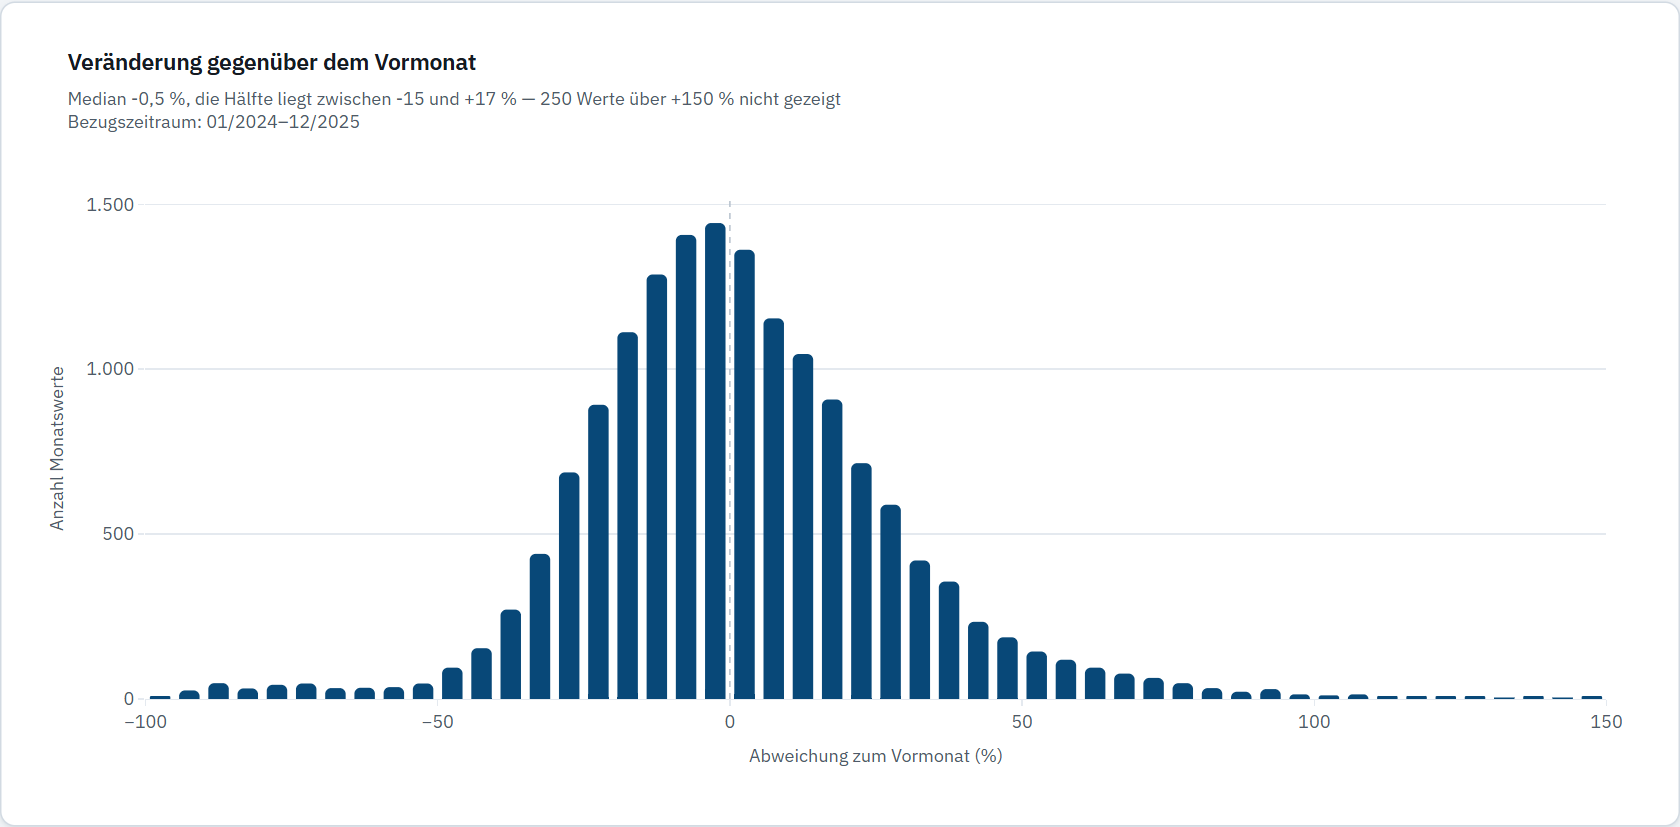

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
abweichung_vormonat_prozent,16080.0,9.5,90.2,-96.5,-74.7,-36.0,-14.9,-0.5,16.8,55.6,277.5,2779.3


In [16]:
abw = df["abweichung_vormonat_prozent"].dropna()
innen = abw.between(-100, 150)

fig = eda.histogram({"Monatswerte": abw[innen]}, nbins=100)
ci.stil(fig, "Veränderung gegenüber dem Vormonat",
         f"Median {de(abw.median())} %, die Hälfte liegt zwischen {de(abw.quantile(.25), 0)} "
         f"und +{de(abw.quantile(.75), 0)} % — {(~innen).sum()} Werte über +150 % nicht gezeigt",
         x_titel="Abweichung zum Vormonat (%)", y_titel="Anzahl Monatswerte")
ci.referenzlinie(fig, 0, achse="x")
fig.update_layout(showlegend=False, bargap=HIST_GAP)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

abw.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T.round(1)

**Befund:** Von Monat zu Monat ändert sich der Verbrauch typischerweise um weniger als
±17 %. Die Verteilung ist rechtsschief mit langen Ausläufern: 1 % der Werte liegt über
+277 %, das Maximum bei +2.779 %. Diese Sprünge folgen fast immer auf einen ungewöhnlich niedrigen
Vormonat: Bei Sprüngen über +150 % lag der Vormonat im Median nur bei 26 % des
Zählermittels.

**Konsequenz:** Die Spalte ist aus der Zielgröße berechnet (Leakage) und bleibt draußen.
Die schweren Ausläufer sprechen für robuste Fehlermaße.

## 3. Wie unterschiedlich sind die Zähler?

**Entscheidung:** Modellieren wir den Verbrauch roh oder normiert (Vollaststunden)?

Zwei Arten von Streuung: **zwischen** den Zählern (der eine ist groß, der andere klein)
und **innerhalb** eines Zählers (derselbe Zähler schwankt über die Monate).

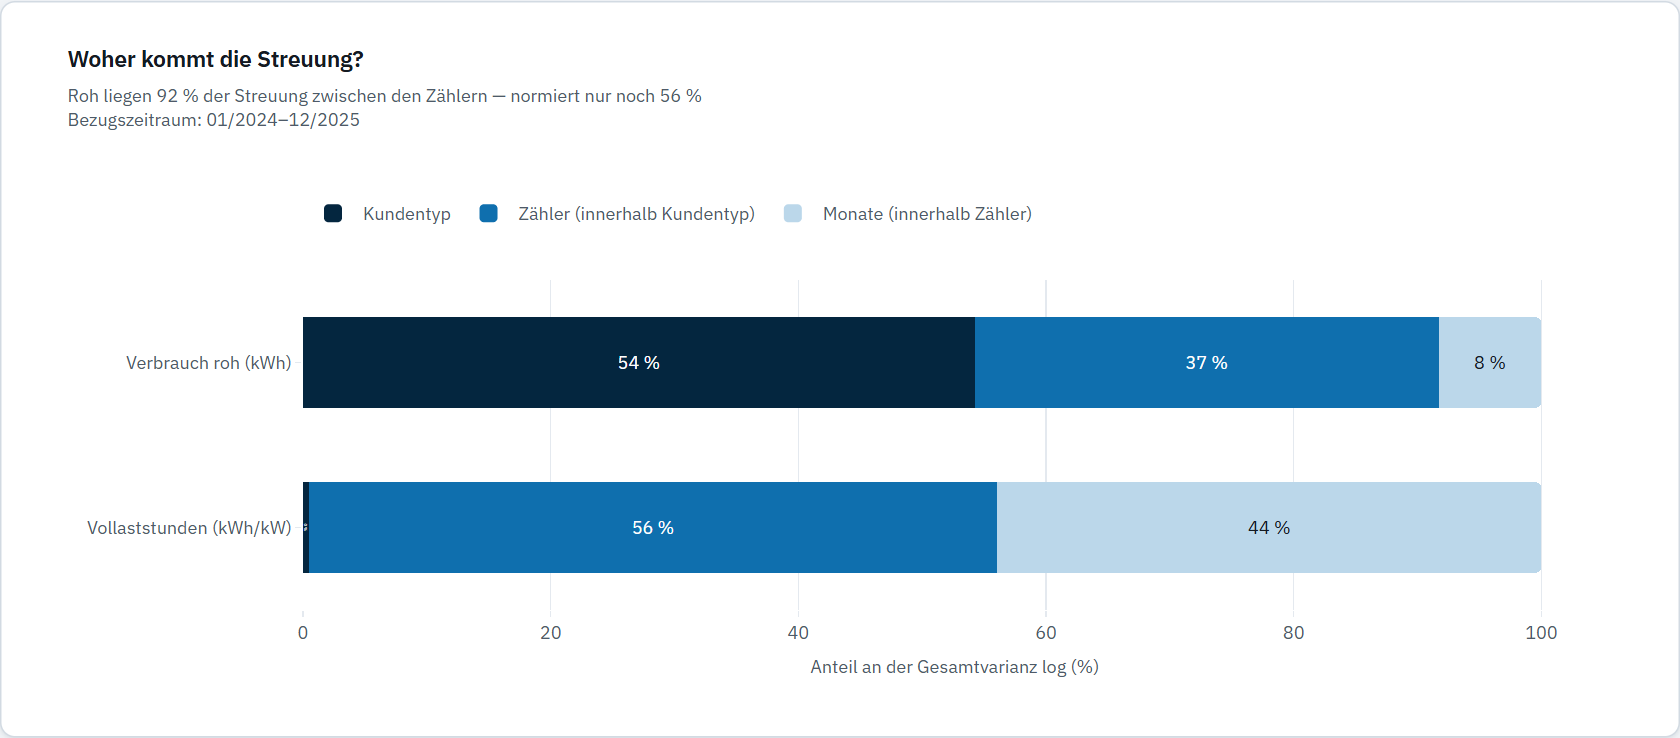

,Verbrauch roh (kWh),Vollaststunden (kWh/kW)
Kundentyp,54.2,0.4
Zähler (innerhalb Kundentyp),37.5,55.6
Monate (innerhalb Zähler),8.3,43.9


In [17]:
def zerlegung(spalte):
    """Varianz der log-Werte in drei Anteile: Kundentyp / Zaehler innerhalb Typ / Monate."""
    x = np.log(df[spalte])
    m_typ = x.groupby(df["kundentyp"], observed=True).transform("mean")
    m_zaehler = x.groupby(df["zaehler_id"]).transform("mean")
    gesamt = x.var()
    return pd.Series({
        "Kundentyp": m_typ.var() / gesamt,
        "Zähler (innerhalb Kundentyp)": (m_zaehler - m_typ).var() / gesamt,
        "Monate (innerhalb Zähler)": (x - m_zaehler).var() / gesamt,
    }) * 100


anteil = pd.DataFrame({"Verbrauch roh (kWh)": zerlegung("verbrauch_kwh"),
                       "Vollaststunden (kWh/kW)": zerlegung("vollaststunden")})
lang = anteil.reset_index(names="quelle").melt(id_vars="quelle", var_name="groesse",
                                                value_name="anteil")

FARBE_QUELLE = {"Kundentyp": ci.SEQUENZIELL[-1],
                "Zähler (innerhalb Kundentyp)": ci.SEQUENZIELL[4],
                "Monate (innerhalb Zähler)": ci.SEQUENZIELL[1]}
fig = px.bar(lang, x="anteil", y="groesse", color="quelle", orientation="h", text="anteil",
             color_discrete_map=FARBE_QUELLE,
             category_orders={"groesse": list(anteil.columns)})
roh = anteil["Verbrauch roh (kWh)"]
vls = anteil["Vollaststunden (kWh/kW)"]
ci.stil(fig, "Woher kommt die Streuung?",
         f"Roh liegen {de(100 - roh.iloc[2], 0)} % der Streuung zwischen den Zählern — "
         f"normiert nur noch {de(100 - vls.iloc[2], 0)} %",
         x_titel="Anteil an der Gesamtvarianz log (%)", y_titel="")
fig.update_traces(texttemplate="%{text:.0f} %", textposition="inside",
                  insidetextanchor="middle")
for spur in fig.data:   # Schrift auf heller Flaeche dunkel, sonst weiss
    spur.textfont = dict(size=12, color=ci.HELL["text"] if spur.name.startswith("Monate")
                         else theme.TOKENS["text-inverse"])
fig.update_layout(barmode="stack", height=320, bargap=0.45)
ci.gitter_x(fig)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

anteil.round(1)

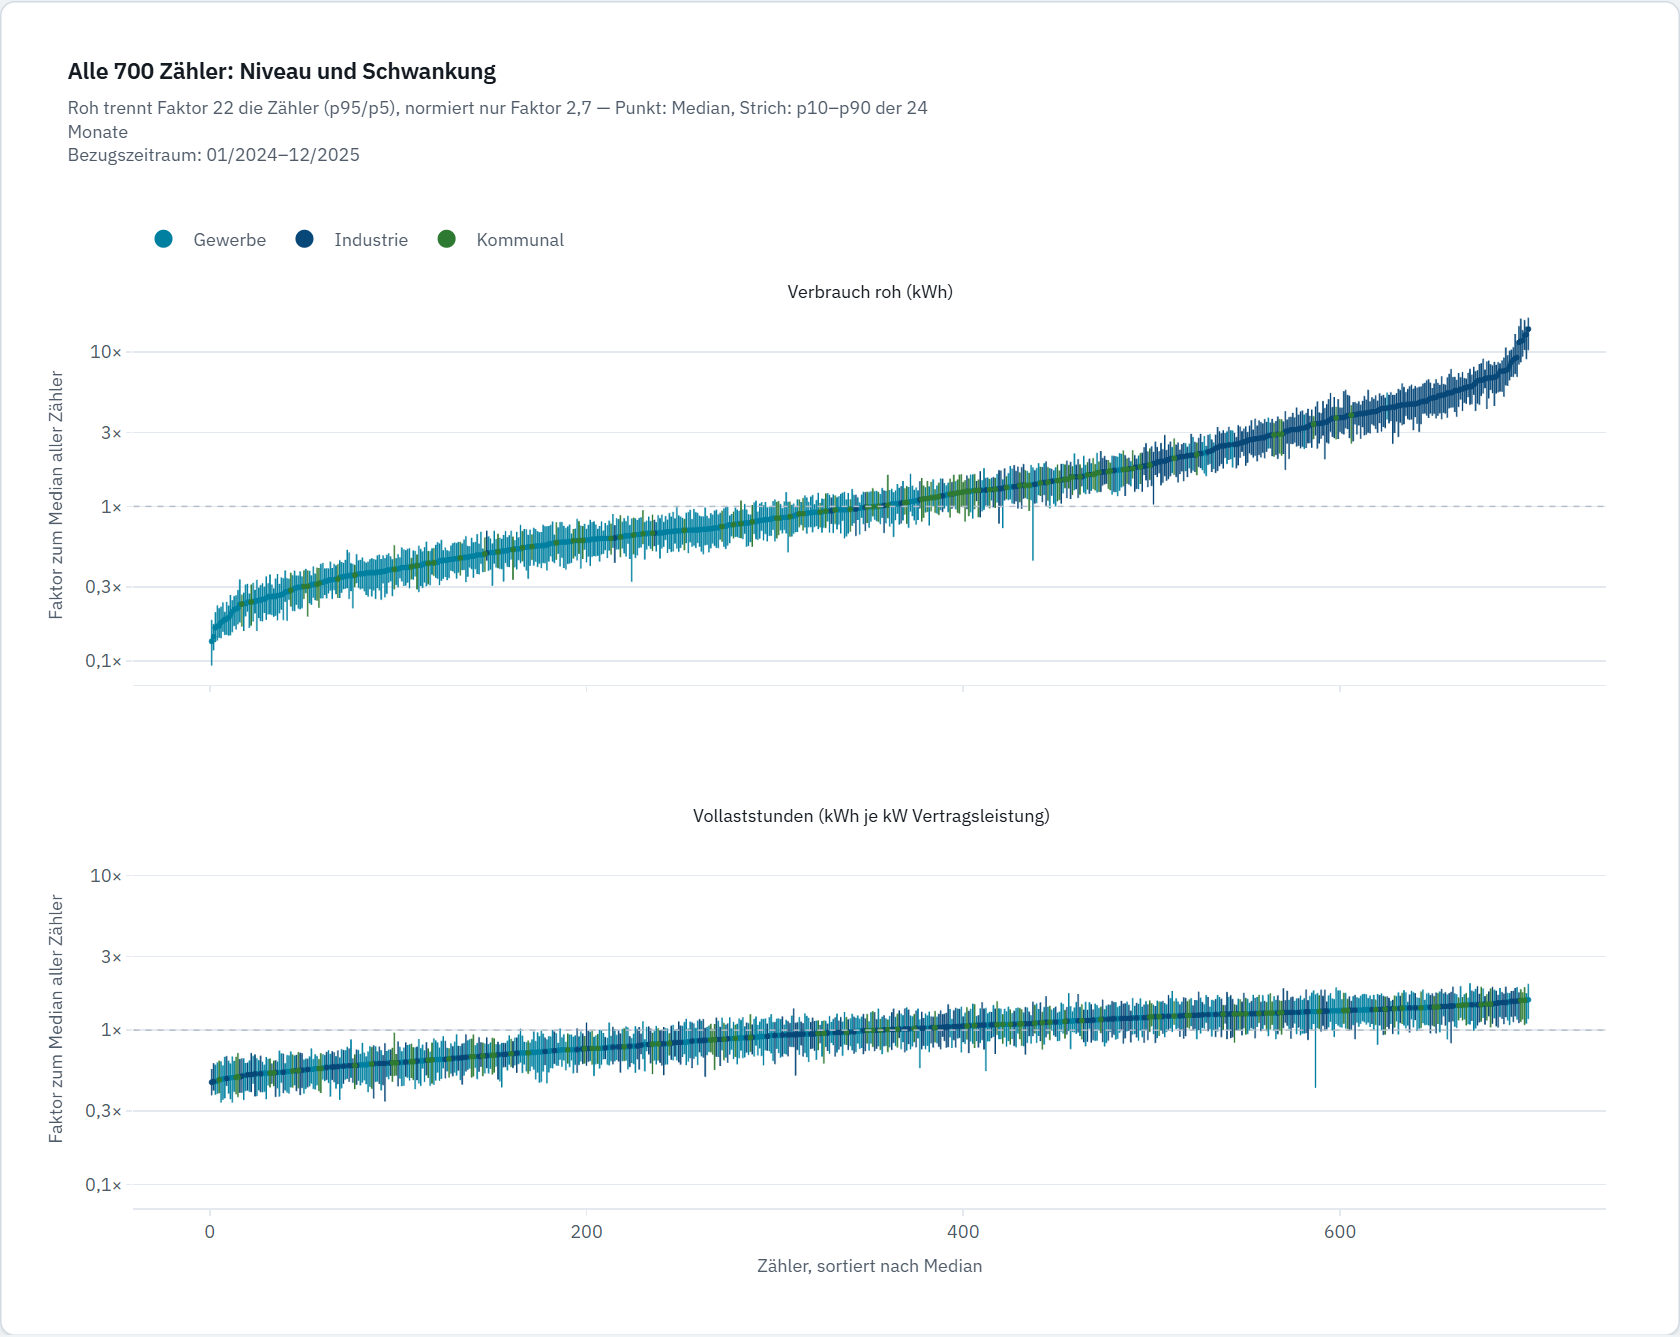

In [18]:
def raupe(fig, zeile, mitte, unten, oben):
    """Je Zaehler ein Punkt (Median) mit Strich von p10 bis p90, sortiert nach Median.
    Skaliert auf den Median aller Zaehler - so teilen beide Panels dieselbe Achse."""
    bezug = zaehler[mitte].median()
    sortiert = zaehler.sort_values(mitte).reset_index(drop=True)
    sortiert["rang"] = np.arange(1, len(sortiert) + 1)
    for typ in TYPEN:
        t = sortiert[sortiert["kundentyp"] == typ]
        fig.add_scattergl(
            x=t["rang"], y=t[mitte] / bezug, mode="markers", name=typ, legendgroup=typ,
            showlegend=zeile == 1, row=zeile, col=1,
            marker=dict(size=4, color=FARBE_TYP[typ], line_width=0),
            error_y=dict(type="data", symmetric=False, array=(t[oben] - t[mitte]) / bezug,
                         arrayminus=(t[mitte] - t[unten]) / bezug, color=FARBE_TYP[typ],
                         thickness=1, width=0),
            customdata=t[["zaehler_id", mitte, unten, oben]],
            hovertemplate="%{customdata[0]}<br>Median %{customdata[1]:,.0f}"
                          "<br>p10–p90: %{customdata[2]:,.0f} – %{customdata[3]:,.0f}"
                          f"<extra>{typ}</extra>")


fig = make_subplots(rows=2, cols=1, vertical_spacing=0.16, shared_xaxes=True, subplot_titles=(
    "Verbrauch roh (kWh)", "Vollaststunden (kWh je kW Vertragsleistung)"))
raupe(fig, 1, "median_kwh", "p10_kwh", "p90_kwh")
raupe(fig, 2, "median_vls", "p10_vls", "p90_vls")

spanne_roh = zaehler["median_kwh"].quantile(.95) / zaehler["median_kwh"].quantile(.05)
spanne_vls = zaehler["median_vls"].quantile(.95) / zaehler["median_vls"].quantile(.05)
ci.stil(fig, "Alle 700 Zähler: Niveau und Schwankung",
         f"Roh trennt Faktor {de(spanne_roh, 0)} die Zähler (p95/p5), normiert nur Faktor "
         f"{de(spanne_vls)} — Punkt: Median, Strich: p10–p90 der 24 Monate")
TICKS = [0.1, 0.3, 1, 3, 10]
fig.update_yaxes(type="log", range=np.log10([0.07, 20]), tickvals=TICKS,
                 ticktext=["0,1×", "0,3×", "1×", "3×", "10×"])
fig.update_yaxes(title_text="Faktor zum Median aller Zähler", row=1, col=1)
fig.update_yaxes(title_text="Faktor zum Median aller Zähler", row=2, col=1)
ci.referenzlinie(fig, 1)
fig.update_xaxes(title_text="Zähler, sortiert nach Median", row=2, col=1)
fig.update_layout(height=840, hovermode="closest")
ci.zeigen(fig)

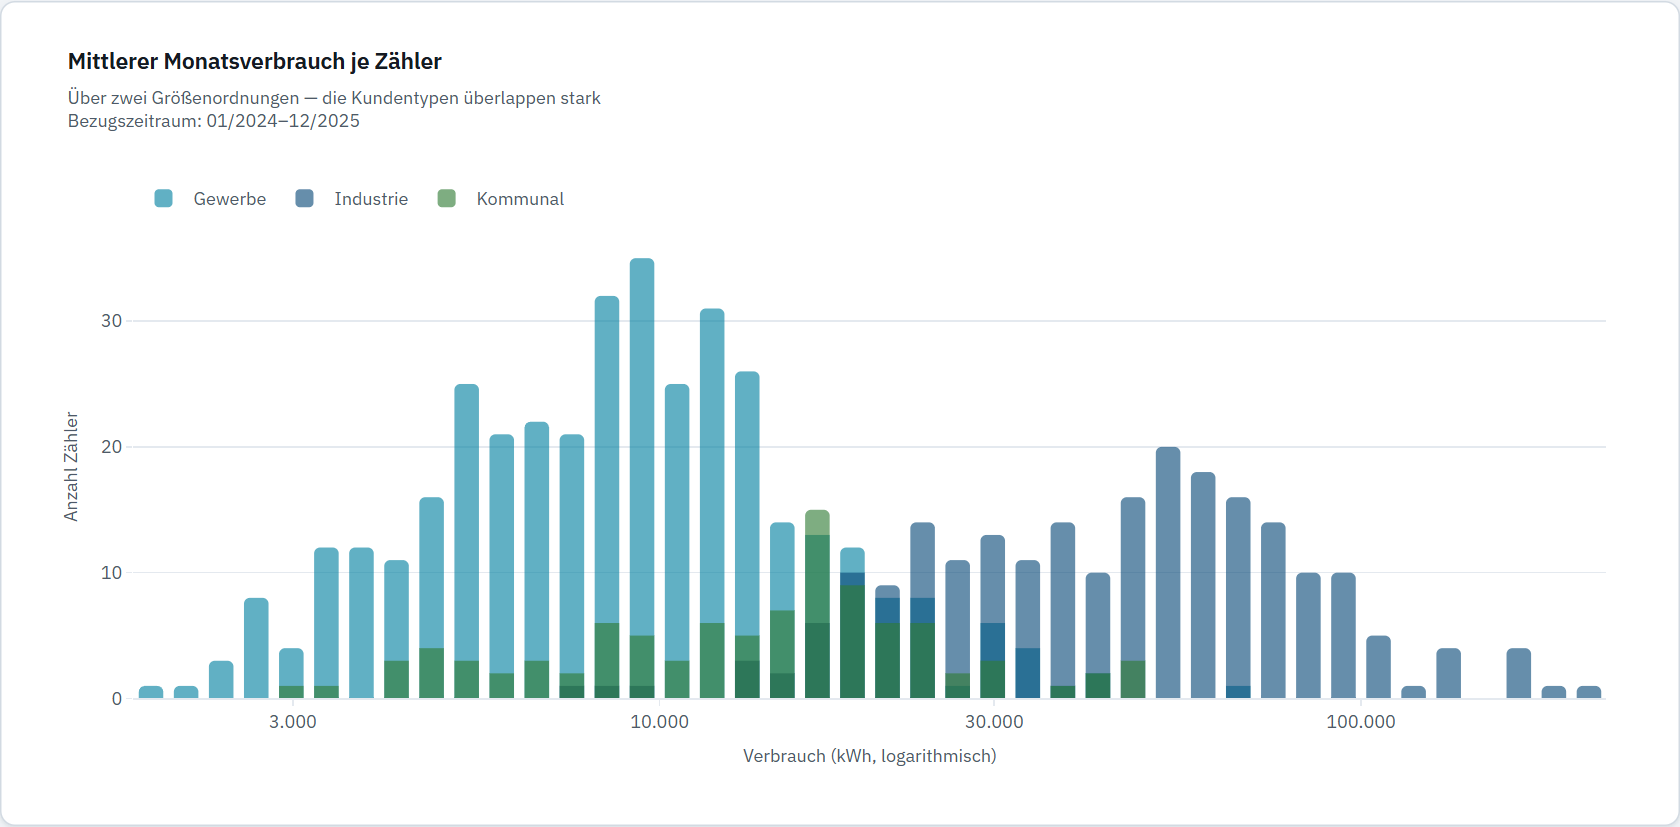

In [19]:
fig = eda.histogram(eda.by_kundentyp(zaehler, "mittel_kwh"), nbins=50, log_x=True)
ci.stil(fig, "Mittlerer Monatsverbrauch je Zähler",
         "Über zwei Größenordnungen — die Kundentypen überlappen stark",
         x_titel="Verbrauch (kWh, logarithmisch)", y_titel="Anzahl Zähler")
log_ticks(fig, "x")
fig.update_layout(bargap=HIST_GAP)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

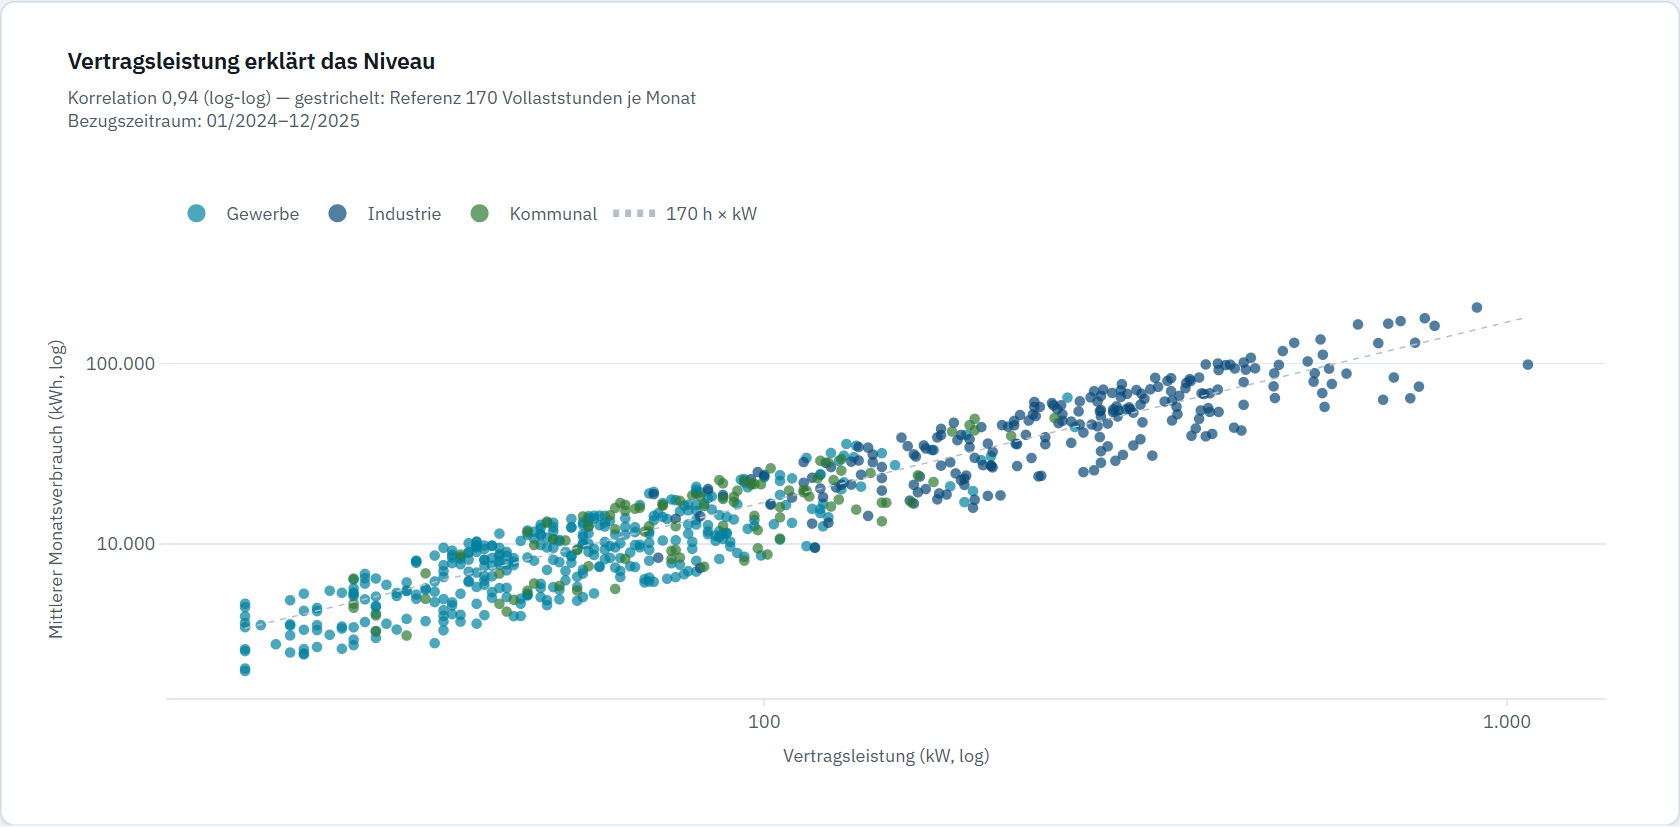

In [20]:
r_kw = np.corrcoef(np.log(zaehler["vertragsleistung_kw"]), np.log(zaehler["mittel_kwh"]))[0, 1]

fig = px.scatter(zaehler, x="vertragsleistung_kw", y="mittel_kwh", color="kundentyp",
                 log_x=True, log_y=True, opacity=0.7, hover_name="zaehler_id", **TYP_STIL)
ci.stil(fig, "Vertragsleistung erklärt das Niveau",
         f"Korrelation {de(r_kw, 2)} (log-log) — gestrichelt: Referenz 170 Vollaststunden je Monat",
         x_titel="Vertragsleistung (kW, log)", y_titel="Mittlerer Monatsverbrauch (kWh, log)")
kw = np.array([zaehler["vertragsleistung_kw"].min(), zaehler["vertragsleistung_kw"].max()])
fig.add_scatter(x=kw, y=kw * 170, mode="lines", name="170 h × kW",
                line=ci.LINIE_REFERENZ, hoverinfo="skip")
fig.update_traces(marker=dict(size=7), selector=dict(mode="markers"))
fig.update_xaxes(dtick=1)
fig.update_yaxes(dtick=1)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

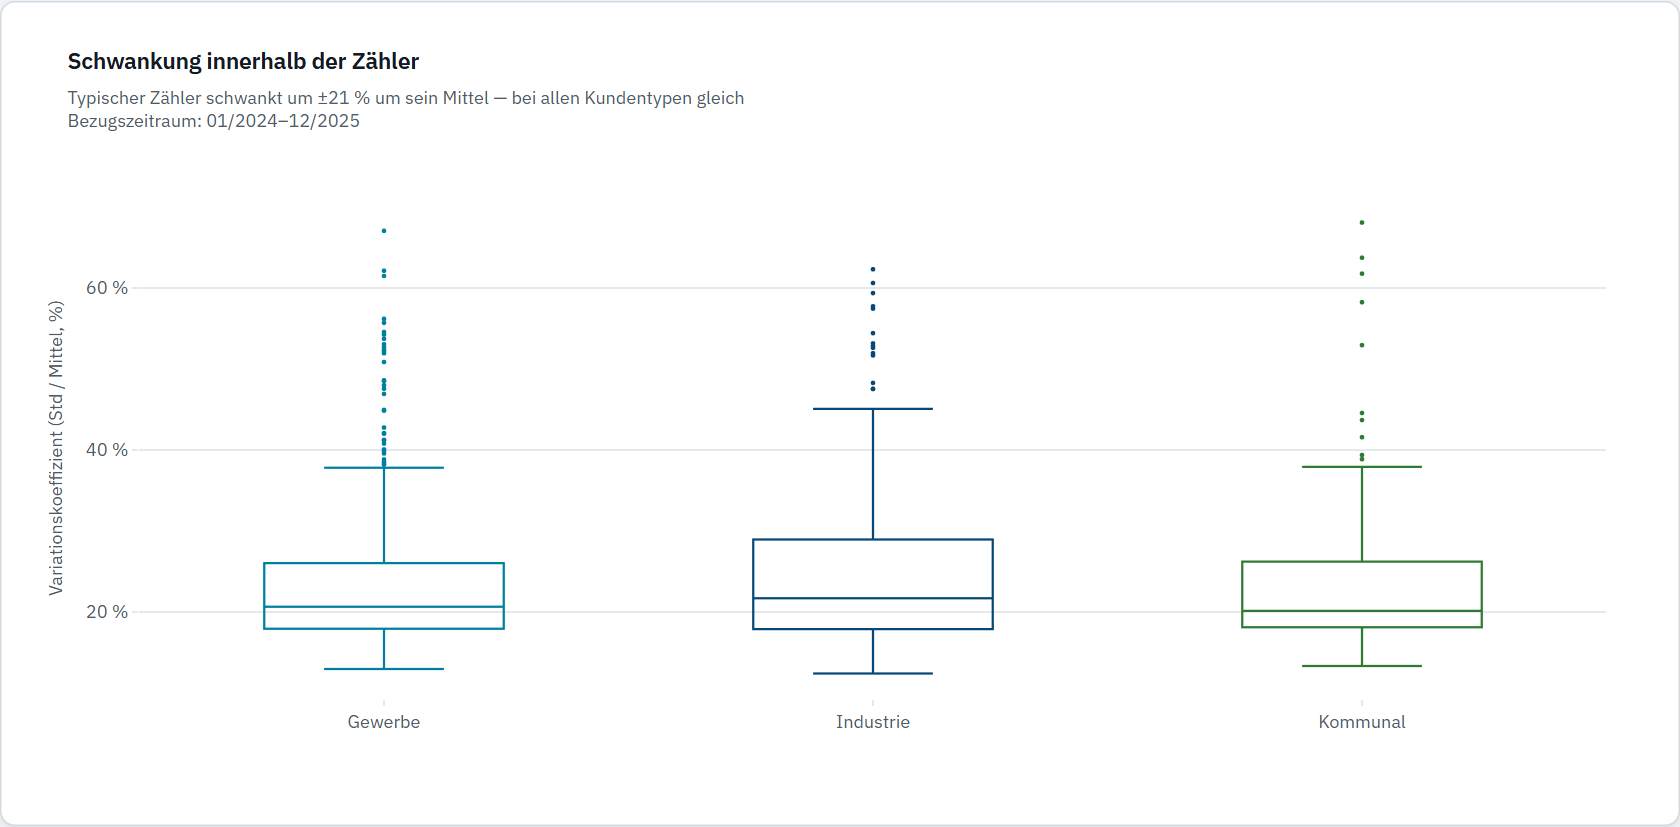

,count,mean,std,min,25%,50%,75%,max
kundentyp,,,,,,,,
Gewerbe,376.0,0.237,0.093,0.130,0.180,0.207,0.260,0.671
Industrie,226.0,0.250,0.104,0.124,0.179,0.217,0.289,0.623
Kommunal,98.0,0.240,0.110,0.133,0.182,0.201,0.262,0.681


In [21]:
fig = eda.boxplot({typ: gruppe["variationskoeffizient"] * 100 for typ, gruppe in zaehler.groupby("kundentyp", observed=True)})
ci.stil(fig, "Schwankung innerhalb der Zähler",
         f"Typischer Zähler schwankt um ±{de(zaehler['variationskoeffizient'].median() * 100, 0)} % "
         "um sein Mittel — bei allen Kundentypen gleich",
         x_titel="", y_titel="Variationskoeffizient (Std / Mittel, %)")
ci.prozent_achse(fig)
fig.update_layout(showlegend=False)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

zaehler.groupby("kundentyp", observed=True)["variationskoeffizient"].describe().round(3)

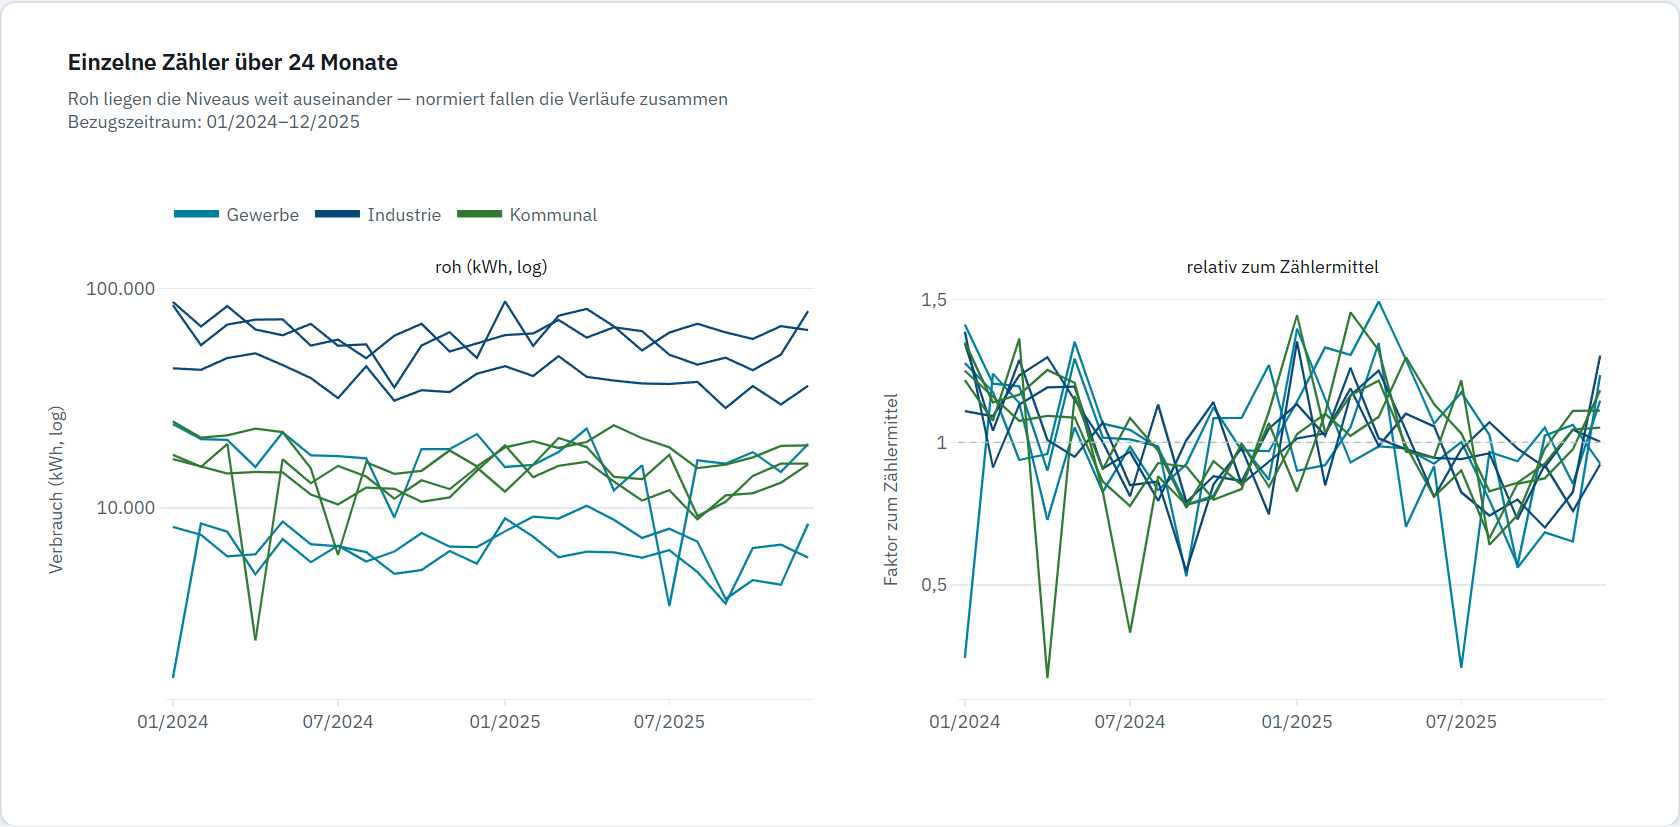

In [22]:
# Einzelverlaeufe: 3 Zaehler je Kundentyp - links roh, rechts normiert
auswahl = (df.groupby("kundentyp", observed=True)["zaehler_id"].unique()
             .apply(lambda z: z[:3]).explode().tolist())
spaghetti = (df[df["zaehler_id"].isin(auswahl)].sort_values("monat")
               .assign(monat_ts=lambda d: d["monat"].dt.to_timestamp()))

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.1,
                    subplot_titles=("roh (kWh, log)", "relativ zum Zählermittel"))
for typ in TYPEN:
    for k, (zid, teil) in enumerate(spaghetti[spaghetti["kundentyp"] == typ].groupby("zaehler_id")):
        for spalte, nr in [("verbrauch_kwh", 1), ("rel_verbrauch", 2)]:
            fig.add_scatter(x=teil["monat_ts"], y=teil[spalte], mode="lines", row=1, col=nr,
                            name=typ, legendgroup=typ, showlegend=(k == 0 and nr == 1),
                            line=dict(color=FARBE_TYP[typ], width=1.5),
                            hovertemplate=f"{zid}<br>%{{x|%m/%Y}}: %{{y:,.2f}}<extra></extra>")
ci.stil(fig, "Einzelne Zähler über 24 Monate",
         "Roh liegen die Niveaus weit auseinander — normiert fallen die Verläufe zusammen")
ci.log_achse(fig, dtick=1, row=1, col=1)
fig.update_yaxes(title_text="Verbrauch (kWh, log)", row=1, col=1)
fig.update_yaxes(title_text="Faktor zum Zählermittel", row=1, col=2)
ci.referenzlinie(fig, 1, row=1, col=2)
fig.update_layout(hovermode="closest")
ci.zeigen(fig)

**Befund:**

- **Zwischen den Zählern liegt fast die ganze Streuung.** Roh entfallen 92 % der
  (log-)Varianz auf Unterschiede zwischen den Zählern, davon 54 Prozentpunkte allein auf
  den Kundentyp. Nur 8 % sind Schwankungen eines Zählers über die Monate.
- **Die Vertragsleistung erklärt das Niveau** (Korrelation 0,94 log-log). Teilt man den
  Verbrauch durch sie, schrumpft die Spanne zwischen den Zählern von Faktor 22 auf
  Faktor 2,7. Der Kundentyp erklärt dann praktisch nichts mehr (0,4 %).
- **Innerhalb eines Zählers** schwankt der Verbrauch typischerweise um ±21 %. Das ist bei
  allen Kundentypen gleich, einzelne Zähler schwanken mit bis zu 68 % deutlich stärker.
- In den Einzelverläufen liegen die Niveaus roh eine Größenordnung auseinander. Normiert
  überlagern sich die Kurven und zeigen dasselbe Jahresmuster.

**Konsequenz:** Zielgröße `vollaststunden = verbrauch_kwh / vertragsleistung_kw`
trainieren und die Vorhersage anschließend zurückrechnen. Bewertet wird immer in kWh.
Damit muss das Modell nicht mehr die Größe eines Zählers lernen, nur noch sein Verhalten.

## 4. Wie unterscheidet sich der Verbrauch nach Kundentyp?

**Entscheidung:** Braucht der Kundentyp ein eigenes Modell, oder reicht er als Feature?

In [23]:
typ_tabelle = (zaehler.groupby("kundentyp", observed=True)
                      .agg(zaehler=("zaehler_id", "size"),
                           median_kw=("vertragsleistung_kw", "median"),
                           median_kwh_monat=("median_kwh", "median"),
                           median_vollaststunden=("median_vls", "median"),
                           variationskoeffizient=("variationskoeffizient", "median"),
                           summe_mwh_monat=("mittel_kwh", lambda s: s.sum() / 1000)))
typ_tabelle["anteil_verbrauch_%"] = typ_tabelle["summe_mwh_monat"] / typ_tabelle["summe_mwh_monat"].sum() * 100
ci.tabellenansicht(typ_tabelle, 2)

,zaehler,median_kw,median_kwh_monat,median_vollaststunden,variationskoeffizient,summe_mwh_monat,anteil_verbrauch_%
kundentyp,,,,,,,
Gewerbe,376,"54,00","8.621,50","162,76","0,21","3.925,65","22,51"
Industrie,226,"272,00","45.943,25","179,22","0,22","11.943,72","68,48"
Kommunal,98,"83,00","14.978,00","177,78","0,20","1.572,82","9,02"


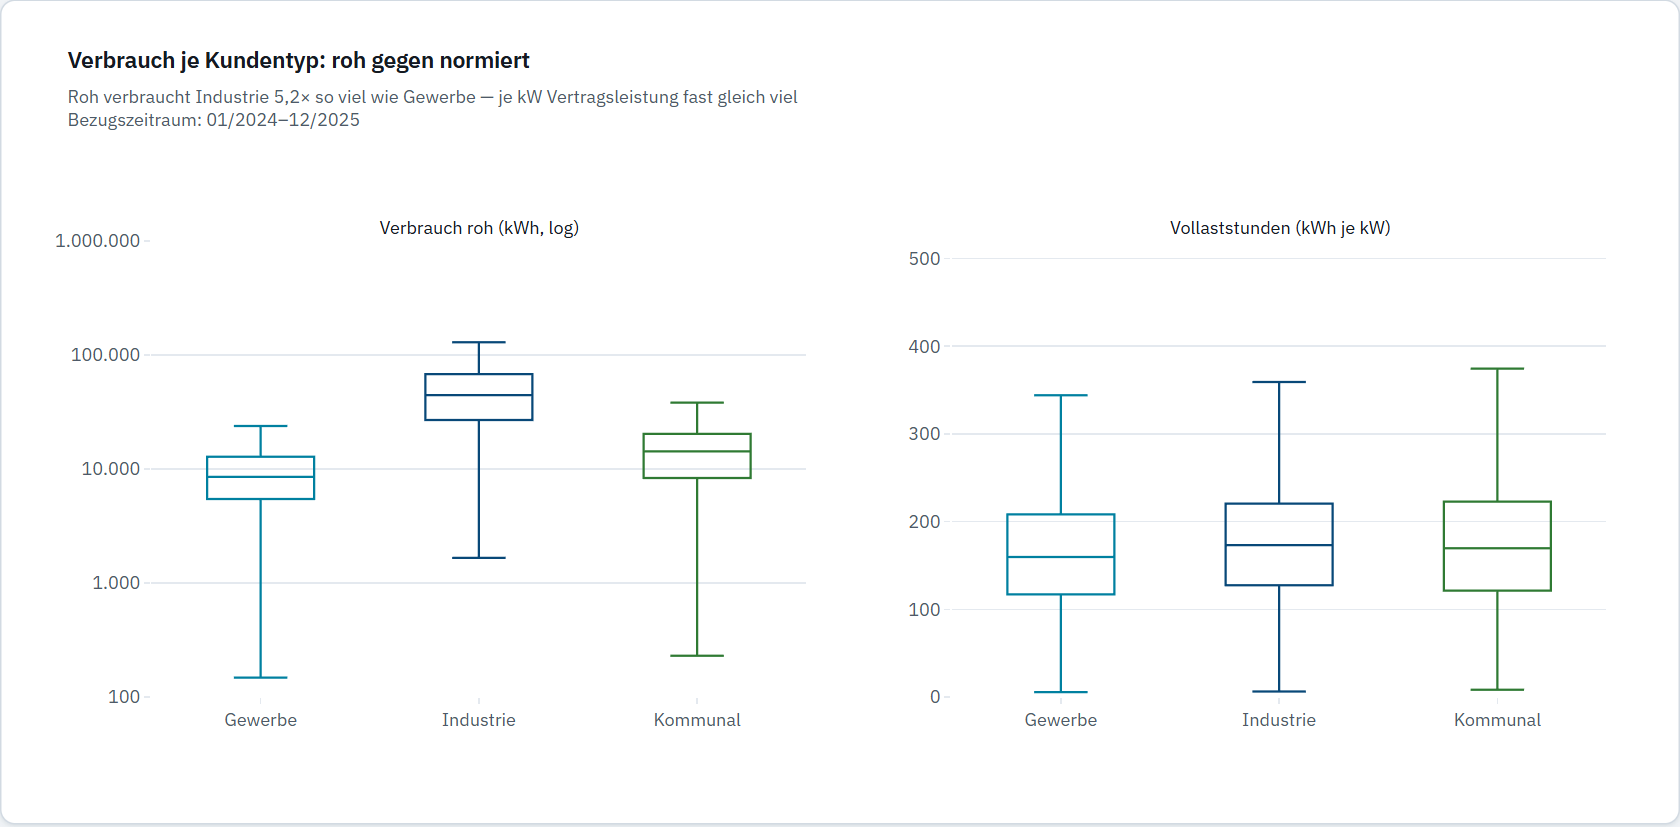

,verbrauch_kwh,vollaststunden
kundentyp,,
Gewerbe,8526.0,159.6
Industrie,44490.5,173.1
Kommunal,14265.0,169.6


In [24]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.1, subplot_titles=(
    "Verbrauch roh (kWh, log)", "Vollaststunden (kWh je kW)"))
for typ in TYPEN:
    teil = df[df["kundentyp"] == typ]
    for spalte, nr in [("verbrauch_kwh", 1), ("vollaststunden", 2)]:
        fig.add_box(y=teil[spalte], x=[typ] * len(teil), name=typ, row=1, col=nr,
                    marker_color=FARBE_TYP[typ], boxpoints=False, legendgroup=typ,
                    showlegend=False)

med = df.groupby("kundentyp", observed=True)[["verbrauch_kwh", "vollaststunden"]].median()
ci.stil(fig, "Verbrauch je Kundentyp: roh gegen normiert",
         f"Roh verbraucht Industrie {de(med.loc['Industrie', 'verbrauch_kwh'] / med.loc['Gewerbe', 'verbrauch_kwh'])}× "
         "so viel wie Gewerbe — je kW Vertragsleistung fast gleich viel")
ci.log_achse(fig, dtick=1, range=[2, 6], row=1, col=1)
fig.update_yaxes(range=[0, 520], row=1, col=2)
iqr_whisker(fig)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

med.round(1)

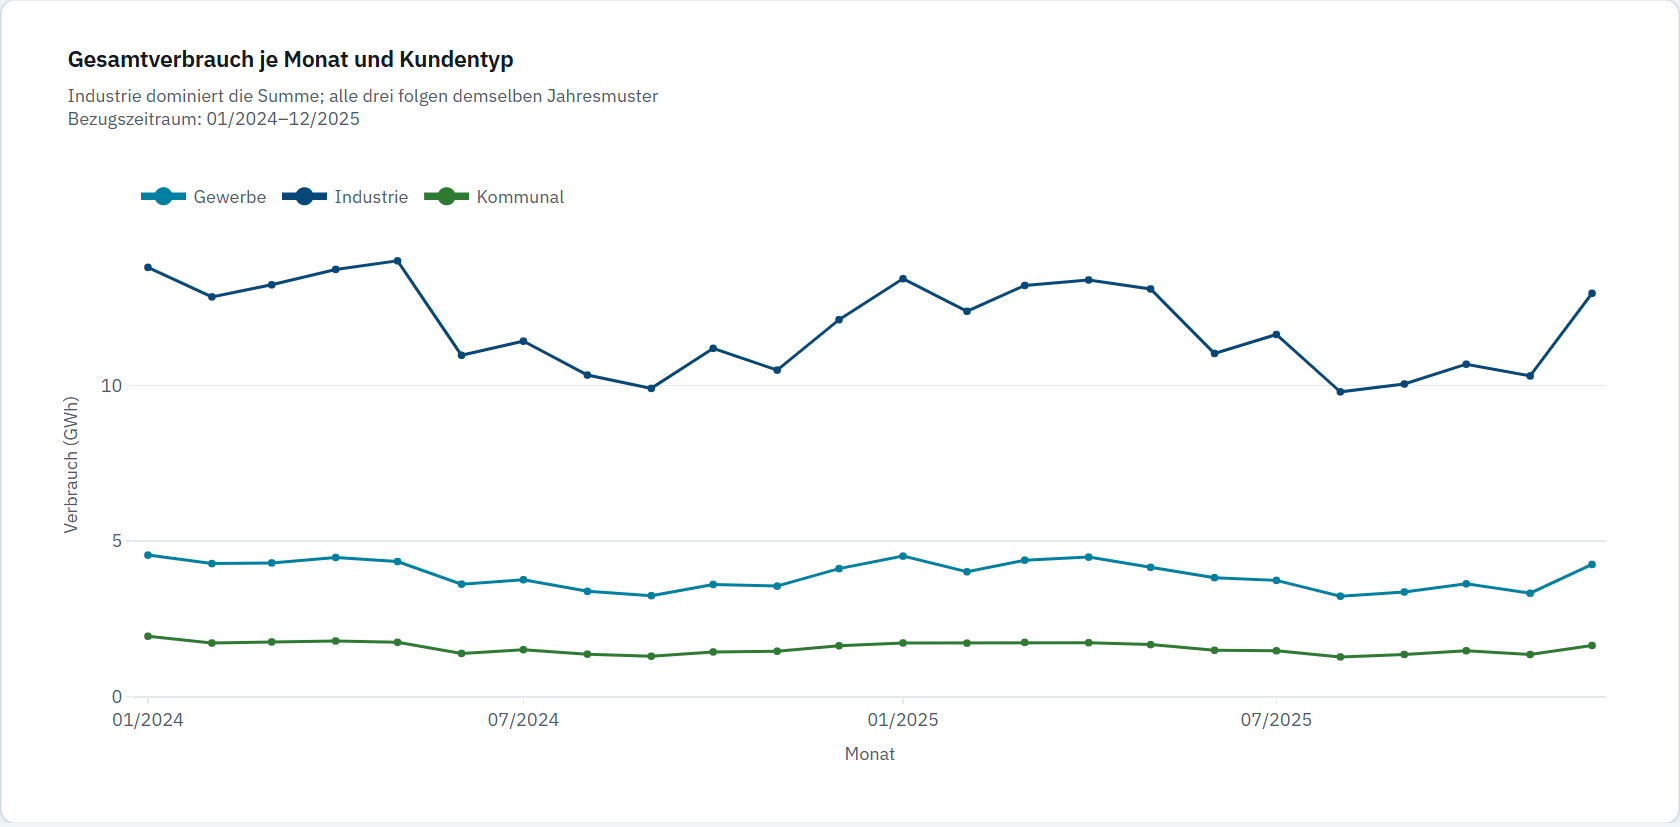

In [25]:
zeitreihe = (df.groupby(["monat", "kundentyp"], observed=True)["verbrauch_kwh"].sum()
               .div(1e6).reset_index(name="gwh")
               .assign(monat=lambda d: d["monat"].dt.to_timestamp()))

verlauf = zeitreihe.pivot(index="monat", columns="kundentyp", values="gwh")
fig = eda.seasonality(verlauf.index, {typ: verlauf[typ] for typ in TYPEN})
ci.stil(fig, "Gesamtverbrauch je Monat und Kundentyp",
         "Industrie dominiert die Summe; alle drei folgen demselben Jahresmuster",
         x_titel="Monat", y_titel="Verbrauch (GWh)")
fig.update_yaxes(rangemode="tozero")
ci.zeigen(fig)

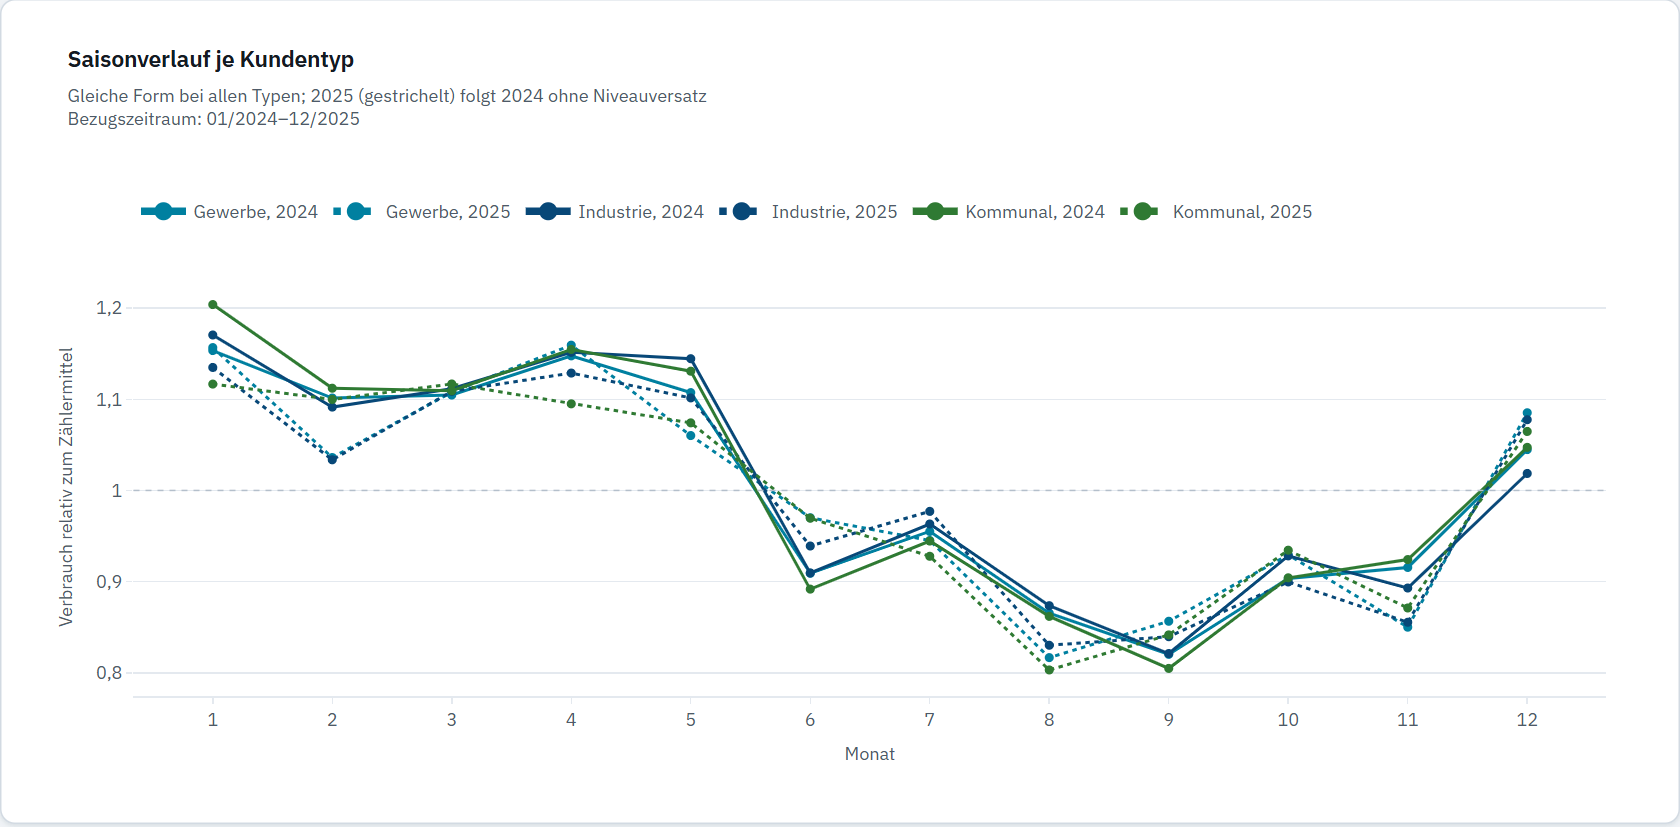

In [26]:
saison = (df.groupby(["monat_idx", "jahr", "kundentyp"], as_index=False, observed=True)
            ["rel_verbrauch"].mean())
saison["jahr"] = saison["jahr"].astype(str)

fig = px.line(saison, x="monat_idx", y="rel_verbrauch", color="kundentyp",
              line_dash="jahr", markers=True, **TYP_STIL)
ci.stil(fig, "Saisonverlauf je Kundentyp",
         "Gleiche Form bei allen Typen; 2025 (gestrichelt) folgt 2024 ohne Niveauversatz",
         x_titel="Monat", y_titel="Verbrauch relativ zum Zählermittel")
ci.referenzlinie(fig, 1)
fig.update_xaxes(tickmode="array", tickvals=list(range(1, 13)))
ci.zeigen(fig)

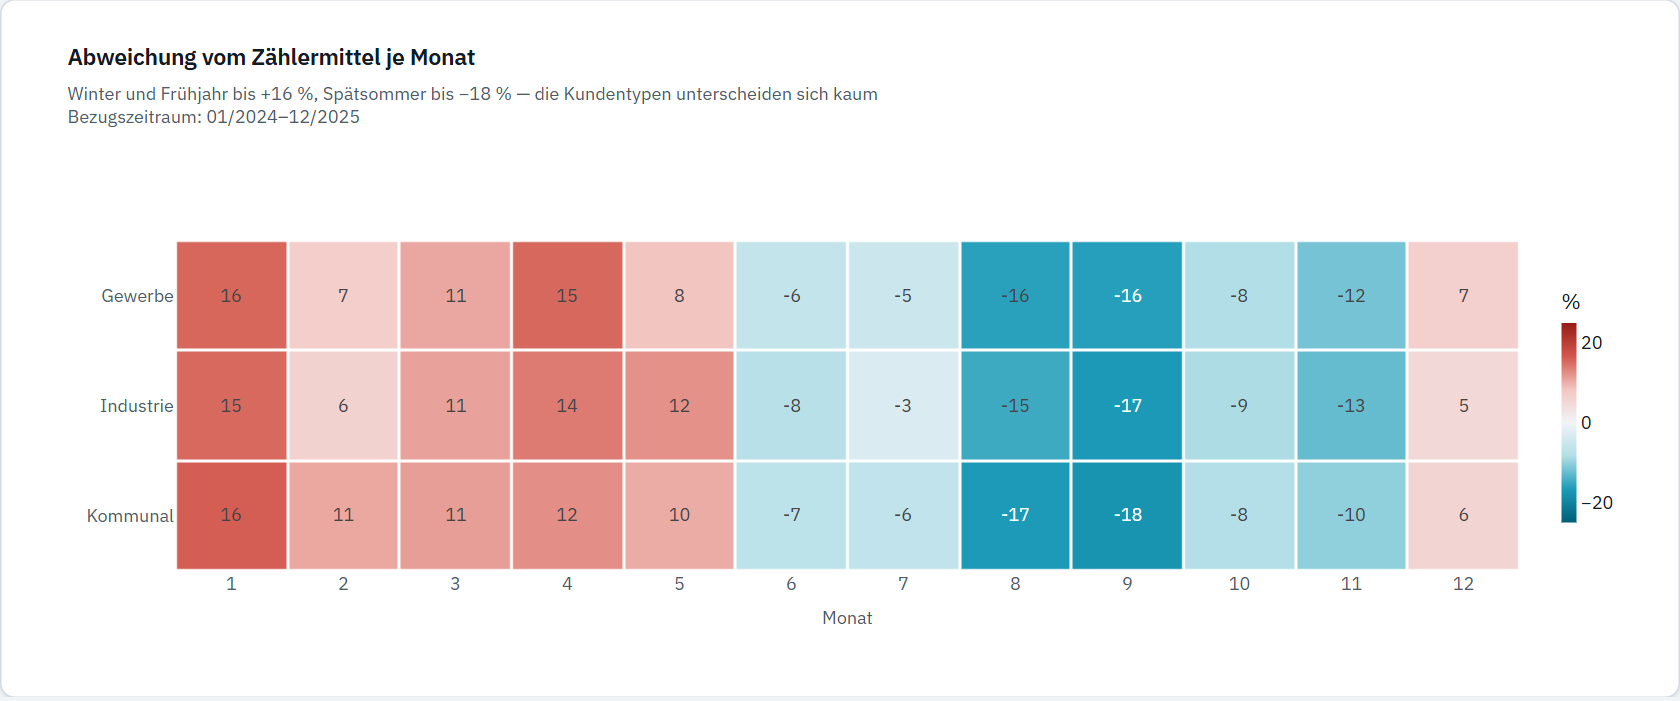

In [27]:
# Heatmap: Abweichung vom Zaehlermittel je Kalendermonat und Kundentyp
matrix = (df.groupby(["kundentyp", "monat_idx"], observed=True)["rel_verbrauch"].mean()
            .unstack().sub(1).mul(100).reindex(TYPEN))

fig = px.imshow(matrix, text_auto=".0f", aspect="auto", zmin=-25, zmax=25,
                color_continuous_scale=ci.DIVERGIEREND)
ci.stil(fig, "Abweichung vom Zählermittel je Monat",
         f"Winter und Frühjahr bis +{de(matrix.max().max(), 0)} %, Spätsommer bis "
         f"−{de(-matrix.min().min(), 0)} % — die Kundentypen unterscheiden sich kaum",
         x_titel="Monat", y_titel="")
fig.update_xaxes(tickmode="array", tickvals=list(range(1, 13)), showline=False)
fig.update_yaxes(showgrid=False)
fig.update_layout(height=320, coloraxis_colorbar_title_text="%")
fig.update_traces(hovertemplate="%{y}, Monat %{x}: %{z:+.1f} %<extra></extra>")
ci.zeigen(fig)

**Befund:**

- **Absolut** unterscheiden sich die Kundentypen stark: Ein Industriezähler verbraucht im
  Median 44,5 MWh im Monat, ein Kommunalzähler 14,3 MWh und ein Gewerbezähler 8,5 MWh.
  Der Faktor Industrie/Gewerbe liegt bei 5,2.
- **Je kW Vertragsleistung** verschwindet der Unterschied fast: Gewerbe kommt auf 160,
  Kommunal auf 170 und Industrie auf 173 Vollaststunden im Median. Gewerbe nutzt seine
  Leistung etwas weniger aus.
- **Zeitlich** trägt Industrie die Monatssumme (10 bis 14 GWh). Alle drei Typen folgen
  aber demselben Jahresmuster. Die Heatmap zeigt: Die Abweichung vom Zählermittel
  unterscheidet sich zwischen den Typen je Monat nur um wenige Prozentpunkte.
- Das Jahresmuster ist **keine reine Temperaturkurve**. Der April liegt fast so hoch wie
  der Januar, obwohl er rund 9 °C wärmer ist. Das passt zum Produktionsplan, der im
  Frühjahr seinen Höchststand hat (5.3).

**Konsequenz:** Kein eigenes Modell je Kundentyp nötig. Der Kundentyp geht als
kategoriales Feature ein und fängt die kleinen Niveauunterschiede der Vollaststunden ab.

## 5. Bivariate Analyse: Was treibt den Verbrauch?

**Entscheidung:** Welche Features kommen ins Modell — und in welcher Form?

Weil die Niveauunterschiede alles überdecken (Abschnitt 3), wird hier meist gegen den
**relativen Verbrauch** (Wert / Zählermittel) geprüft.

### 5.1 Korrelationen im Überblick

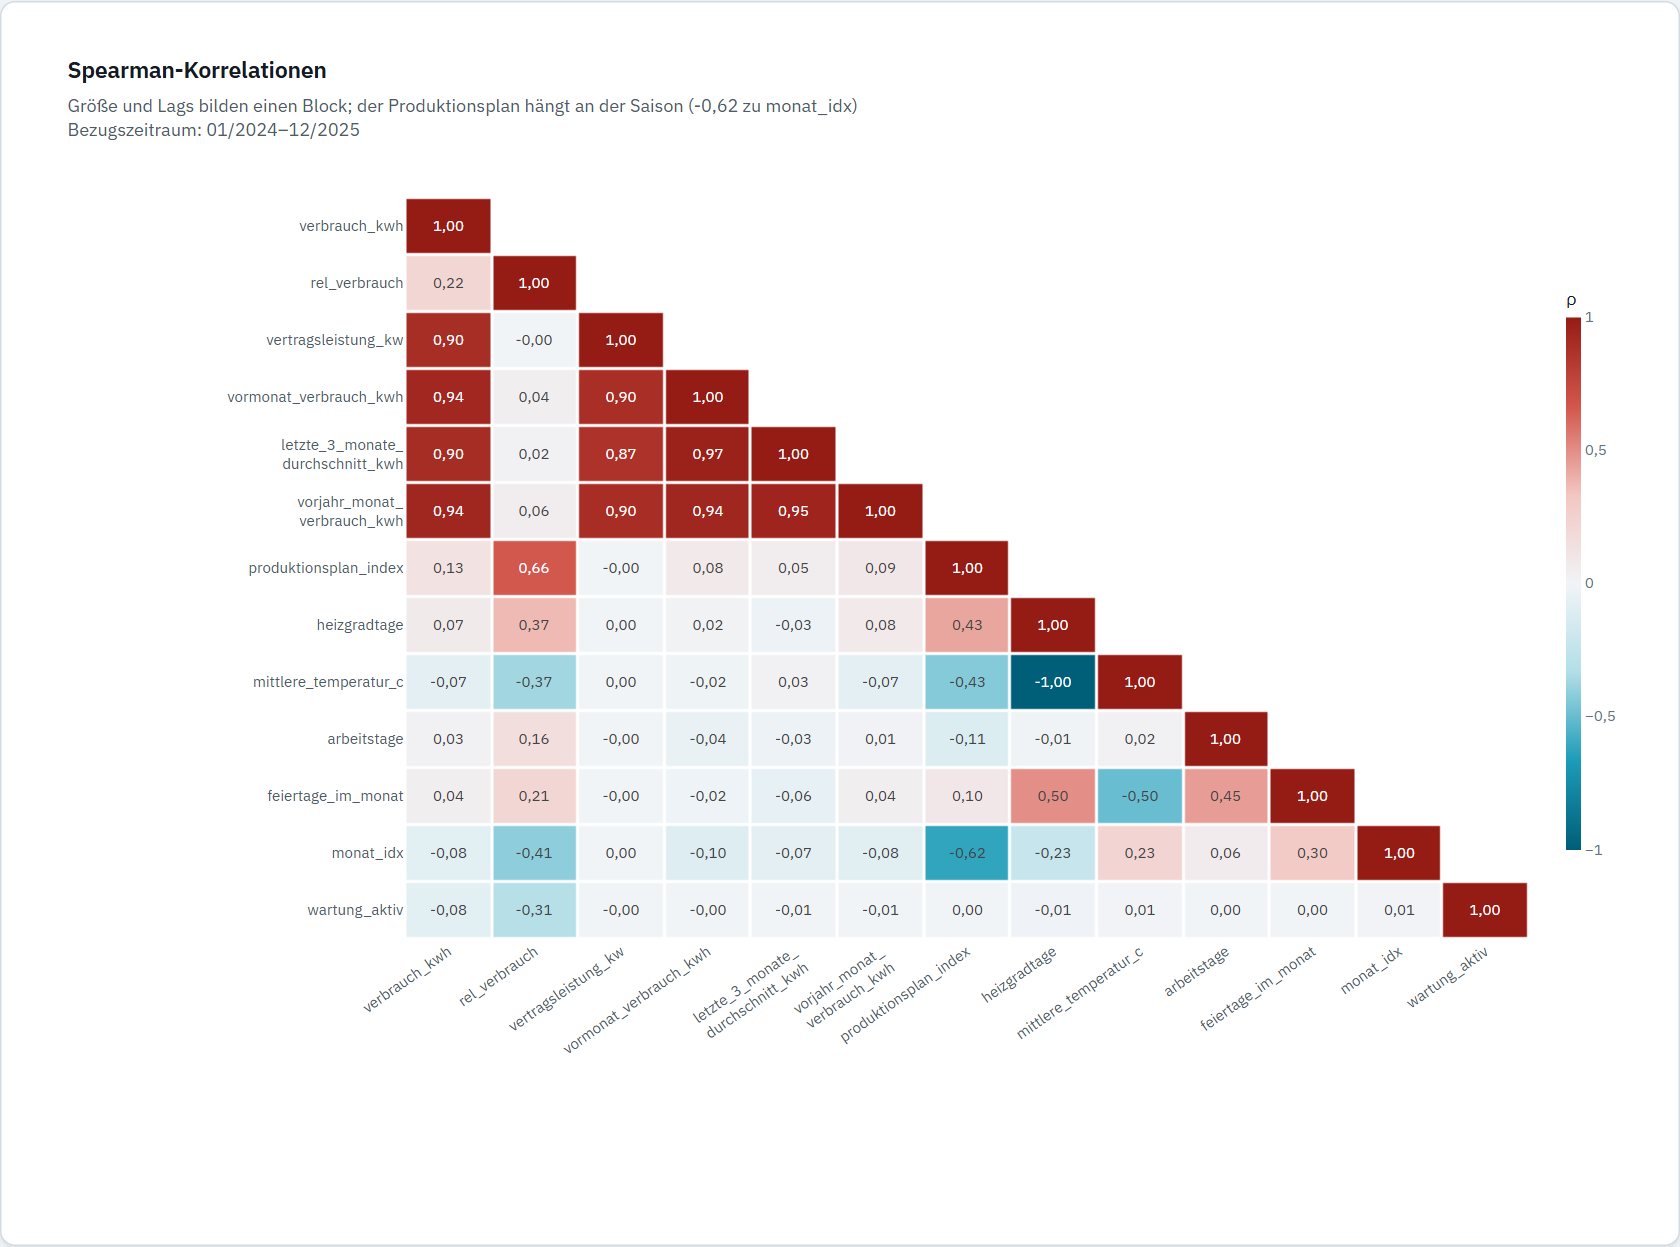

In [28]:
NUMERISCH = ["verbrauch_kwh", "rel_verbrauch", "vertragsleistung_kw", "vormonat_verbrauch_kwh",
             "letzte_3_monate_durchschnitt_kwh", "vorjahr_monat_verbrauch_kwh",
             "produktionsplan_index", "heizgradtage", "mittlere_temperatur_c",
             "arbeitstage", "feiertage_im_monat", "monat_idx", "wartung_aktiv"]
kmat = df[NUMERISCH].astype(float).corr(method="spearman")
maske = np.triu(np.ones_like(kmat, dtype=bool), k=1)   # obere Haelfte ist redundant

matrix_anzeige = kmat.mask(maske).copy()
matrix_anzeige.columns = [ci.label_umbruch(name) for name in matrix_anzeige.columns]
fig = eda.correlation(matrix_anzeige)
fig.update_traces(text=[["" if pd.isna(wert) else de(wert, 2) for wert in zeile] for zeile in matrix_anzeige.to_numpy()])
ci.stil(fig, "Spearman-Korrelationen",
         "Größe und Lags bilden einen Block; der Produktionsplan hängt an der Saison "
         f"({de(kmat.loc['produktionsplan_index', 'monat_idx'], 2)} zu monat_idx)")
fig.update_traces(hovertemplate="%{y} × %{x}: %{z:.2f}<extra></extra>",
                  textfont=dict(size=ci.GROESSE_KLEIN))
fig.update_xaxes(tickangle=-35, showline=False)
fig.update_yaxes(showgrid=False)
fig.update_layout(height=780, margin_l=245, margin_b=180)
fig.update_traces(colorbar_title_text="ρ")
ci.zeigen(fig)

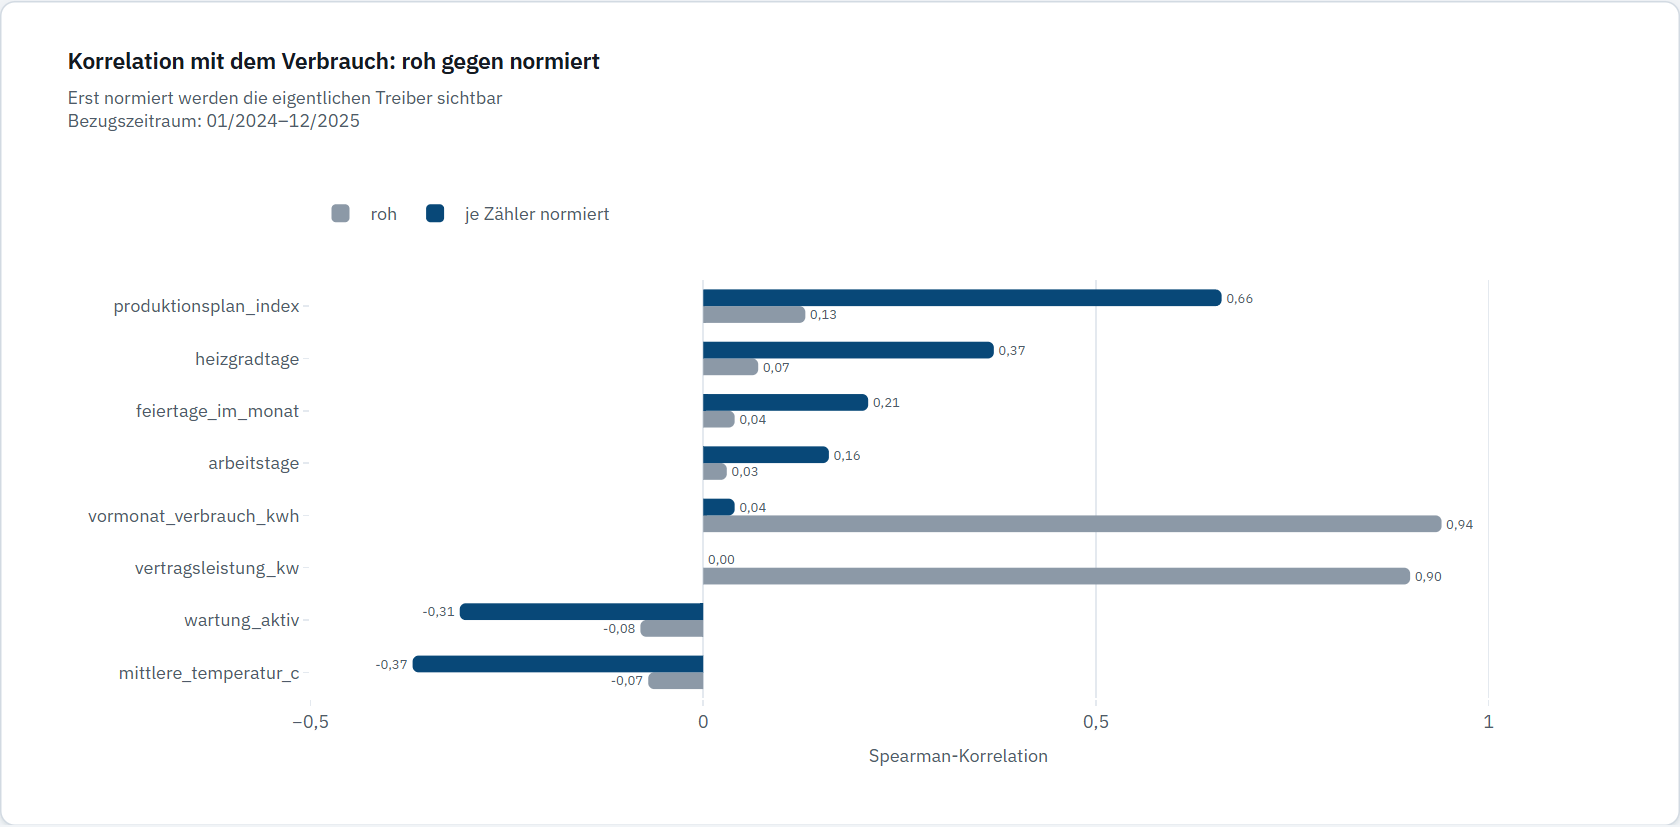

,roh,je Zähler normiert
mittlere_temperatur_c,-0.07,-0.37
wartung_aktiv,-0.08,-0.31
vertragsleistung_kw,0.90,-0.00
vormonat_verbrauch_kwh,0.94,0.04
arbeitstage,0.03,0.16
feiertage_im_monat,0.04,0.21
heizgradtage,0.07,0.37
produktionsplan_index,0.13,0.66


In [29]:
TREIBER = ["vormonat_verbrauch_kwh", "vertragsleistung_kw", "produktionsplan_index",
           "heizgradtage", "mittlere_temperatur_c", "arbeitstage",
           "feiertage_im_monat", "wartung_aktiv"]

korr = pd.DataFrame({
    "roh": df[TREIBER].astype(float).corrwith(df["verbrauch_kwh"], method="spearman"),
    "je Zähler normiert": df[TREIBER].astype(float).corrwith(df["rel_verbrauch"], method="spearman"),
}).round(2).sort_values("je Zähler normiert")

lang = korr.reset_index(names="treiber").melt(id_vars="treiber",
                                              var_name="sicht", value_name="korrelation")

fig = px.bar(lang, x="korrelation", y="treiber", color="sicht",
             barmode="group", text="korrelation",
             color_discrete_sequence=[NEUTRAL, ci.SERIE[0]])
ci.stil(fig, "Korrelation mit dem Verbrauch: roh gegen normiert",
         "Erst normiert werden die eigentlichen Treiber sichtbar",
         x_titel="Spearman-Korrelation", y_titel="")
ci.hover_pro_marke(fig)
ci.gitter_x(fig)
fig.update_traces(texttemplate="%{x:.2f}", textposition="outside",
                  textfont=ci.LABEL_SCHRIFT, cliponaxis=False)
fig.update_xaxes(range=[-0.5, 1.15])
ci.zeigen(fig)

korr

**Befund:** Roh korrelieren nur die Größenvariablen mit dem Verbrauch (Vormonat 0,94,
Vertragsleistung 0,90). Sie messen dieselbe Information, die Größe des Zählers.
Normiert treten die eigentlichen Treiber hervor: `produktionsplan_index` (0,66),
`heizgradtage` (0,37) bzw. `mittlere_temperatur_c` (−0,37) und `wartung_aktiv` (−0,31).
Arbeits- und Feiertage wirken schwach.

In der Matrix fallen zwei Abhängigkeiten *zwischen* den Treibern auf:
Temperatur und Heizgradtage sind praktisch identisch (−1,00). Der Produktionsplan hängt
an der Saison (−0,62 zu `monat_idx`, +0,43 zu `heizgradtage`).

**Konsequenz:** Die Treiber müssen gemeinsam betrachtet werden, einzeln überschätzt man
die saisonalen Größen (siehe 5.3).

### 5.2 Temperatur oder Heizgradtage?

Beide ins Modell — oder nur eine? Und wie gehen wir mit den fehlenden Temperaturwerten um?

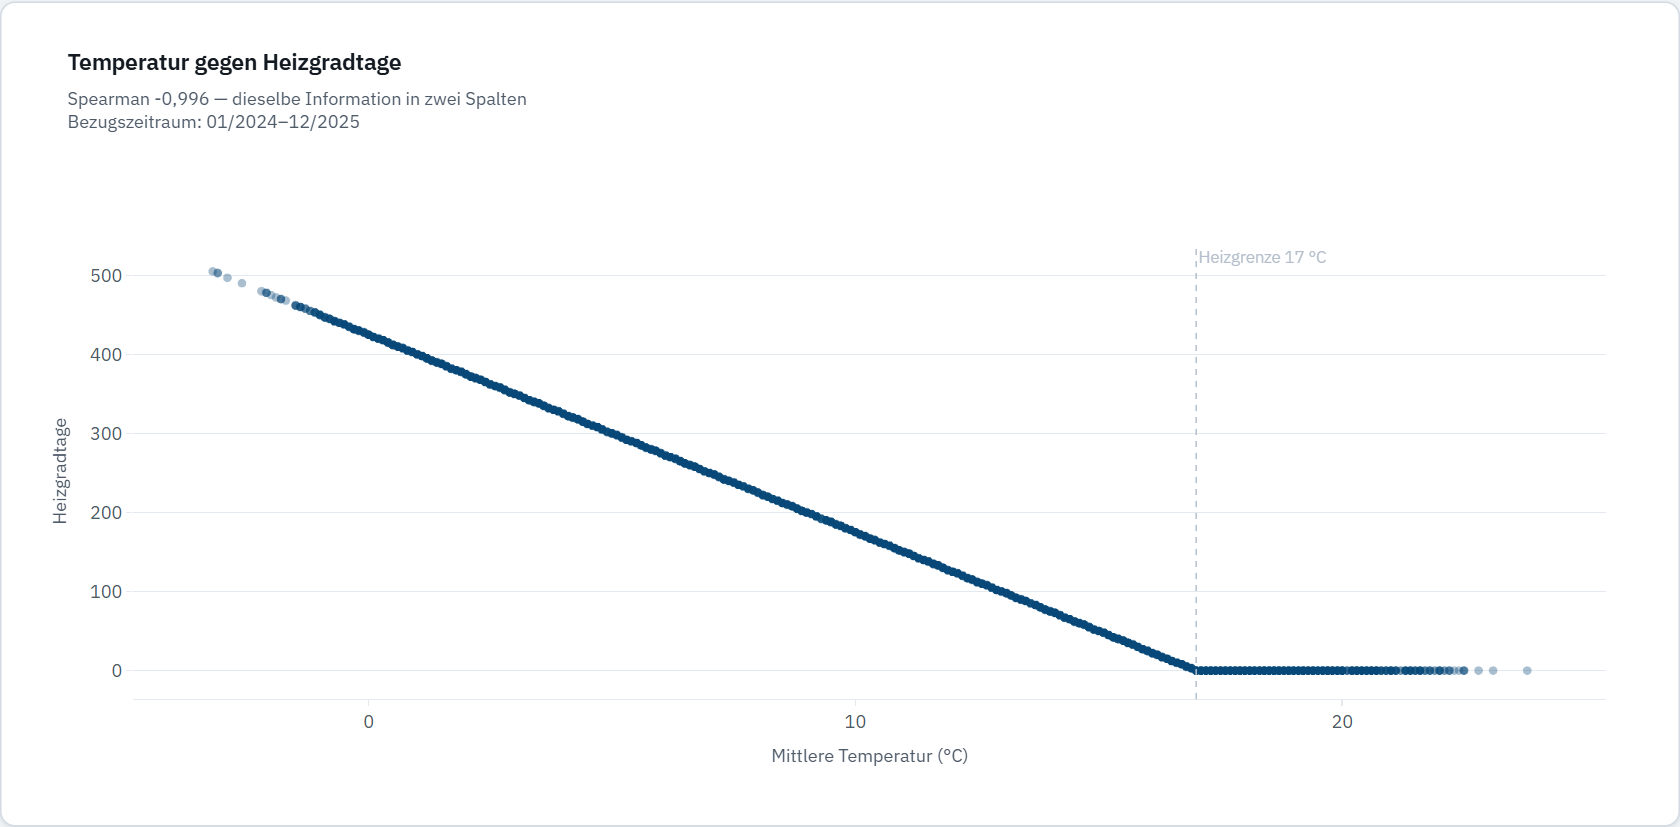

Fehlwerte mittlere_temperatur_c:  503
Fehlwerte heizgradtage:             0


In [30]:
r = df[["mittlere_temperatur_c", "heizgradtage"]].corr(method="spearman").iloc[0, 1]

fig = px.scatter(stichprobe, x="mittlere_temperatur_c", y="heizgradtage", opacity=0.35,
                 color_discrete_sequence=[ci.SERIE[0]])
ci.stil(fig, "Temperatur gegen Heizgradtage",
         f"Spearman {de(r, 3)} — dieselbe Information in zwei Spalten",
         x_titel="Mittlere Temperatur (°C)", y_titel="Heizgradtage")
ci.referenzlinie(fig, 17, "Heizgrenze 17 °C", achse="x", position="top right")
ci.hover_pro_marke(fig)
fig.update_traces(marker=dict(size=6))
ci.zeigen(fig)

print(f"Fehlwerte mittlere_temperatur_c: {df['mittlere_temperatur_c'].isna().sum():>4}")
print(f"Fehlwerte heizgradtage:          {df['heizgradtage'].isna().sum():>4}")

**Befund:** Die Punkte liegen auf einer Linie, nicht in einer Wolke. Die Heizgradtage
sind **rechnerisch aus der Temperatur abgeleitet**, mit einer Heizgrenze bei 17 °C:
Darüber sind sie exakt null, darunter steigen sie linear. Beide Spalten tragen also
dieselbe Information (Spearman −0,996). `heizgradtage` ist vollständig,
`mittlere_temperatur_c` hat 503 Lücken.

**Konsequenz:** Nur `heizgradtage` verwenden. Das vermeidet Kollinearität und löst das
Fehlwertproblem ohne Imputation.

### 5.3 Produktionsplan und Heizgradtage: Sind die Zusammenhänge linear?

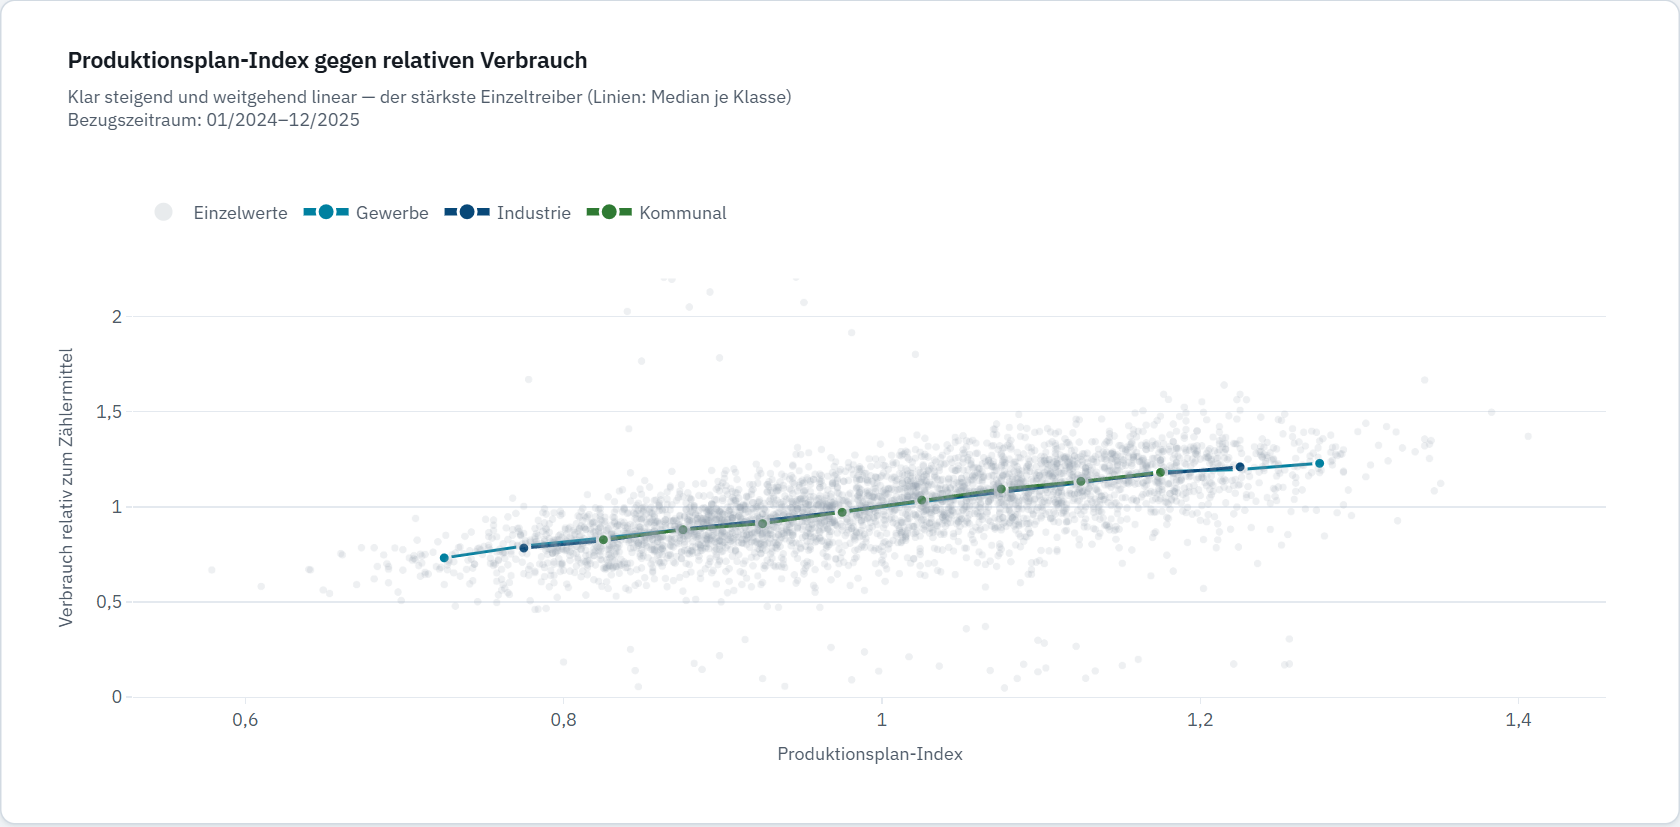

In [31]:
def median_je_klasse(spalte, schritte, min_n=100):
    # Median des relativen Verbrauchs je Klasse und Kundentyp.
    # Duenn besetzte Klassen fliegen raus - sonst zeigt der Rand nur Rauschen.
    klassen = pd.cut(df[spalte], bins=schritte)
    je_klasse = (df.assign(klasse=klassen.map(lambda i: i.mid if pd.notna(i) else np.nan))
                   .dropna(subset=["klasse"])
                   .groupby(["klasse", "kundentyp"], as_index=False, observed=True)
                   ["rel_verbrauch"].agg(["median", "size"]))
    je_klasse["klasse"] = je_klasse["klasse"].astype(float)
    return (je_klasse[je_klasse["size"] >= min_n]
            .rename(columns={"median": "rel_verbrauch"}))


# Punktwolke neutral im Hintergrund, die Aussage tragen die Medianlinien
fig = px.scatter(stichprobe, x="produktionsplan_index", y="rel_verbrauch",
                 opacity=0.15, color_discrete_sequence=[NEUTRAL])
fig.update_traces(marker=dict(size=5, line_width=0), name="Einzelwerte",
                  showlegend=True, hoverinfo="skip")

for typ, teil in median_je_klasse("produktionsplan_index",
                                  np.arange(0.60, 1.45, 0.05)).groupby("kundentyp", observed=True):
    fig.add_scatter(x=teil["klasse"], y=teil["rel_verbrauch"], mode="lines+markers",
                    name=str(typ), line=dict(width=2, color=FARBE_TYP[typ]),
                    marker=dict(size=8, color=FARBE_TYP[typ],
                                line=dict(width=2, color=ci.HELL["flaeche"])))

ci.stil(fig, "Produktionsplan-Index gegen relativen Verbrauch",
         "Klar steigend und weitgehend linear — der stärkste Einzeltreiber (Linien: Median je Klasse)",
         x_titel="Produktionsplan-Index", y_titel="Verbrauch relativ zum Zählermittel")
fig.update_yaxes(range=[0, 2.2])
ci.zeigen(fig)

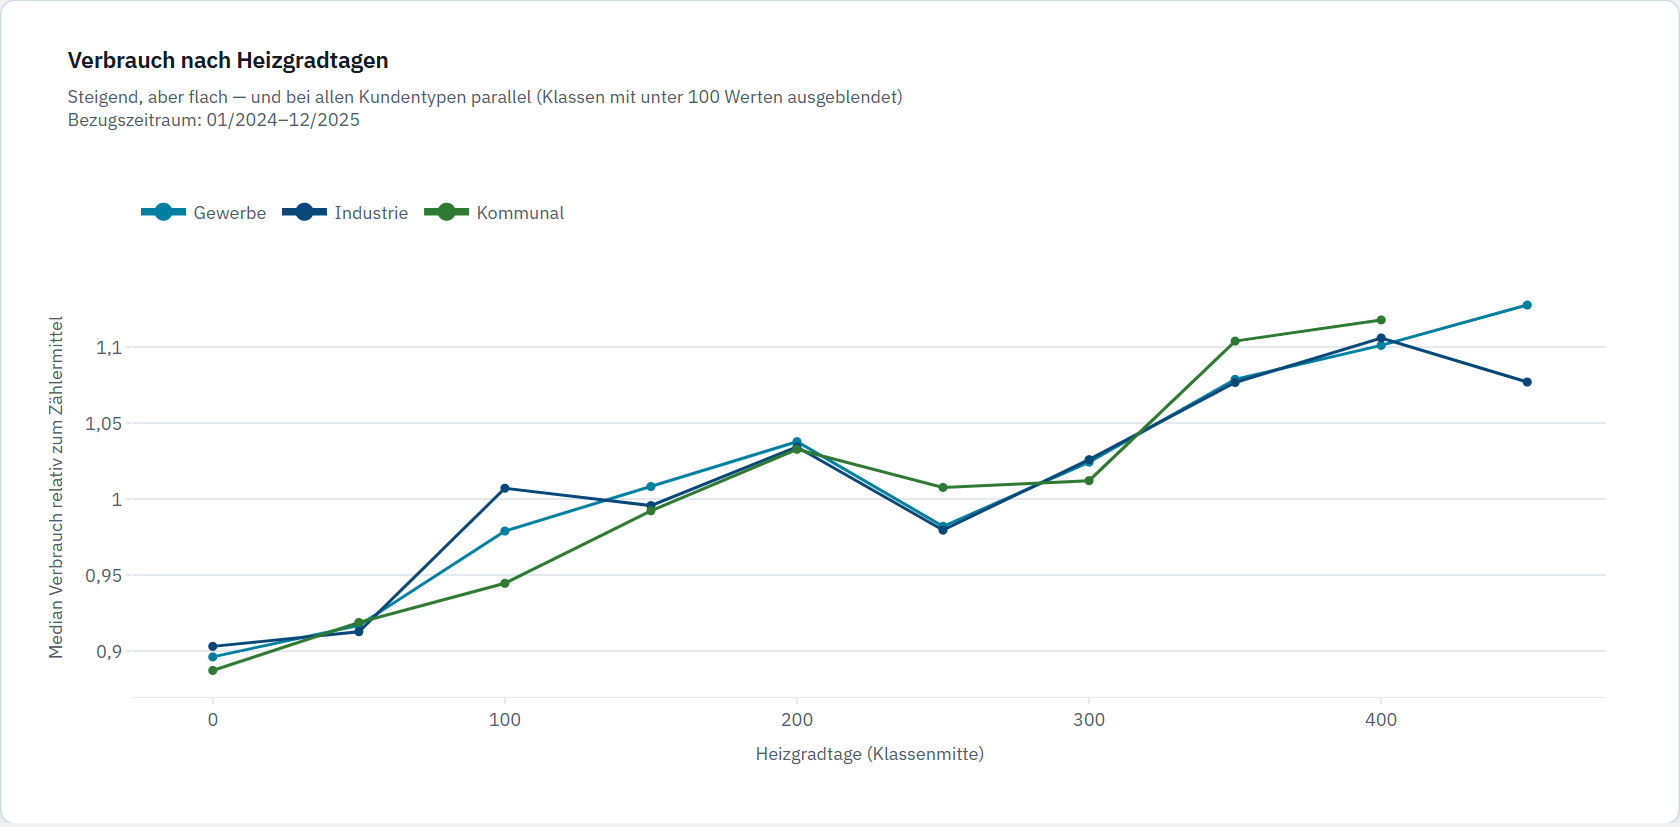

kundentyp
Gewerbe      0.37
Industrie    0.34
Kommunal     0.43
Name: Korrelation Heizgradtage, dtype: float64

In [32]:
# Heizgradtage in gleich breiten Klassen: zeigt die Form des Zusammenhangs
form = median_je_klasse("heizgradtage", np.arange(-25, 576, 50))

fig = px.line(form, x="klasse", y="rel_verbrauch", color="kundentyp", markers=True, **TYP_STIL)
ci.stil(fig, "Verbrauch nach Heizgradtagen",
         "Steigend, aber flach — und bei allen Kundentypen parallel "
         "(Klassen mit unter 100 Werten ausgeblendet)",
         x_titel="Heizgradtage (Klassenmitte)",
         y_titel="Median Verbrauch relativ zum Zählermittel")
ci.zeigen(fig)

# Wirkt die Heizung bei allen Kundentypen gleich stark?
(df.groupby("kundentyp", observed=True)
   .apply(lambda g: g[["rel_verbrauch", "heizgradtage"]].corr(method="spearman").iloc[0, 1],
          include_groups=False)
   .round(2).rename("Korrelation Heizgradtage"))

**Befund:** Der Produktionsplan-Index ist der klar stärkste Treiber. Der Zusammenhang
steigt **linear** von ~0,75 auf ~1,2 des Zählermittels, bei allen Kundentypen deckungsgleich.
Die Heizgradtage wirken in dieselbe Richtung, aber flacher und unregelmäßig
(~0,9 bis ~1,1). Die Kurven der Kundentypen verlaufen parallel (Korrelation 0,34 bis 0,43).
Eine Interaktion Kundentyp × Heizgradtage ist **nicht** erkennbar.

**Gegenprobe:** Der Produktionsplan ist selbst saisonal — im Winter wird mehr produziert
(Spearman −0,62 zu `monat_idx`, +0,43 zu `heizgradtage`). Steckt hinter dem Heizeffekt
also in Wahrheit der Produktionsplan? Dazu werden die Heizgradtage **innerhalb** gleicher
Produktionsplan-Bänder betrachtet.

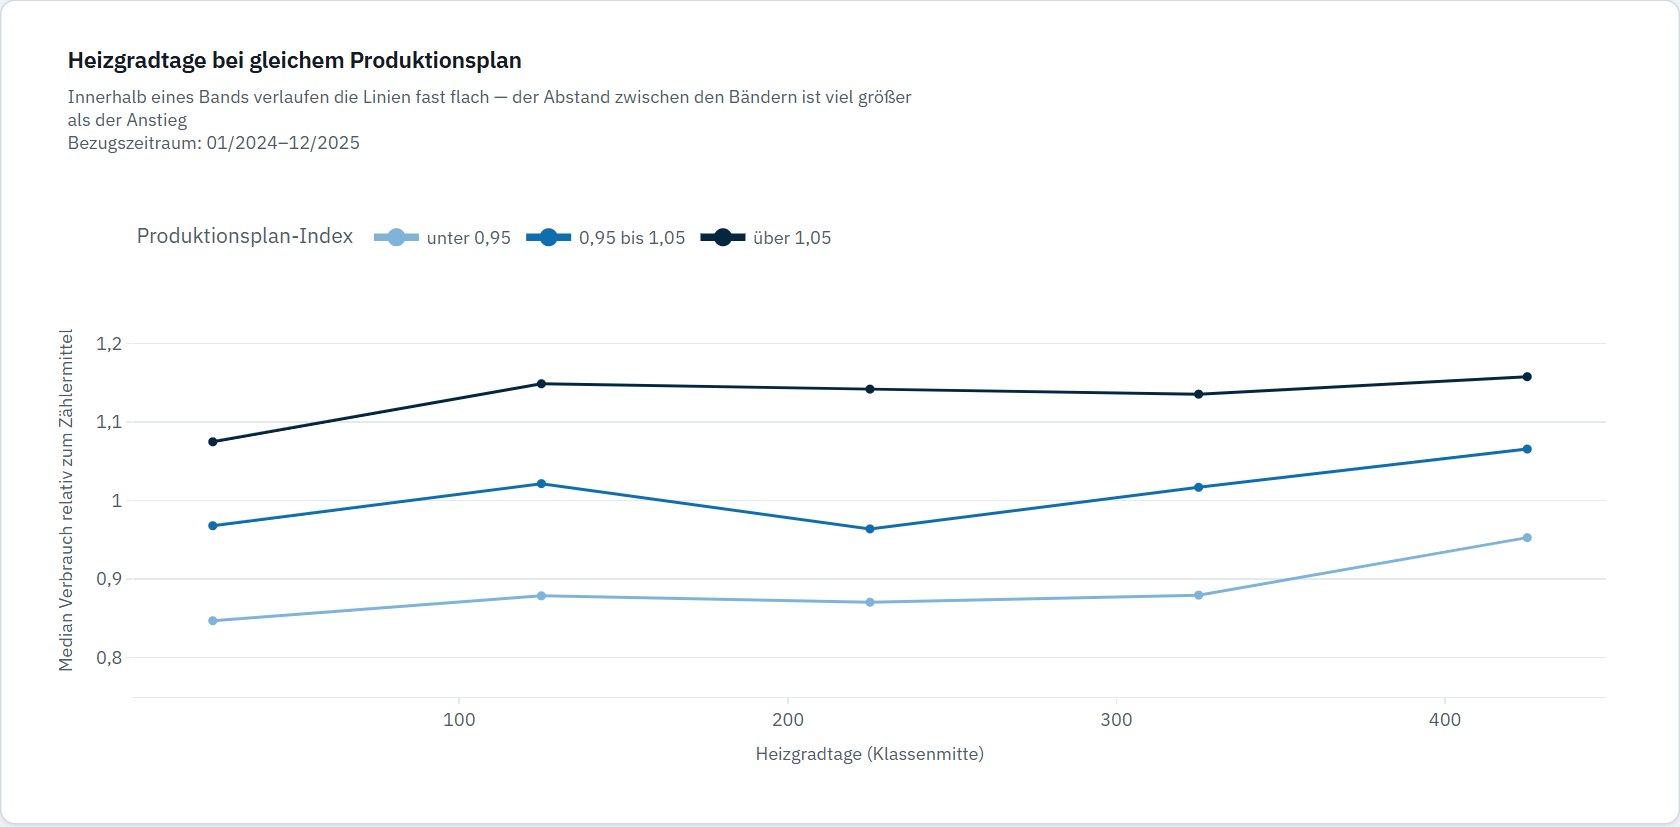

band,"unter 0,95","0,95 bis 1,05","über 1,05"
klasse,,,
25.000000,"0,847","0,968","1,075"
125.000000,"0,879","1,021","1,149"
225.000000,"0,871","0,964","1,142"
325.000000,"0,880","1,017","1,135"
425.000000,"0,953","1,065","1,158"


In [33]:
BAENDER = ["unter 0,95", "0,95 bis 1,05", "über 1,05"]
FARBE_BAND = dict(zip(BAENDER, [ci.SEQUENZIELL[2], ci.SEQUENZIELL[4], ci.SEQUENZIELL[-1]]))

kontrolle = df.dropna(subset=["produktionsplan_index"]).assign(
    band=lambda d: pd.cut(d["produktionsplan_index"], [0, 0.95, 1.05, 2], labels=BAENDER),
    klasse=lambda d: pd.cut(d["heizgradtage"], np.arange(-25, 576, 100)).map(lambda i: i.mid)
                          .astype(float))
je_band = (kontrolle.groupby(["band", "klasse"], observed=True)["rel_verbrauch"]
                    .agg(["median", "size"]).query("size >= 100").reset_index())

fig = px.line(je_band, x="klasse", y="median", color="band", markers=True,
              color_discrete_map=FARBE_BAND, category_orders={"band": BAENDER})
ci.stil(fig, "Heizgradtage bei gleichem Produktionsplan",
         "Innerhalb eines Bands verlaufen die Linien fast flach — der Abstand zwischen den "
         "Bändern ist viel größer als der Anstieg",
         x_titel="Heizgradtage (Klassenmitte)",
         y_titel="Median Verbrauch relativ zum Zählermittel")
fig.update_layout(legend_title_text="Produktionsplan-Index")
fig.update_yaxes(range=[0.75, 1.25])
ci.zeigen(fig)

ci.tabellenansicht(je_band.pivot(index="klasse", columns="band", values="median"), 3)

**Befund:** Hält man den Produktionsplan fest, bleibt vom Heizeffekt wenig übrig.
Innerhalb eines Bands steigt der Verbrauch über die ganze Heizgradtag-Spanne nur um
etwa 8 bis 12 %. Zwischen dem niedrigen und dem hohen Band liegen dagegen 20 bis 30 %.
Ein großer Teil des scheinbaren Heizeffekts ist also **saisonale Produktion**. Das passt
zu Gewerbe- und Industriekunden, die überwiegend nicht elektrisch heizen.

**Konsequenz:** `produktionsplan_index` ist das zentrale Feature. `heizgradtage` bleibt
drin, sein Einzeleffekt darf aber nicht überinterpretiert werden. Ein lineares Modell
mit beiden Größen ist eine gute, interpretierbare Referenz. Weil die saisonalen Treiber
miteinander verwoben sind, bleibt ein Baummodell erste Wahl.

### 5.4 Wartung: Wie stark sinkt der Verbrauch?

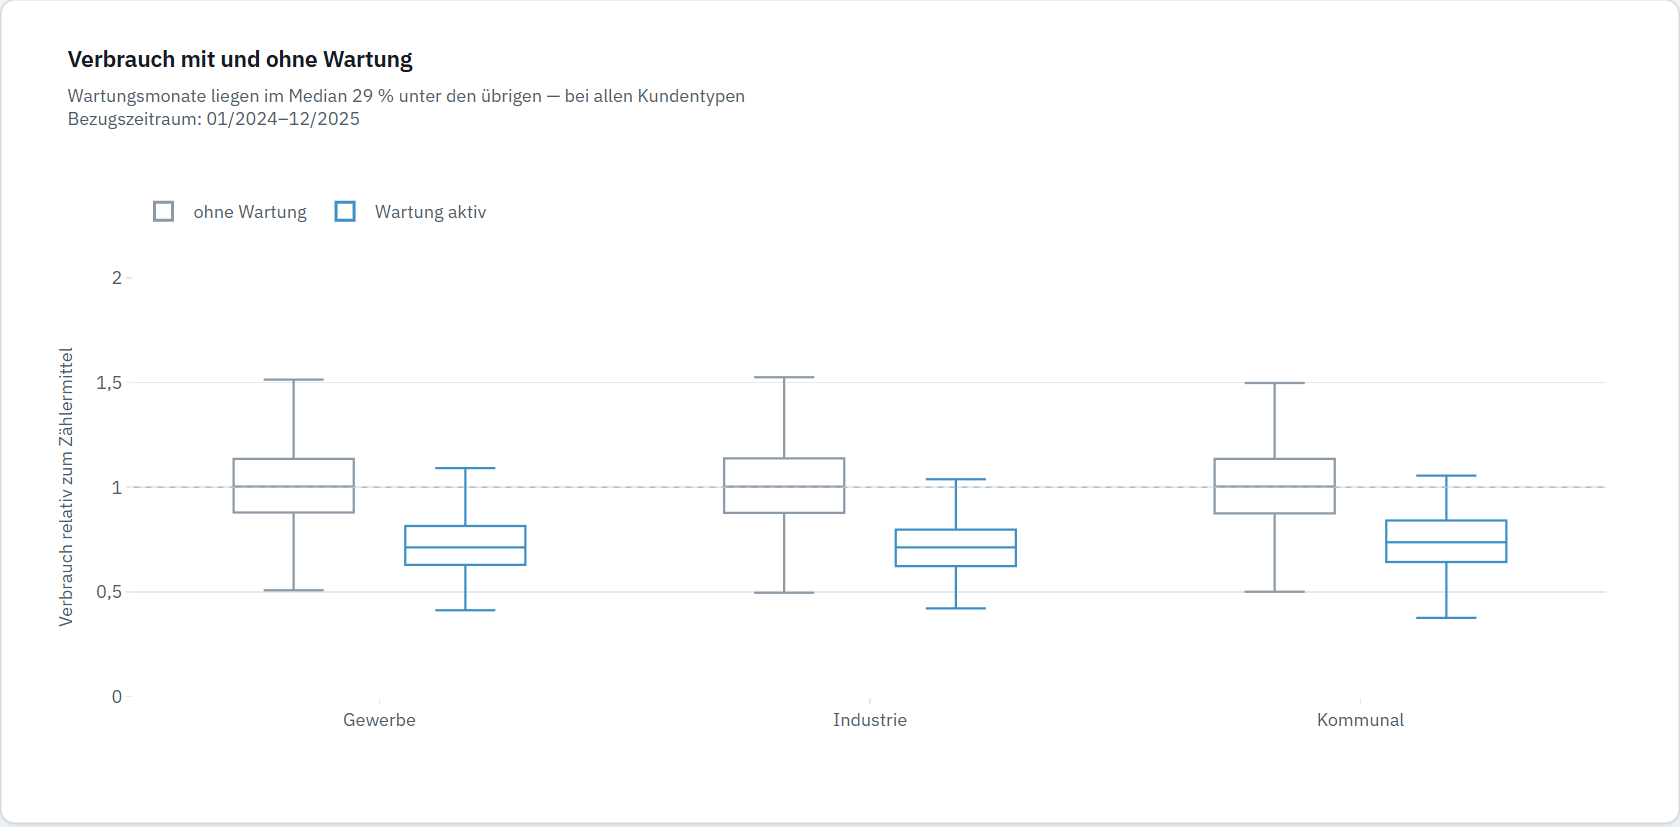

wartung,Wartung aktiv,ohne Wartung
kundentyp,,
Gewerbe,0.712,1.003
Industrie,0.712,1.003
Kommunal,0.737,1.004


In [34]:
wart = df.assign(wartung=df["wartung_aktiv"].map({False: "ohne Wartung", True: "Wartung aktiv"}))

fig = px.box(wart, x="kundentyp", y="rel_verbrauch", color="wartung", points=False,
             category_orders={"kundentyp": TYPEN, "wartung": ["ohne Wartung", "Wartung aktiv"]},
             color_discrete_map={"ohne Wartung": NEUTRAL, "Wartung aktiv": ci.SERIE[3]})
eff = wart.groupby("wartung")["rel_verbrauch"].median()
ci.stil(fig, "Verbrauch mit und ohne Wartung",
         f"Wartungsmonate liegen im Median {de((1 - eff['Wartung aktiv'] / eff['ohne Wartung']) * 100, 0)} % "
         "unter den übrigen — bei allen Kundentypen",
         x_titel="", y_titel="Verbrauch relativ zum Zählermittel")
ci.referenzlinie(fig, 1)
fig.update_yaxes(range=[0, 2])
iqr_whisker(fig)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

(wart.groupby(["kundentyp", "wartung"], observed=True)["rel_verbrauch"].median()
     .unstack().round(3))

**Befund:** In Wartungsmonaten liegt der Verbrauch im Median **29 % unter** dem Niveau
der übrigen Monate. Der Effekt ist bei allen drei Kundentypen gleich groß (Gewerbe und
Industrie −29 %, Kommunal −27 %), und die Boxen überlappen kaum.

**Konsequenz:** `wartung_aktiv` ist nach dem Produktionsplan der wichtigste Einzeltreiber
und kommt als binäres Feature ins Modell. Da der Wartungsmonat vorab geplant ist,
steht er zum Prognosezeitpunkt zur Verfügung.

### 5.5 Kalender: Arbeitstage und Feiertage

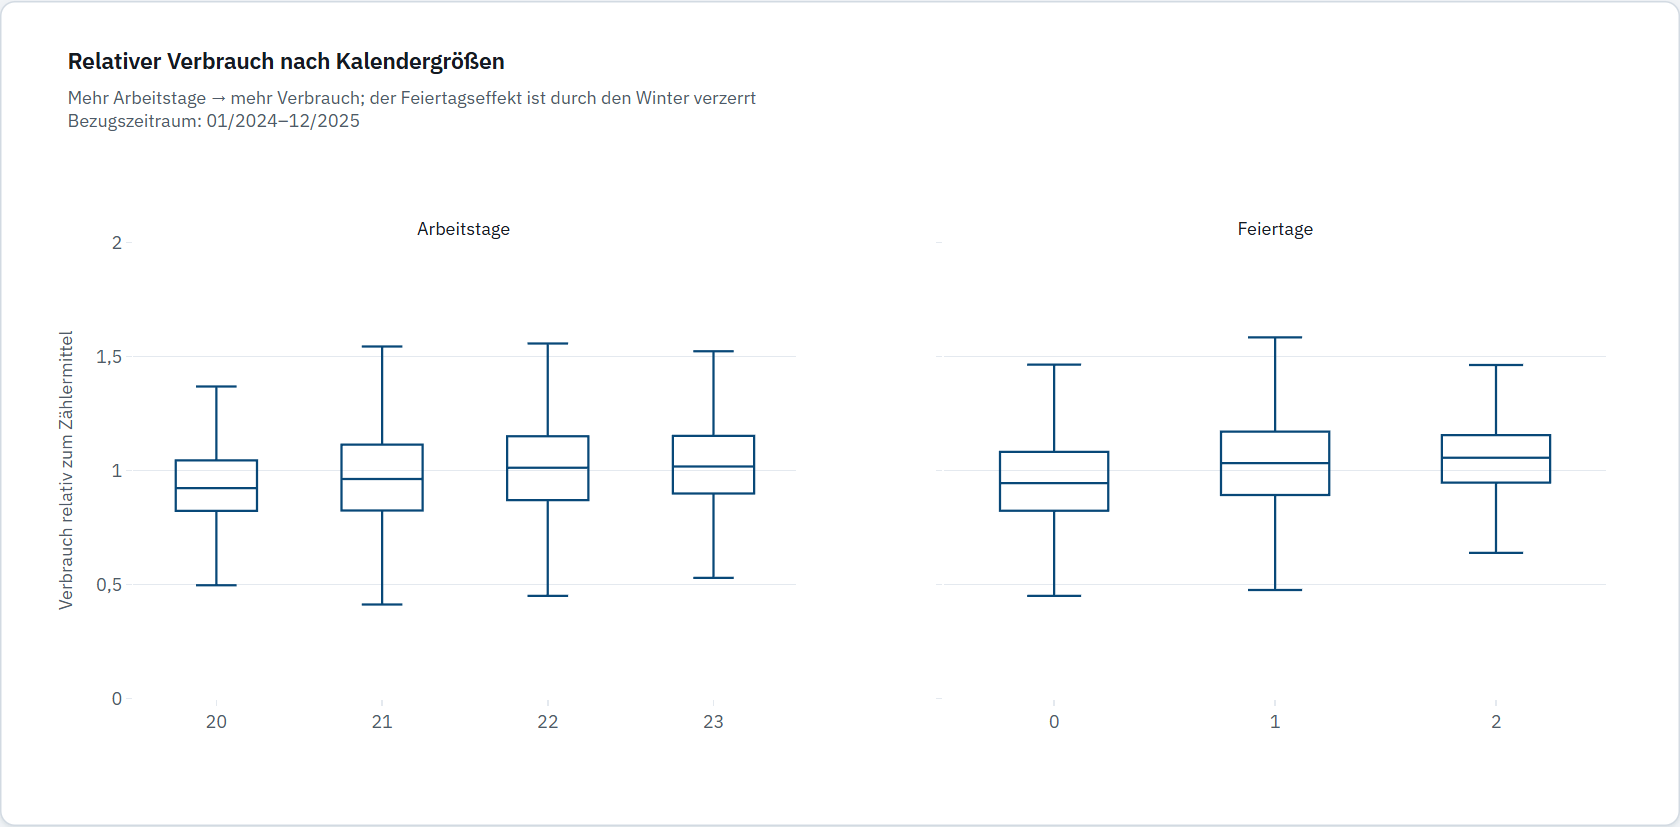

feiertage_im_monat
0    [2, 3, 6, 7, 8, 9]
1     [1, 4, 5, 10, 11]
2                  [12]
Name: Kalendermonate, dtype: object

In [35]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.1, shared_yaxes=True,
                    subplot_titles=("Arbeitstage", "Feiertage"))
for spalte, nr in [("arbeitstage", 1), ("feiertage_im_monat", 2)]:
    fig.add_box(x=df[spalte].astype(str), y=df["rel_verbrauch"], row=1, col=nr,
                marker_color=ci.SERIE[0], boxpoints=False, showlegend=False)
ci.stil(fig, "Relativer Verbrauch nach Kalendergrößen",
         "Mehr Arbeitstage → mehr Verbrauch; der Feiertagseffekt ist durch den Winter verzerrt")
fig.update_yaxes(title_text="Verbrauch relativ zum Zählermittel", range=[0, 2], row=1, col=1)
fig.update_xaxes(categoryorder="category ascending")
iqr_whisker(fig)
ci.hover_pro_marke(fig)
ci.zeigen(fig)

# Feiertage haeufen sich im Winter - der Vergleich ist mit der Saison vermischt
(df.drop_duplicates("monat").groupby("feiertage_im_monat")["monat_idx"]
   .agg(lambda s: sorted(set(s))).rename("Kalendermonate"))

**Befund:** Mit der Zahl der Arbeitstage steigt der Verbrauch leicht (Median ~0,92 bei 20,
~1,02 bei 23 Arbeitstagen). Der positive Feiertagseffekt ist dagegen ein Scheineffekt:
Vier der sechs Feiertagsmonate (Januar, April, Mai, Dezember) sind ohnehin
verbrauchsstark. Die Feiertage fallen also mit hohem Produktionsplan zusammen.
Für sich genommen sollten Feiertage den Verbrauch eher senken.

**Konsequenz:** `arbeitstage` als Feature aufnehmen. `feiertage_im_monat` ist
weitgehend in den Arbeitstagen enthalten und kann mitlaufen. Seine Wirkung wird erst im
Modell sauber vom Saisoneffekt getrennt.

### 5.6 Wie stark trägt der Vormonat?

Taugt der Vormonat als Feature — und als zweite Baseline?

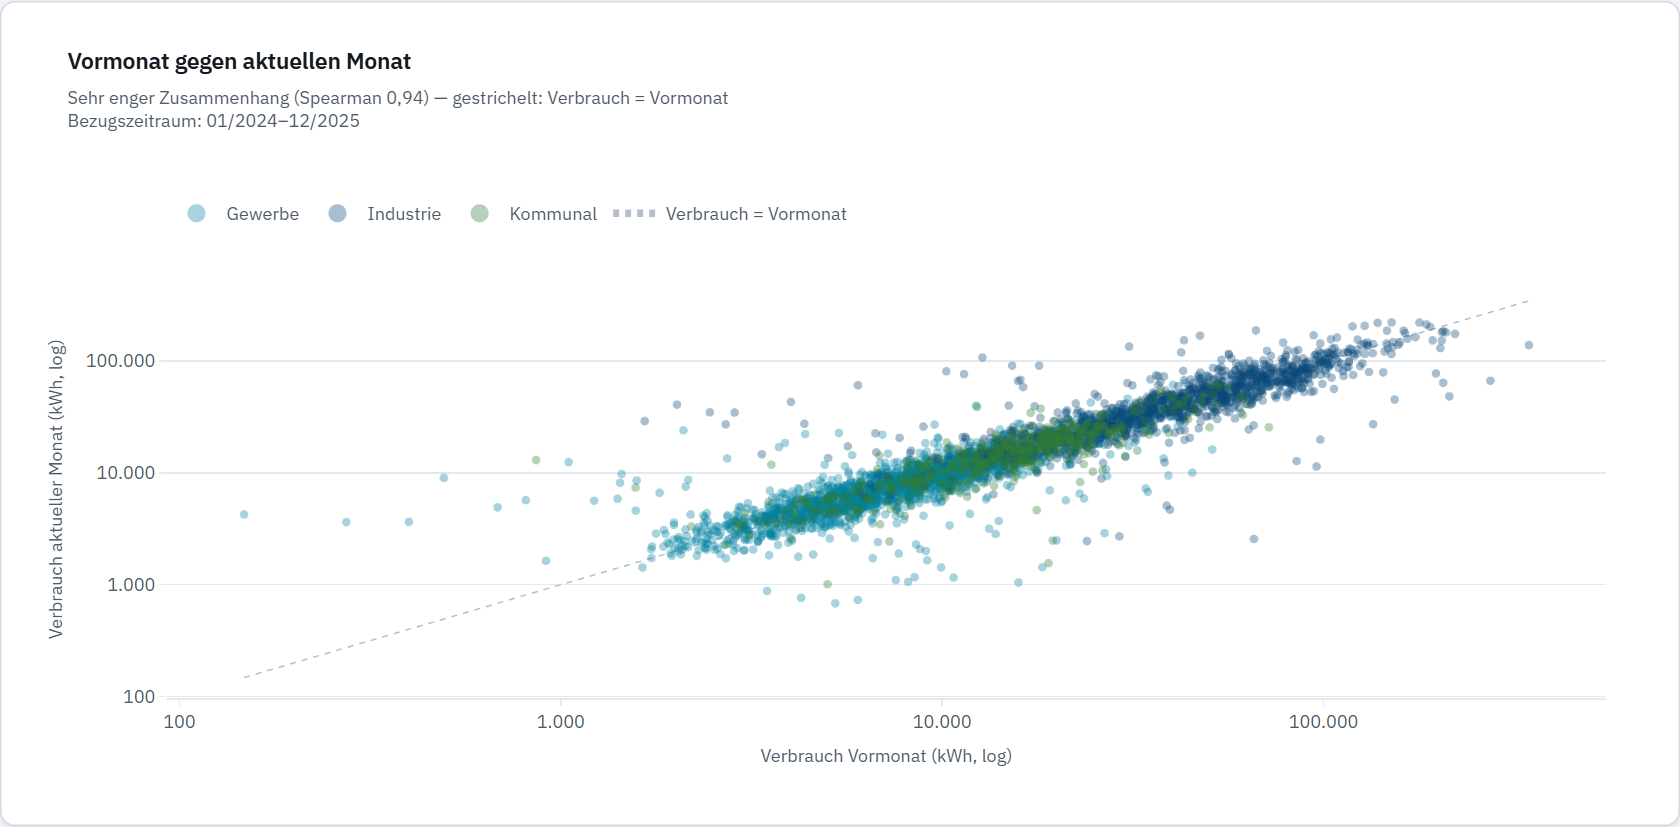

In [36]:
lag = stichprobe.dropna(subset=["vormonat_verbrauch_kwh"])
r_lag = df[["vormonat_verbrauch_kwh", "verbrauch_kwh"]].corr(method="spearman").iloc[0, 1]

fig = px.scatter(lag, x="vormonat_verbrauch_kwh", y="verbrauch_kwh", color="kundentyp",
                 log_x=True, log_y=True, opacity=0.35, hover_name="zaehler_id", **TYP_STIL)
ci.stil(fig, "Vormonat gegen aktuellen Monat",
         f"Sehr enger Zusammenhang (Spearman {de(r_lag, 2)}) — gestrichelt: Verbrauch = Vormonat",
         x_titel="Verbrauch Vormonat (kWh, log)", y_titel="Verbrauch aktueller Monat (kWh, log)")
ci.hover_pro_marke(fig)
fig.update_traces(marker=dict(size=6, line_width=0))
fig.update_xaxes(dtick=1)
fig.update_yaxes(dtick=1)

grenzen = [lag["vormonat_verbrauch_kwh"].min(), lag["vormonat_verbrauch_kwh"].max()]
fig.add_scatter(x=grenzen, y=grenzen, mode="lines", name="Verbrauch = Vormonat",
                line=ci.LINIE_REFERENZ, hoverinfo="skip")
ci.zeigen(fig)

**Befund:** Die Punkte liegen eng an der Diagonale (Spearman 0,94). Die Kundentypen
ordnen sich entlang der Diagonale nach Größe. Der Vormonatswert ist damit das stärkste
Einzelfeature und gleichzeitig eine naheliegende zweite Baseline
(„wie letzter Monat“).

**Konsequenz:** `vormonat_verbrauch_kwh` und `letzte_3_monate_durchschnitt_kwh` als Features
aufnehmen und bei normierter Zielgröße **mitnormieren**. Beide Baselines, Vormonat und
Vorjahresmonat, laufen im Modellvergleich mit.

## 6. Wo fehlen Werte — und sind die Lücken zufällig?

**Entscheidung:** Imputieren, belassen oder Spalte streichen?

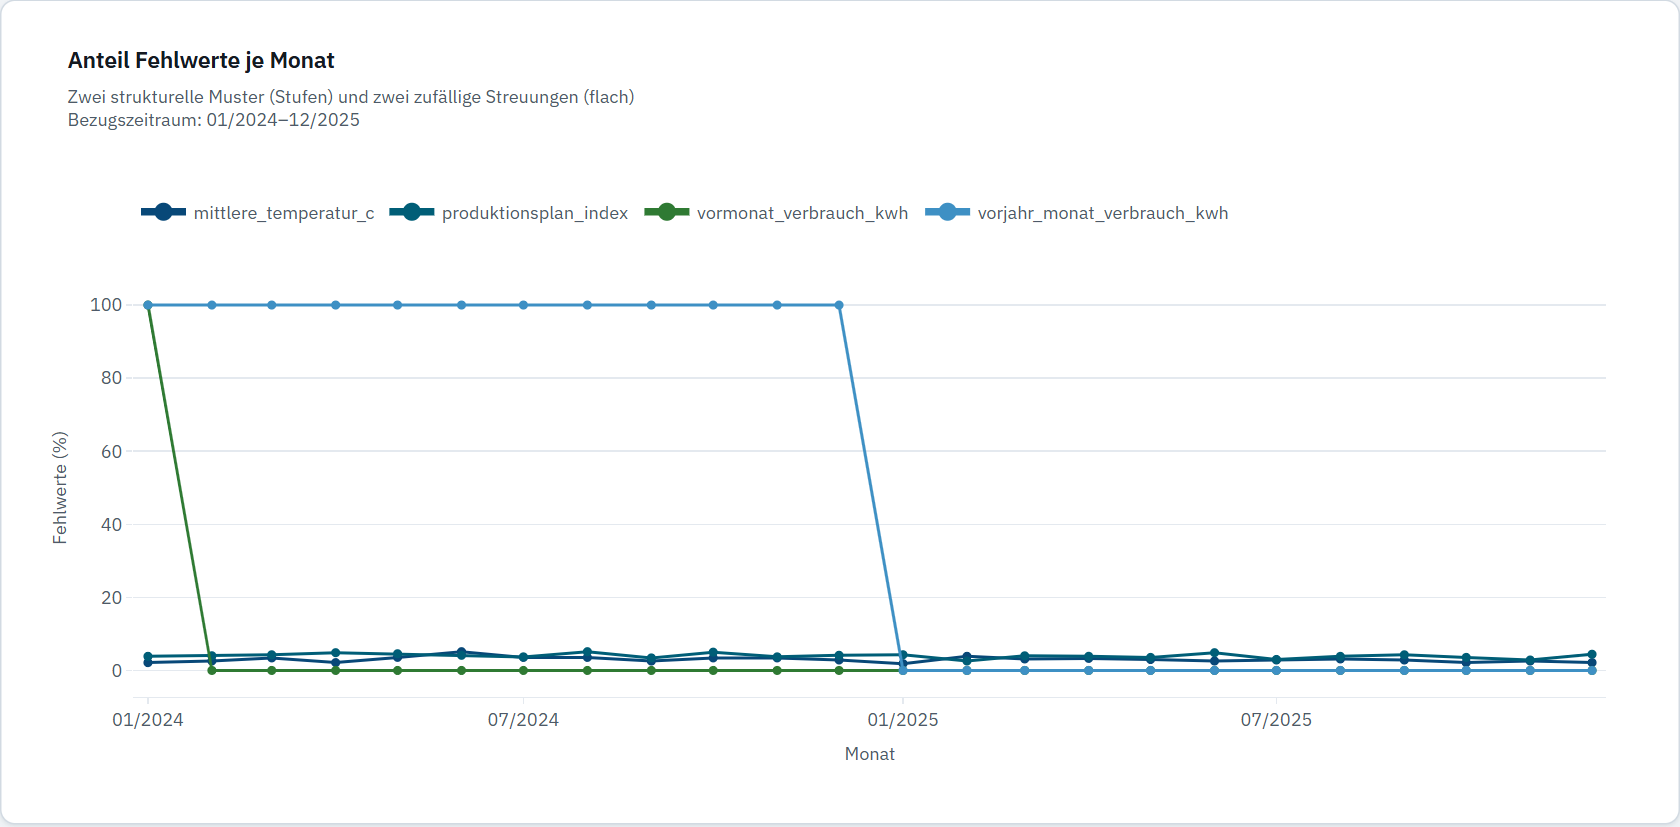

,mittlere temperatur c,produktionsplan index,vormonat verbrauch kwh,vorjahr monat verbrauch kwh
jahr,,,,
2024,3.2,4.2,8.3,100.0
2025,2.8,3.8,0.0,0.0


In [37]:
LUECKEN = ["mittlere_temperatur_c", "produktionsplan_index",
           "vormonat_verbrauch_kwh", "vorjahr_monat_verbrauch_kwh"]

fehlend = (df.set_index(df["monat"].dt.to_timestamp())[LUECKEN]
             .isna().resample("MS").mean().mul(100)
             .reset_index(names="monat")
             .melt(id_vars="monat", var_name="spalte", value_name="anteil"))

fig = px.line(fehlend, x="monat", y="anteil", color="spalte", markers=True, color_discrete_sequence=ci.SERIE)
ci.stil(fig, "Anteil Fehlwerte je Monat",
         "Zwei strukturelle Muster (Stufen) und zwei zufällige Streuungen (flach)",
         x_titel="Monat", y_titel="Fehlwerte (%)")
ci.zeigen(fig)

# Tabellenansicht: dieselben Zahlen ohne Hover, je Jahr zusammengefasst
(df.groupby("jahr")[LUECKEN].apply(lambda g: g.isna().mean() * 100).round(1)
   .rename(columns=lambda c: c.replace("_", " ")))

In [38]:
# Zufaellig heisst auch: der Verbrauch ist bei fehlendem Wert nicht anders
vergleich = pd.DataFrame({
    spalte: df.groupby(df[spalte].isna())["rel_verbrauch"].median()
    for spalte in ["mittlere_temperatur_c", "produktionsplan_index"]
}).rename(index={False: "Wert vorhanden", True: "Wert fehlt"}).round(3)
vergleich

,mittlere_temperatur_c,produktionsplan_index
Wert vorhanden,0.989,0.988
Wert fehlt,0.970,1.006


**Befund:** `vorjahr_monat_verbrauch_kwh` fehlt in ganz 2024 und danach nie. Die Lücke ist
rein strukturell. `vormonat_verbrauch_kwh` zeigt denselben Effekt im ersten Monat.
`mittlere_temperatur_c` und `produktionsplan_index` streuen dagegen gleichmäßig
über alle Monate (3 bis 4 %). Der Verbrauch ist in Zeilen mit Lücke nicht auffällig
anders (Tabelle), die Lücken sind also zufällig.

**Konsequenz:** Strukturelle Lücken belassen, nicht imputieren. `mittlere_temperatur_c`
entfällt ohnehin (5.2). Für `produktionsplan_index` reicht ein Baummodell, das NaN nativ
verarbeitet. Sonst hilft eine Median-Imputation, mit dem Kalendermonat als Gruppe,
weil der Index saisonal ist.

## Fazit: Vorgaben für die Modellierung

| Entscheidung | Ergebnis der EDA |
|---|---|
| **Datenqualität** | Sentinel-Rekonstruktion aus der Folgezeile und Entfernen der 20 Werte über 100 % Auslastung in dem Datenbereinigungs-Notebook nachziehen (Abschnitt 1) |
| **Zielgröße** | `vollaststunden = verbrauch_kwh / vertragsleistung_kw`: senkt die Streuung zwischen den Zählern von 92 % auf 56 %. Rücktransformation vor der Bewertung (3) |
| **Features gesetzt** | `produktionsplan_index` (stärkster Treiber), `wartung_aktiv` (−29 %), `heizgradtage`, `arbeitstage`, `vormonat_vls`, `letzte_3_monate_vls`, `kundentyp` |
| **Features optional** | `feiertage_im_monat` (Scheineffekt über die Saison, 5.5) |
| **Features gestrichen** | `mittlere_temperatur_c` (identisch zu `heizgradtage`, 503 Lücken), `vorjahr_monat_verbrauch_kwh` (in 2024 leer → Baseline statt Feature), `abweichung_vormonat_prozent`, `auslastung_prozent` (Leakage) |
| **Kundentyp** | ein gemeinsames Modell, Kundentyp als Feature — normiert verhalten sich die Typen fast gleich (4) |
| **`monat_idx`** | nicht linear verwenden: Die Saison ist keine Gerade und wird größtenteils vom Produktionsplan getragen |
| **Modellklasse** | Baummodell (verwobene saisonale Treiber, native NaN-Behandlung); lineares Modell als interpretierbare Referenz |
| **Fehlermaß** | MAE/MAPE in kWh; RMSE würde von wenigen Großzählern dominiert (2.1) |
| **Split** | Training 2024, Test 2025: Die Saisonkurven beider Jahre liegen deckungsgleich (4) |
| **Baselines** | Vorjahresmonat und Vormonat, bewertet in kWh auf denselben Testzeilen |